# M05 — Retrieval-Based Scar Generation

## Methodological background

**Case-Based Reasoning (CBR)** generates new examples by retrieving and adapting existing ones from a labelled case base. In the context of post-MI scar modelling, the idea is simple: given a target scar specification (e.g., "40% LAD territory, moderate total burden"), find the real patient(s) whose measured scar profile is most similar. The retrieved polar map then serves as the synthetic output.

This notebook implements CBR as a **retrieval-only baseline** — no generative model, no interpolation, no sampling from a latent space. Its role in the TFG is to:

1. Provide a non-parametric lower bound that purely learned models must beat.
2. Demonstrate that the feature space (Section 2) captures clinically meaningful scar geometry.
3. Validate that retrieved examples genuinely resemble their targets (Sections 5a–5c).

The distance metric follows Lawson et al. (2024): each feature is normalised by its population standard deviation so that high-variance features do not dominate the similarity score.

---
**Pipeline:** Load → Feature vectors → Retrieve → Validate → Figures

## 0 — Imports & configuration

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.special import softmax

warnings.filterwarnings('ignore', category=RuntimeWarning)


def _find_project_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for candidate in (base, base / 'lv-scar-segmentation'):
            if (candidate / 'src' / 'data_loading.py').exists():
                return candidate.resolve()
    raise FileNotFoundError(
        'Could not locate the lv-scar-segmentation project root.'
    )


ROOT = _find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ── Config ────────────────────────────────────────────────────────────────────
HD_ROOT         = r'F:/RM_TEKNON_DEVELOP'
N_R             = 64
N_THETA         = 128
AHA_DISPLAY_DEG = 0.0   # same as M04: RV insertion at West (9 o'clock)
SEED            = 42
RNG             = np.random.default_rng(seed=SEED)

RESULTS = ROOT / 'results'
OUT     = RESULTS / 'M05_retrieval_based_generation'
FIGURES = OUT / 'figures'
OUT.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

print(f'Project root : {ROOT}')
print(f'Output dir   : {OUT}')
print(f'Figures dir  : {FIGURES}')

Project root : C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation
Output dir   : C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\M05_retrieval_based_generation
Figures dir  : C:\Users\joan\Desktop\FEINA\UPF\TFG\repo\scar-char-v0.1\lv-scar-segmentation\results\M05_retrieval_based_generation\figures


## 1 - Data loading

Per-patient features are assembled by merging five M04 output CSVs on `key`:

| File | Contents |
|---|---|
| `aha17_territory_per_patient.csv` | AHA-17 segment CZ burdens + LAD/RCA/LCX territory fractions + global CZ extent |
| `circ_extent_per_ring.csv` | Circumferential CZ extent at each ring (Apex/Apical/Mid/Basal) |
| `scar_compactness.csv` | Polsby-Popper compactness of largest 2D CZ fragment |
| `fragment_population_characterization.csv` | Per-fragment depth metrics (onset, span, size) for f1..f4 |
| `apex_to_base_gradient_features.csv` | Spearman r between segment burden and apex-to-base position |

All files are generated by the current M04 notebook. No orphan artifacts used.

**Important scaling convention:** scar amounts are kept as percentages/fractions of the relevant anatomical support, never as raw vertex counts. This matters for fragments and segment presence because a fixed vertex-count threshold would penalise larger LVs. For example, `seg_04 = 0.20` means 20% of segment 4 is CZ, and `f1_size_frac = 0.65` means the largest fragment contains 65% of that patient's CZ bins.

Polar maps (64 - 128 binary arrays) are reconstructed from VTK meshes on the external HD. If HD unavailable, an approximate polar map is synthesised by painting each AHA segment region with its burden value.


In [2]:
# -- 1a  Load and merge per-patient M04 outputs -------------------------------
# All sources are M04-generated CSVs - no orphan artifacts.
M04_OUT = RESULTS / 'M04_scar_analysis'

# Primary: AHA-17 segment burdens + territory fractions + global CZ extent
_aha = pd.read_csv(M04_OUT / 'aha17_territory_per_patient.csv')

# Circumferential extent per ring
_circ = pd.read_csv(M04_OUT / 'circ_extent_per_ring.csv')[
    ['key', 'circ_extent_apex', 'circ_extent_apical',
     'circ_extent_mid', 'circ_extent_basal']]

# Shape compactness of largest fragment
_compact = pd.read_csv(M04_OUT / 'scar_compactness.csv')[
    ['key', 'compact_largest']]

# Fragment population: n_fragments, depth metrics, f1..f4 span+size.
# Threshold-sensitive fragment size is represented as a patient-relative fraction,
# not as a raw number of vertices, so large LVs are not systematically penalised.
_frag = pd.read_csv(M04_OUT / 'fragment_population_characterization.csv')[
    ['key', 'n_fragments', 'mean_onset_pct', 'mean_span_pct',
     'f1_span_pct', 'f1_size_frac',
     'f2_span_pct', 'f2_size_frac',
     'f3_span_pct', 'f3_size_frac',
     'f4_span_pct', 'f4_size_frac']]

# Apex-to-base Spearman gradient
_apex = pd.read_csv(M04_OUT / 'apex_to_base_gradient_features.csv')[
    ['key', 'apex_to_base_spearman']]

# Merge all on key
df = _aha.copy()
for _src in [_circ, _compact, _frag, _apex]:
    df = df.merge(_src, on='key', how='left')
df = df.dropna(subset=['key']).reset_index(drop=True)

# CZ burden alias (preferred over 'total_scar')
df['cz_burden'] = df['total_scar']

FEATURE_DICTIONARY = pd.DataFrame([
    ('seg_01..seg_17', 'AHA segment burden', 'CZ vertices / segment vertices', 'local % of each segment'),
    ('cz_burden', 'global CZ burden', 'CZ vertices / LV vertices', 'patient-level %'),
    ('LAD/RCA/LCX', 'territory burden', 'CZ in coronary territory / territory support', 'territory-level %'),
    ('n_involved', 'territory count', 'number of coronary territories with CZ > 0', 'integer count'),
    ('circ_extent_*', 'ring circumferential extent', 'CZ-covered angular bins / ring bins', 'ring-level %'),
    ('compact_largest', 'largest-fragment compactness', 'Polsby-Popper compactness', 'shape index'),
    ('n_fragments', 'fragment count', 'connected CZ components in the 3D mesh', 'integer count'),
    ('mean_onset_pct', 'mean scar onset depth', 'radial start depth from endocardium', '% wall thickness'),
    ('mean_span_pct', 'mean scar radial span', 'outermost depth - onset', '% wall thickness'),
    ('f*_span_pct', 'fragment radial span', 'span for fragment rank 1..4', '% wall thickness'),
    ('f*_size_frac', 'fragment relative size', 'fragment CZ bins / total CZ bins in patient', 'patient-relative %'),
    ('apex_to_base_spearman', 'apex-base gradient', 'Spearman r of segment burden vs apex-base position', 'correlation'),
], columns=['feature', 'meaning', 'formula', 'scale'])

print(f'Loaded {len(df)} patients from M04 individual outputs')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
print('\nFeature dictionary:')
display(FEATURE_DICTIONARY)
print('\nNumeric summary of key loaded features:')
display(df[['cz_burden', 'LAD', 'RCA', 'LCX', 'n_fragments',
            'mean_onset_pct', 'mean_span_pct',
            'f1_span_pct', 'f1_size_frac',
            'apex_to_base_spearman']].describe().round(4))


Loaded 105 patients from M04 individual outputs
Columns (44): ['key', 'pid', 'sex', 'age', 'LAD', 'RCA', 'LCX', 'n_involved', 'total_scar', 'seg_01', 'seg_02', 'seg_03', 'seg_04', 'seg_05', 'seg_06', 'seg_07', 'seg_08', 'seg_09', 'seg_10', 'seg_11', 'seg_12', 'seg_13', 'seg_14', 'seg_15', 'seg_16', 'seg_17', 'circ_extent_apex', 'circ_extent_apical', 'circ_extent_mid', 'circ_extent_basal', 'compact_largest', 'n_fragments', 'mean_onset_pct', 'mean_span_pct', 'f1_span_pct', 'f1_size_frac', 'f2_span_pct', 'f2_size_frac', 'f3_span_pct', 'f3_size_frac', 'f4_span_pct', 'f4_size_frac', 'apex_to_base_spearman', 'cz_burden']

Feature dictionary:


,feature,meaning,formula,scale
0,seg_01..seg_17,AHA segment burden,CZ vertices / segment vertices,local % of each segment
1,cz_burden,global CZ burden,CZ vertices / LV vertices,patient-level %
2,LAD/RCA/LCX,territory burden,CZ in coronary territory / territory support,territory-level %
3,n_involved,territory count,number of coronary territories with CZ > 0,integer count
4,circ_extent_*,ring circumferential extent,CZ-covered angular bins / ring bins,ring-level %
5,compact_largest,largest-fragment compactness,Polsby-Popper compactness,shape index
6,n_fragments,fragment count,connected CZ components in the 3D mesh,integer count
7,mean_onset_pct,mean scar onset depth,radial start depth from endocardium,% wall thickness
8,mean_span_pct,mean scar radial span,outermost depth - onset,% wall thickness
9,f*_span_pct,fragment radial span,span for fragment rank 1..4,% wall thickness



Numeric summary of key loaded features:


,cz_burden,LAD,RCA,LCX,n_fragments,mean_onset_pct,mean_span_pct,f1_span_pct,f1_size_frac,apex_to_base_spearman
count,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000,105.0000
mean,0.0512,0.0510,0.0478,0.0552,5.5905,30.2930,18.1486,20.8325,0.4905,0.0880
std,0.0514,0.0820,0.0605,0.0722,5.2141,14.4496,7.3980,9.3071,0.2709,0.4250
min,0.0034,0.0000,0.0000,0.0000,1.0000,9.7967,3.6014,3.0679,0.0593,-0.8947
25%,0.0166,0.0031,0.0042,0.0005,2.0000,20.9723,12.9312,13.6096,0.2925,-0.2386
50%,0.0332,0.0124,0.0318,0.0237,4.0000,27.7762,17.0516,20.2995,0.4747,0.2161
75%,0.0648,0.0596,0.0651,0.0851,8.0000,35.8811,22.6346,27.0164,0.6719,0.4477
max,0.2281,0.3768,0.3448,0.3066,32.0000,85.3877,40.4380,42.2192,1.0000,0.7403


In [3]:
# ?? 1a-bis  Use the complete feature cohort ?????????????????????????????????
FULL_FEAT_KEYS = set(df['key'])

print(f'Full feature cohort: {len(FULL_FEAT_KEYS)} patients')
print('No train/test split is used; all available cases remain in the unified pool.')

Full feature cohort: 105 patients
No train/test split is used; all available cases remain in the unified pool.


In [4]:
# ── 1b  AHA grid helpers (identical to M04) ───────────────────────────────────
def _aha_segment_grid(n_r=N_R, n_theta=N_THETA):
    labels = np.zeros((n_r, n_theta), dtype=np.int64)
    rc = (np.arange(n_r) + 0.5) / n_r
    tc = (np.arange(n_theta) + 0.5) / n_theta * 360.0
    for ri, radius in enumerate(rc):
        for ti, theta_deg in enumerate(tc):
            if radius < 0.25:
                labels[ri, ti] = 17
            elif radius < 0.50:
                if   45  <= theta_deg < 135: labels[ri, ti] = 13
                elif 135 <= theta_deg < 225: labels[ri, ti] = 16
                elif 225 <= theta_deg < 315: labels[ri, ti] = 15
                else:                        labels[ri, ti] = 14
            elif radius < 0.75:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 8
                elif 60  <= theta_deg < 120: labels[ri, ti] = 7
                elif 120 <= theta_deg < 180: labels[ri, ti] = 12
                elif 180 <= theta_deg < 240: labels[ri, ti] = 11
                elif 240 <= theta_deg < 300: labels[ri, ti] = 10
                else:                        labels[ri, ti] = 9
            else:
                if   0   <= theta_deg < 60:  labels[ri, ti] = 2
                elif 60  <= theta_deg < 120: labels[ri, ti] = 1
                elif 120 <= theta_deg < 180: labels[ri, ti] = 6
                elif 180 <= theta_deg < 240: labels[ri, ti] = 5
                elif 240 <= theta_deg < 300: labels[ri, ti] = 4
                else:                        labels[ri, ti] = 3
    return labels


AHA_GRID = _aha_segment_grid()

SEGMENTS  = list(range(1, 18))
SEG_COLS  = [f'seg_{s:02d}' for s in SEGMENTS]
SEG_LABELS = {
    1: 'bas ant',     2: 'bas ant-sep',  3: 'bas inf-sep',
    4: 'bas inf',     5: 'bas inf-lat',  6: 'bas ant-lat',
    7: 'mid ant',     8: 'mid ant-sep',  9: 'mid inf-sep',
    10: 'mid inf',    11: 'mid inf-lat', 12: 'mid ant-lat',
    13: 'api ant',    14: 'api sep',     15: 'api inf',
    16: 'api lat',    17: 'apex',
}
TERRITORY = {
    'LAD': [1, 2, 7, 8, 13, 14, 17],
    'RCA': [3, 4, 9, 10, 15],
    'LCX': [5, 6, 11, 12, 16],
}

print(f'AHA grid shape: {AHA_GRID.shape}  unique labels: {np.unique(AHA_GRID)}')

AHA grid shape: (64, 128)  unique labels: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


In [5]:
# ── 1c  Bullseye display helpers (same convention as M04) ─────────────────────
_AHA_SEG_LABELS_M05 = (
    (1, 90, 0.875),  (2, 30, 0.875),  (3, 330, 0.875),
    (4, 270, 0.875), (5, 210, 0.875), (6, 150, 0.875),
    (7, 90, 0.625),  (8, 30, 0.625),  (9, 330, 0.625),
    (10, 270, 0.625),(11, 210, 0.625),(12, 150, 0.625),
    (13, 90, 0.375), (14, 0, 0.375),  (15, 270, 0.375),
    (16, 180, 0.375),(17, 0, 0.125),
)


def _mark_septal_point(ax, theta=np.deg2rad(60), radius=1.04):
    ax.scatter([theta], [radius], s=26, color='dodgerblue', edgecolor='white',
               linewidth=0.7, zorder=10, clip_on=False)


def _draw_bullseye_grid(ax):
    t = np.linspace(0, 2 * np.pi, 361)
    for r in (0.25, 0.50, 0.75, 1.0):
        ax.plot(t, np.full_like(t, r), color='#555', lw=0.6, alpha=0.6)
    for deg in (0, 60, 120, 180, 240, 300):
        ax.plot([np.deg2rad(deg)] * 2, [0.5, 1.0], color='#555', lw=0.6, alpha=0.6)
    ax.set_yticklabels([])
    ax.set_rticks([])
    ax.set_xticks([])
    _mark_septal_point(ax)


def draw_bullseye(data, ax, title=None, cmap='hot_r', vmax=None, label_segs=False):
    """Render (N_R × N_THETA) array as AHA bullseye on a polar axis."""
    arr = np.asarray(data, dtype=float)
    if vmax is None:
        vmax = max(float(np.nanmax(arr)), 1e-12)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    mesh = ax.pcolormesh(T, R, arr, cmap=cmap, vmin=0, vmax=vmax, shading='flat')
    _draw_bullseye_grid(ax)
    if label_segs:
        for seg, deg, r in _AHA_SEG_LABELS_M05:
            ax.text(np.deg2rad(deg % 360), r, str(seg), fontsize=6,
                    ha='center', va='center', color='black',
                    bbox=dict(boxstyle='circle,pad=0.12', facecolor='white',
                              edgecolor='none', alpha=0.7))
    if title:
        ax.set_title(title, fontsize=8, pad=4)
    return mesh


def approx_polar_from_segs(seg_values, aha_grid=None):
    """Fill each AHA region with its burden value → approximate (N_R, N_THETA) map."""
    if aha_grid is None:
        aha_grid = AHA_GRID
    seg_values = np.asarray(seg_values, dtype=float)
    out = np.zeros_like(aha_grid, dtype=float)
    for i, seg in enumerate(SEGMENTS):
        out[aha_grid == seg] = seg_values[i]
    return out


print('Display helpers ready.')

Display helpers ready.


In [6]:
# ── 1d  Load polar maps from external HD (or fall back to approximation) ──────
pmaps = {}  # key → (N_R, N_THETA) float array

try:
    from src.data_loading import scan
    from src.mesh_utils import best_shell, get_cz_mesh, best_rv_mesh
    from src.lv_geometry import (
        prepare_polar_geometry, project_points_to_polar, polar_mask,
    )

    def _build_polar_map(lv_shell, scar_mesh, rv_mesh=None):
        geom = prepare_polar_geometry(
            lv_shell,
            reference_points=None if rv_mesh is None else np.asarray(rv_mesh.points),
        )
        theta, s = project_points_to_polar(np.asarray(scar_mesh.points), geom)
        theta = (2.0 * np.pi - theta) % (2.0 * np.pi)
        return polar_mask(theta, s, N_R, N_THETA, roll_deg=AHA_DISPLAY_DEG)

    def _polar_map_for_case(case):
        shell = best_shell(case)
        cz    = get_cz_mesh(case)
        if shell is None or cz is None:
            return None
        rv = best_rv_mesh(case)
        return _build_polar_map(shell, cz, rv_mesh=rv)

    all_cases = scan(HD_ROOT)
    key_to_case = {f'{c.year}/{c.patient_id}': c for c in all_cases}

    for key in df['key']:
        if key in key_to_case:
            try:
                m = _polar_map_for_case(key_to_case[key])
                if m is not None:
                    pmaps[key] = m.astype(float)
            except Exception:
                pass

    print(f'Loaded {len(pmaps)}/{len(df)} real polar maps from HD.')

except Exception as _e:
    print(f'HD not available ({_e}).')

# Build approximate maps for any patient without a real map
_n_approx = 0
for _, row in df.iterrows():
    key = row['key']
    if key not in pmaps:
        seg_vals = row[SEG_COLS].fillna(0).to_numpy(dtype=float)
        pmaps[key] = approx_polar_from_segs(seg_vals)
        _n_approx += 1

HD_AVAILABLE = _n_approx < len(df)
print(f'  approx maps synthesised for {_n_approx} patients.')
print(f'Total polar maps available: {len(pmaps)}')

# ── Load full-cohort polar maps from HD ────────────────────────────────────────────
# All cohort polar maps are stored in pmaps; no separate split cohort is loaded.
print('All polar maps are in the full-cohort pmaps dictionary.')


Loaded 105/105 real polar maps from HD.
  approx maps synthesised for 0 patients.
Total polar maps available: 105
All polar maps are in the full-cohort pmaps dictionary.


## 2 — Feature vector construction

Four profile levels are supported, each a strict superset of the one above:

| Profile | Dims | Feature groups |
|---|---|---|
| `minimal` | 18 | AHA-17 segment CZ burdens + global CZ extent |
| `spatial` | 26 | + territory fractions (LAD/RCA/LCX) + n_involved + circumferential extent ×4 |
| `morphological` | 33 | + shape compactness + apex gradient + n_fragments + fragment-1 depth metrics |
| `fragment` | 39 | + fragment-2/3/4 span and size (NaN→0 for absent fragments) |

**Feature terminology:**
- *CZ burden* (Core Zone) — fraction of CZ-labelled vertices; replaces the older “total_scar” label.
- *Onset* — radial depth from endocardium where scar begins (0 = endo, 1 = epi).
- *Span* — radial thickness of the scar layer (outermost\_depth − onset).

Excluded (corrupted or redundant): `mean_trans_pct`/`f*_trans_pct` (90 % ceiling artefact), `frac_endo/mid/epi` (near-constant), categorical `dominant`, and integer-bin duplicates.

All features come from three M04 output tables joined on `key` (see cell 1a).

In [7]:
SEG_COLS = [f'seg_{s:02d}' for s in range(1, 18)]

# ── Profile column groups ──────────────────────────────────────────────
# Each profile is a strict superset of the one above it.

# no-segment versions: each profile minus the 17 AHA segment columns.
# Shows what non-segment features carry in each profile level.
NOSEG_MIN_COLS  = ['cz_burden']                                        # 1 feat
NOSEG_SPA_COLS  = ['cz_burden', 'LAD', 'RCA', 'LCX', 'n_involved',
                   'circ_extent_basal', 'circ_extent_mid',
                   'circ_extent_apical', 'circ_extent_apex']           # 9 feats
NOSEG_MOR_COLS  = NOSEG_SPA_COLS + [
    'compact_largest', 'apex_to_base_spearman', 'n_fragments',
    'mean_onset_pct', 'mean_span_pct', 'f1_span_pct', 'f1_size_frac'] # 16 feats
NOSEG_FRG_COLS  = NOSEG_MOR_COLS + [
    'f2_span_pct', 'f2_size_frac', 'f3_span_pct', 'f3_size_frac',
    'f4_span_pct', 'f4_size_frac']                                     # 22 feats
NOSEG_COLS = NOSEG_MIN_COLS  # keep alias for backward compat

# minimal: 17 AHA segment burdens + global CZ extent (18 features)
MINIMAL_COLS = SEG_COLS + ['cz_burden']

# spatial: + territory fractions + circumferential extent per ring + n_involved (26)
SPATIAL_ADD = [
    'LAD', 'RCA', 'LCX', 'n_involved',
    'circ_extent_basal', 'circ_extent_mid',
    'circ_extent_apical', 'circ_extent_apex',
]

# morphological: + shape + fragment-1 depth + apex gradient (33)
MORPH_ADD = [
    'compact_largest',        # Polsby-Popper shape compactness of largest fragment
    'apex_to_base_spearman',  # Spearman r: segment burden vs apex-to-base distance
    'n_fragments',            # number of connected CZ components (3D mesh)
    'mean_onset_pct',         # mean radial onset (% wall from endo), fragment-size weighted
    'mean_span_pct',          # mean radial span (outermost-onset, % wall), fragment-size weighted
    'f1_span_pct',            # largest fragment radial span (% wall)
    'f1_size_frac',           # largest fragment / total CZ bins (dominance ratio)
]

# fragment: + fragment-2/3/4 depth descriptors; NaN→0 for absent fragments (39)
FRAGMENT_ADD = [
    'f2_span_pct', 'f2_size_frac',
    'f3_span_pct', 'f3_size_frac',
    'f4_span_pct', 'f4_size_frac',
]

# Full feature set: all 39 features (segment burdens + territory + morphology + fragments)
FULL_COLS        = MINIMAL_COLS + SPATIAL_ADD + MORPH_ADD + FRAGMENT_ADD  # 39
FULL_NOSEG_COLS  = NOSEG_FRG_COLS                                          # 22 (no segments)

PROFILE_COLS = {
    # -- primary analysis vectors (2b) --
    'full':                 FULL_COLS,          # 39: all features
    'full_no_seg':          FULL_NOSEG_COLS,    # 22: same minus AHA-17 segments
    # -- retrieval profiles (used in sections 4-6) --
    'minimal':              MINIMAL_COLS,
    'spatial':              MINIMAL_COLS + SPATIAL_ADD,
    'morphological':        MINIMAL_COLS + SPATIAL_ADD + MORPH_ADD,
    'fragment':             MINIMAL_COLS + SPATIAL_ADD + MORPH_ADD + FRAGMENT_ADD,
    # -- no-seg variants (ablation) --
    'no_segments':          NOSEG_MIN_COLS,
    'no_seg_spatial':       NOSEG_SPA_COLS,
    'no_seg_morphological': NOSEG_MOR_COLS,
    'no_seg_fragment':      NOSEG_FRG_COLS,
}


def build_feature_vector(dataframe, profile='minimal'):
    """
    Build a numeric feature matrix from the merged characterisation DataFrame.

    Parameters
    ----------
    dataframe : pd.DataFrame
        Merged data from:
          - aha17_territory_per_patient.csv    (AHA-17 segs + territory fractions + global CZ)
          - fragment_population_characterization.csv  (n_fragments, depth metrics, f1..f4)
          - apex_to_base_gradient_features.csv  (apex_to_base_spearman)
    profile : {'minimal', 'spatial', 'morphological', 'fragment'}
        Feature set level (each level is a strict superset).

    Returns
    -------
    X : np.ndarray, shape (n_patients, n_features)
    feature_names : list[str]

    Feature origin & meaning
    ------------------------
    seg_01..17           AHA-17 segment CZ burden (CZ vertices / total segment vertices)
    cz_burden            Global CZ extent (CZ vertices / LV vertices). Alias of total_scar.
    LAD / RCA / LCX      CZ fraction within each coronary territory
    n_involved           Number of coronary territories with any CZ (integer 1-3)
    circ_extent_*        Fraction of circumference covered by CZ at each ring
    compact_largest      Polsby-Popper compactness of largest fragment (area²/perimeter²)
    apex_to_base_spearman  Spearman r between segment burden and apex-to-base position
    n_fragments          Number of connected CZ components in the 3D mesh
    mean_onset_pct       Mean radial depth where CZ starts (% wall, 0=endo), size-weighted
    mean_span_pct        Mean CZ radial span (outermost_depth - onset, % wall), size-weighted
    f1_span_pct          Largest fragment radial span (% wall)
    f1_size_frac         Largest fragment bins / total CZ bins (dominance ratio [0,1])
    f2/f3/f4_*           Same span and size for 2nd/3rd/4th fragments; NaN→0 if absent

    Excluded features and reasons
    ------------------------------
    frac_endo/frac_midwall/frac_epi  onset-zone layer fractions; near-constant (>96% endo)
    mean_trans_pct / f*_trans_pct    corrupted: old algorithm caps at 90%, no variance
    LAD_cz_bins/RCA_cz_bins/LCX_cz_bins  integer counts, redundant with territory fractions
    total_scar_bins                  redundant with cz_burden
    apex_to_base_slope               linear, less robust than Spearman r
    aspect_ratio_largest             correlated with compact_largest
    n_fragments_2d                   correlated with n_fragments (3D)
    dominant                         categorical string, not numeric
    bz_core_pct / core_g / core_pct  25% missing; border-zone concept, not CZ
    """
    if profile not in PROFILE_COLS:
        raise ValueError(
            f"Unknown profile '{profile}'. "
            f"Choose from: {list(PROFILE_COLS)}"
        )
    cols = PROFILE_COLS[profile]
    X = dataframe[cols].fillna(0).to_numpy(dtype=float)
    return X, cols


# Sanity check
for _p, _exp in [('full', 39), ('full_no_seg', 22), ('minimal', 18)]:
    _X, _names = build_feature_vector(df, profile=_p)
    _ok = '✓' if _X.shape[1] == _exp else f'EXPECTED {_exp}'
    print(f"  profile='{_p:14s}' → {_X.shape[1]:2d} features {_ok}, shape {_X.shape}")

  profile='full          ' → 39 features ✓, shape (105, 39)
  profile='full_no_seg   ' → 22 features ✓, shape (105, 22)
  profile='minimal       ' → 18 features ✓, shape (105, 18)


### 2b - Feature vector inspection & SVD analysis

Before retrieval, understand what the vectors contain and which features carry the most variance.

**SVD on the z-score normalised matrix** reveals:
- Which features dominate the variance (scree plot, per-feature std)
- Which features cluster together (loading heatmap of first *k* components)
- Whether the 18-dim minimal profile has redundant dimensions
- How much of the variance is really coming from the AHA segment burden block

This guides profile choice and distance metric selection.


In [8]:
# -- 2b-i  Feature vector breakdown: full and full_no_seg --------------------
X_full,     feat_names_full     = build_feature_vector(df, profile='full')
X_full_ns,  feat_names_full_ns  = build_feature_vector(df, profile='full_no_seg')
# Also build minimal for retrieval sections 4-6
X_noseg_min, feat_names_noseg_min = build_feature_vector(df, profile='no_segments')
X_noseg_spa, feat_names_noseg_spa = build_feature_vector(df, profile='no_seg_spatial')
X_noseg_mor, feat_names_noseg_mor = build_feature_vector(df, profile='no_seg_morphological')
X_noseg_frg, feat_names_noseg_frg = build_feature_vector(df, profile='no_seg_fragment')
X_min, feat_names_min = build_feature_vector(df, profile='minimal')
X_spa, feat_names_spa = build_feature_vector(df, profile='spatial')
X_mor, feat_names_mor = build_feature_vector(df, profile='morphological')
X_frg, feat_names_frg = build_feature_vector(df, profile='fragment')

# -- Feature group explanations ------------------------------------------------
FEATURE_GROUPS = {
    'AHA-17 segment burdens (seg_01..17)': {
        'cols': [f'seg_{s:02d}' for s in range(1, 18)],
        'desc': 'Fraction of each AHA segment covered by scar (CZ vertices / segment vertices). '
                'Encodes LOCATION: which segments are affected and how severely.',
    },
    'Global extent (cz_burden)': {
        'cols': ['cz_burden'],
        'desc': 'Total scar fraction over the whole LV (CZ vertices / LV vertices). '
                'Single number for overall scar amount.',
    },
    'Territory fractions (LAD/RCA/LCX)': {
        'cols': ['LAD', 'RCA', 'LCX', 'n_involved'],
        'desc': 'Fraction of each coronary territory covered by scar + number of involved territories. '
                'Encodes CORONARY ANATOMY pattern.',
    },
    'Circumferential extent per ring': {
        'cols': ['circ_extent_basal', 'circ_extent_mid', 'circ_extent_apical', 'circ_extent_apex'],
        'desc': 'Fraction of circumference covered by scar at each ring (basal/mid/apical/apex). '
                'Encodes HOW MUCH of each level is involved.',
    },
    'Shape & depth (morphology)': {
        'cols': ['compact_largest', 'apex_to_base_spearman', 'n_fragments',
                 'mean_onset_pct', 'mean_span_pct', 'f1_span_pct', 'f1_size_frac'],
        'desc': 'Shape compactness of largest fragment, apex-to-base gradient, number of disconnected '
                'components, radial depth (onset % wall) and span (thickness % wall). '
                'Encodes TRANSMURALITY and SHAPE.',
    },
    'Fragment depth f2/f3/f4': {
        'cols': ['f2_span_pct', 'f2_size_frac', 'f3_span_pct', 'f3_size_frac',
                 'f4_span_pct', 'f4_size_frac'],
        'desc': 'Same depth/size descriptors for 2nd, 3rd, 4th largest fragments. '
                'Zero if fewer fragments exist. Encodes MULTI-FOCUS SCAR complexity.',
    },
}

print('=' * 70)
print('FULL VECTOR (39 features) -- all feature groups')
print('=' * 70)
for grp_name, grp in FEATURE_GROUPS.items():
    print(f'[{grp_name}]')
    print(f'  {grp["desc"]}')
    sub = df[grp['cols']].fillna(0)
    print(f'  {"Feature":<28} {"Mean":>8}  {"Std":>8}  {"Min":>8}  {"Max":>8}')
    print(f'  {"-"*28}  {"-"*8}  {"-"*8}  {"-"*8}  {"-"*8}')
    for col in grp['cols']:
        c = sub[col].to_numpy()
        print(f'  {col:<28} {c.mean():8.4f}  {c.std():8.4f}  {c.min():8.4f}  {c.max():8.4f}')

print(f'{"=" * 70}')
print(f'full:        {X_full.shape[1]} features (with AHA-17 segments)')
print(f'full_no_seg: {X_full_ns.shape[1]} features (same minus seg_01..17)')

FULL VECTOR (39 features) -- all feature groups
[AHA-17 segment burdens (seg_01..17)]
  Fraction of each AHA segment covered by scar (CZ vertices / segment vertices). Encodes LOCATION: which segments are affected and how severely.
  Feature                          Mean       Std       Min       Max
  ----------------------------  --------  --------  --------  --------
  seg_01                         0.0234    0.0606    0.0000    0.3807
  seg_02                         0.0226    0.0498    0.0000    0.2738
  seg_03                         0.0141    0.0515    0.0000    0.4554
  seg_04                         0.0138    0.0347    0.0000    0.2670
  seg_05                         0.0317    0.0616    0.0000    0.3333
  seg_06                         0.0323    0.0670    0.0000    0.3750
  seg_07                         0.0416    0.1072    0.0000    0.7528
  seg_08                         0.0568    0.1231    0.0000    0.6577
  seg_09                         0.0598    0.1117    0.0000    0.541

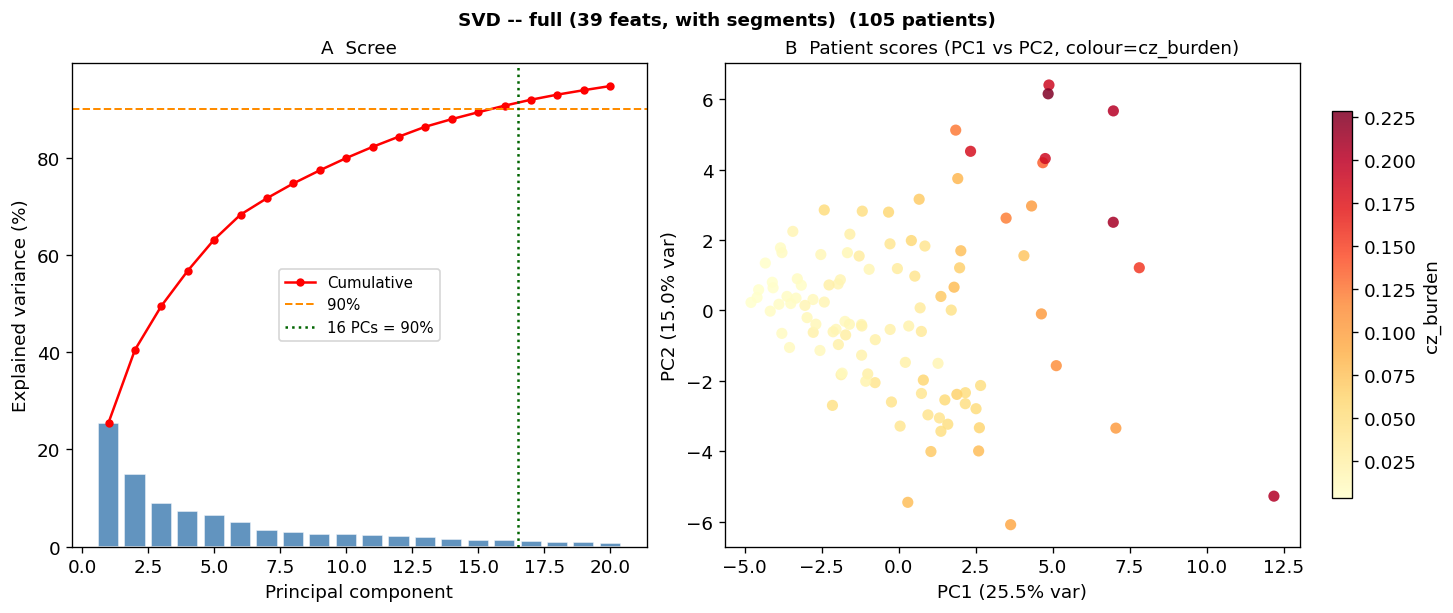

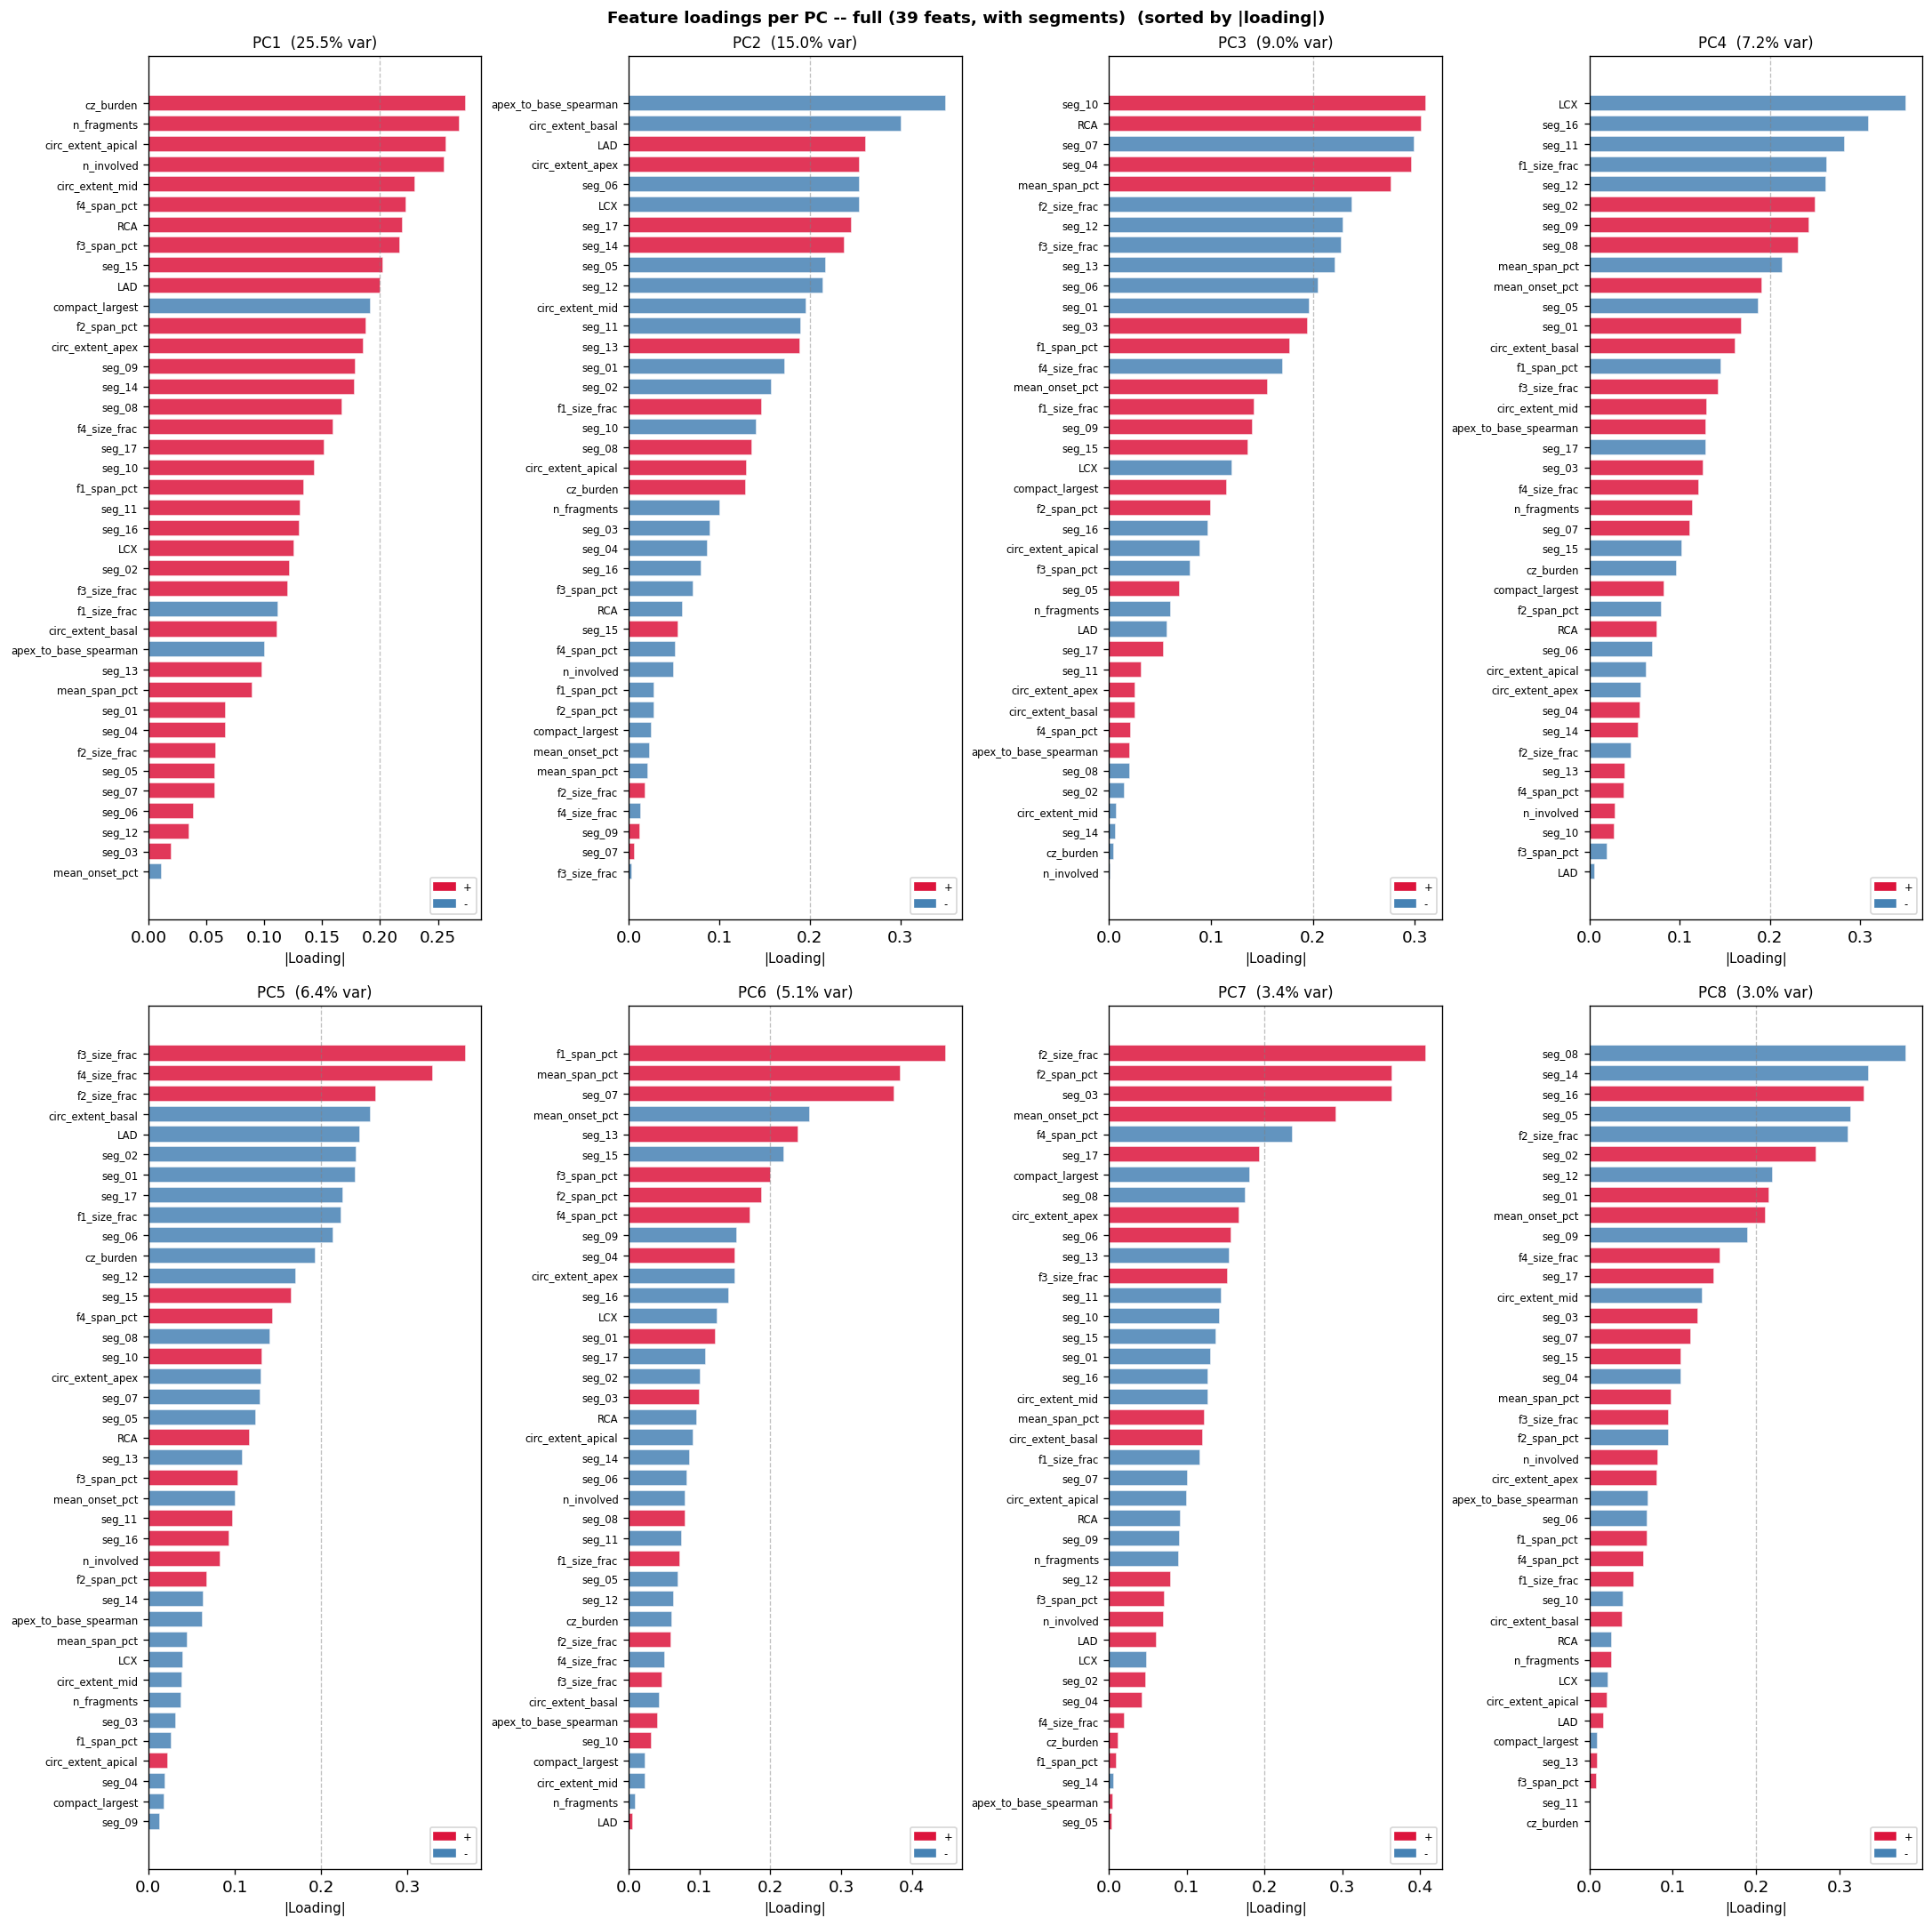

full (39 feats, with segments): 16 PCs = 90% var.  Saved svd_full_*.{pdf,png}


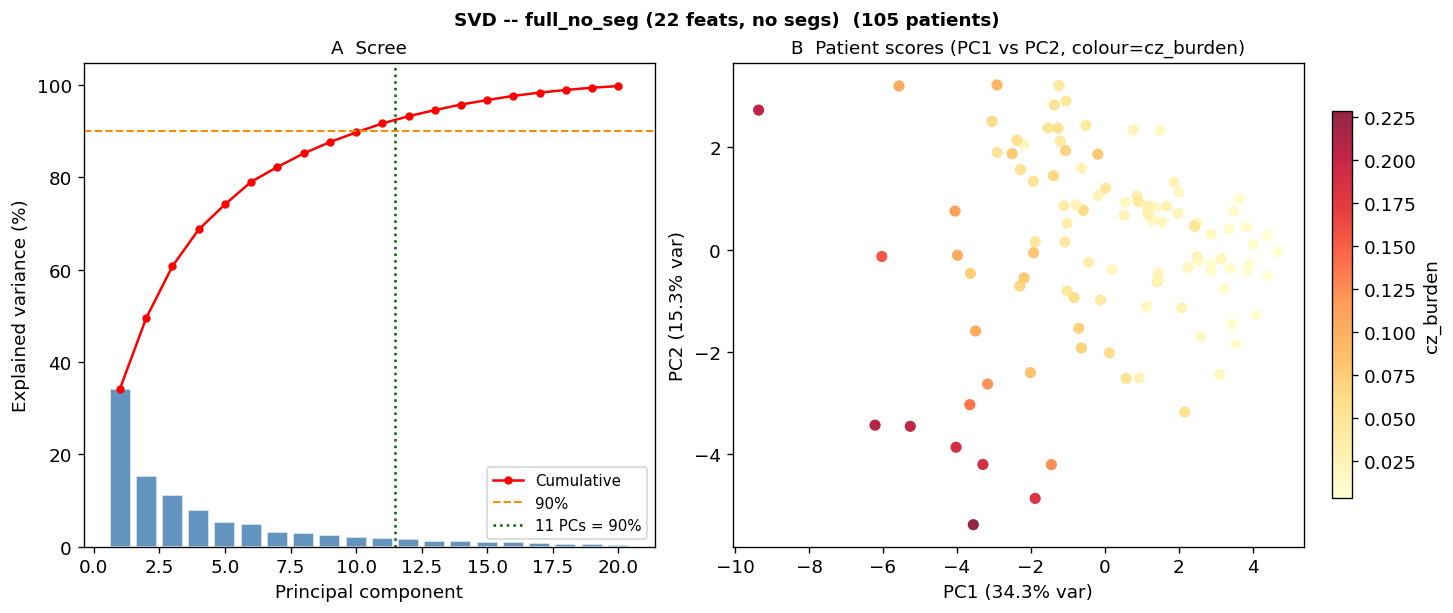

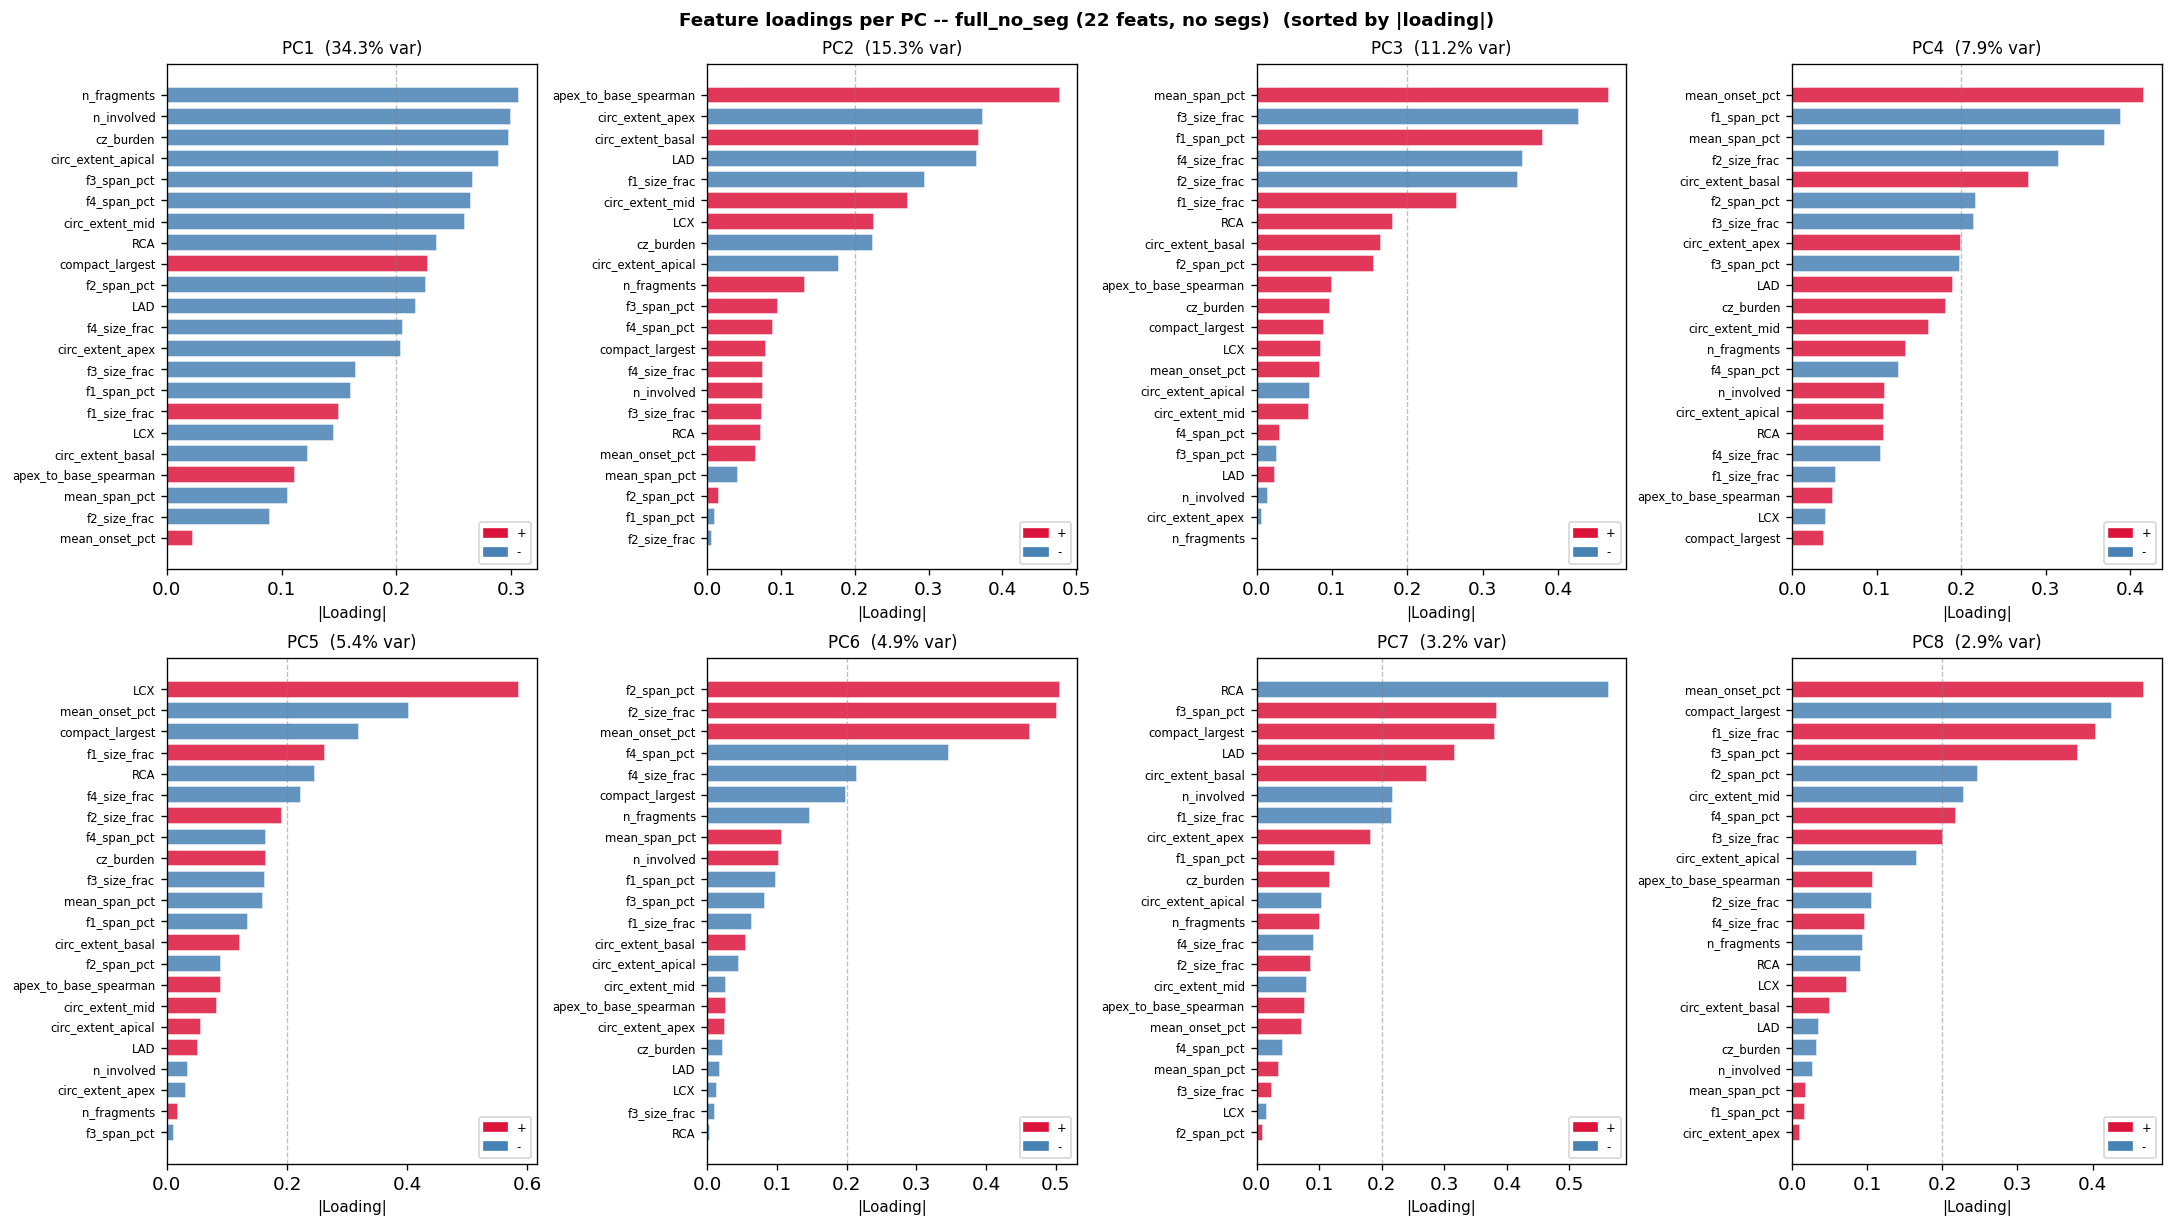

full_no_seg (22 feats, no segs): 11 PCs = 90% var.  Saved svd_full_noseg_*.{pdf,png}

Top features by contribution to PC1-8 (minimal subset -- used for 5c):


,feature,contrib_pc1_8
0,seg_08,0.301917
1,seg_07,0.288262
2,seg_16,0.283014
3,seg_12,0.257051
4,seg_02,0.247461
5,seg_01,0.238083
6,seg_17,0.226167
7,seg_03,0.223157
8,seg_14,0.215202
9,seg_05,0.209329


In [9]:
# -- 2b-iii  SVD analysis -- full and full_no_seg vectors --------------------
# For each vector: scree (variance per PC), loadings (feature contributions per PC),
# and PC1 vs PC2 patient scatter (scores: where each patient lives in PCA space).
_K_SHOW = 8

_svd_summary = None  # saved for 5c top-segment selection

def _compute_svd(X_prof):
    """Z-score, SVD, return (Vt, eigenvalue-fraction, PC-scores)."""
    _mu = np.nanmean(X_prof, axis=0)
    _sd = np.nanstd(X_prof, axis=0, ddof=0)
    _sd = np.where(_sd == 0, 1.0, _sd)
    X_z = np.nan_to_num((X_prof - _mu) / _sd)
    U, S, Vt = np.linalg.svd(X_z, full_matrices=False)
    ev = (S ** 2) / np.sum(S ** 2)
    scores = U * S   # (n_patients, n_components) -- PC scores
    return Vt, ev, scores

_VEC_PAIRS = [
    ('full (39 feats, with segments)',    X_full,    feat_names_full),
    ('full_no_seg (22 feats, no segs)',   X_full_ns, feat_names_full_ns),
]

_scar_vals = df['cz_burden'].to_numpy(dtype=float)

for vec_name, X_vec, feat_names in _VEC_PAIRS:
    n_feat = X_vec.shape[1]
    k = min(_K_SHOW, n_feat)
    Vt, ev, scores = _compute_svd(X_vec)
    cumev = np.cumsum(ev)
    n_components = len(ev)

    # Save minimal-equivalent contribution summary for 5c
    if 'no_seg' not in vec_name:
        _seg_idx = [i for i, f in enumerate(feat_names) if f.startswith('seg_')]
        _contrib_full = np.sum(Vt[:k, :] ** 2, axis=0)
        # Approximate minimal SVD summary using seg + cz_burden features only
        _min_idx = [feat_names.index(f) for f in feat_names_min if f in feat_names]
        if _min_idx:
            _svd_summary = pd.DataFrame({
                'feature': [feat_names[i] for i in _min_idx],
                f'contrib_pc1_{k}': _contrib_full[_min_idx],
            }).sort_values(f'contrib_pc1_{k}', ascending=False).reset_index(drop=True)

    # ── Figure: 3 panels per vector ──────────────────────────────────────────
    _n90 = int(np.searchsorted(cumev, 0.90)) + 1
    _fname = 'svd_full' if 'no_seg' not in vec_name else 'svd_full_noseg'

    # -- Figure 1: Scree + PC1 vs PC2 scatter --------------------------------
    fig_v, axes_v = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    fig_v.suptitle(f'SVD -- {vec_name}  ({len(df)} patients)', fontsize=11, fontweight='bold')

    _show_n = min(20, n_components)
    ax_sc = axes_v[0]
    ax_sc.bar(range(1, _show_n + 1), ev[:_show_n] * 100, color='steelblue', alpha=0.85, edgecolor='white')
    ax_sc.plot(range(1, _show_n + 1), cumev[:_show_n] * 100, 'r-o', ms=4, lw=1.5, label='Cumulative')
    ax_sc.axhline(90, color='darkorange', ls='--', lw=1.2, label='90%')
    ax_sc.axvline(_n90 + 0.5, color='darkgreen', ls=':', lw=1.5, label=f'{_n90} PCs = 90%')
    ax_sc.set_xlabel('Principal component', fontsize=11)
    ax_sc.set_ylabel('Explained variance (%)', fontsize=11)
    ax_sc.set_title(f'A  Scree', fontsize=11)
    ax_sc.legend(fontsize=9)

    _pc1 = scores[:, 0]
    _pc2 = scores[:, 1] if n_components > 1 else np.zeros(len(scores))
    sc2 = axes_v[1].scatter(_pc1, _pc2, c=_scar_vals, cmap='YlOrRd', s=45, alpha=0.85,
                            edgecolors='none', zorder=2)
    plt.colorbar(sc2, ax=axes_v[1], label='cz_burden', shrink=0.8)
    axes_v[1].set_xlabel(f'PC1 ({ev[0]:.1%} var)', fontsize=11)
    axes_v[1].set_ylabel(f'PC2 ({ev[1]:.1%} var)' if n_components > 1 else 'PC2', fontsize=11)
    axes_v[1].set_title('B  Patient scores (PC1 vs PC2, colour=cz_burden)', fontsize=11)

    fig_v.savefig(FIGURES / f'{_fname}_scree_scatter.pdf', bbox_inches='tight')
    fig_v.savefig(FIGURES / f'{_fname}_scree_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

    # -- Figure 2: Per-PC loading bar charts ----------------------------------
    # Each subplot = one PC.  Bars = |loading| of each feature, sorted descending.
    # Red = positive loading (feature increases along PC), blue = negative.
    # Dominant bar = feature that most strongly drives that PC direction.
    _ncols_pc = 4
    _nrows_pc = int(np.ceil(k / _ncols_pc))
    fig_load, axes_load = plt.subplots(
        _nrows_pc, _ncols_pc,
        figsize=(_ncols_pc * 4.5, _nrows_pc * max(4.5, n_feat * 0.23)),
        constrained_layout=True,
    )
    fig_load.suptitle(
        f'Feature loadings per PC -- {vec_name}  (sorted by |loading|)',
        fontsize=11, fontweight='bold',
    )
    _al_flat = axes_load.ravel() if hasattr(axes_load, 'ravel') else [axes_load]

    for pc_i in range(k):
        ax_l = _al_flat[pc_i]
        _load = Vt[pc_i, :]
        _ord_l = np.argsort(np.abs(_load))          # ascending so largest at top
        _cols_l = ['crimson' if _load[i] >= 0 else 'steelblue' for i in _ord_l]
        ax_l.barh(range(n_feat), np.abs(_load[_ord_l]), color=_cols_l, alpha=0.85, edgecolor='white')
        ax_l.set_yticks(range(n_feat))
        ax_l.set_yticklabels([feat_names[i] for i in _ord_l], fontsize=7)
        ax_l.set_xlabel('|Loading|', fontsize=9)
        ax_l.set_title(f'PC{pc_i+1}  ({ev[pc_i]:.1%} var)', fontsize=10)
        ax_l.axvline(0.2, color='grey', ls='--', lw=0.8, alpha=0.5)
        from matplotlib.patches import Patch as _Patch
        ax_l.legend(handles=[_Patch(color='crimson', label='+'), _Patch(color='steelblue', label='-')],
                    fontsize=7, loc='lower right')

    for _ax in _al_flat[k:]:
        _ax.set_visible(False)

    fig_load.savefig(FIGURES / f'{_fname}_pc_loadings.pdf', bbox_inches='tight')
    fig_load.savefig(FIGURES / f'{_fname}_pc_loadings.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'{vec_name}: {_n90} PCs = 90% var.  Saved {_fname}_*.{{pdf,png}}')

if _svd_summary is not None:
    print('\nTop features by contribution to PC1-8 (minimal subset -- used for 5c):')
    display(_svd_summary.head(10))


  full (39 feats, with segments)  --  top-k=8  (n_feat=39)
  Feature                         Contribution  Rank (low=weak)
  ------------------------------  ------------  ------------------
  compact_largest                       0.0915  # 1 <<< low
  n_involved                            0.0941  # 2 <<< low
  n_fragments                           0.1095  # 3 <<< low
  circ_extent_apical                    0.1150  # 4 <<< low
  f3_span_pct                           0.1156  # 5 <<< low
  seg_04                                0.1406  # 6
  cz_burden                             0.1425  # 7
  circ_extent_mid                       0.1455  # 8
  apex_to_base_spearman                 0.1608  # 9
  f4_span_pct                           0.1649  #10
  seg_11                                0.1710  #11
  LAD                                   0.1763  #12
  circ_extent_apex                      0.1783  #13
  seg_10                                0.1784  #14
  seg_09                                0

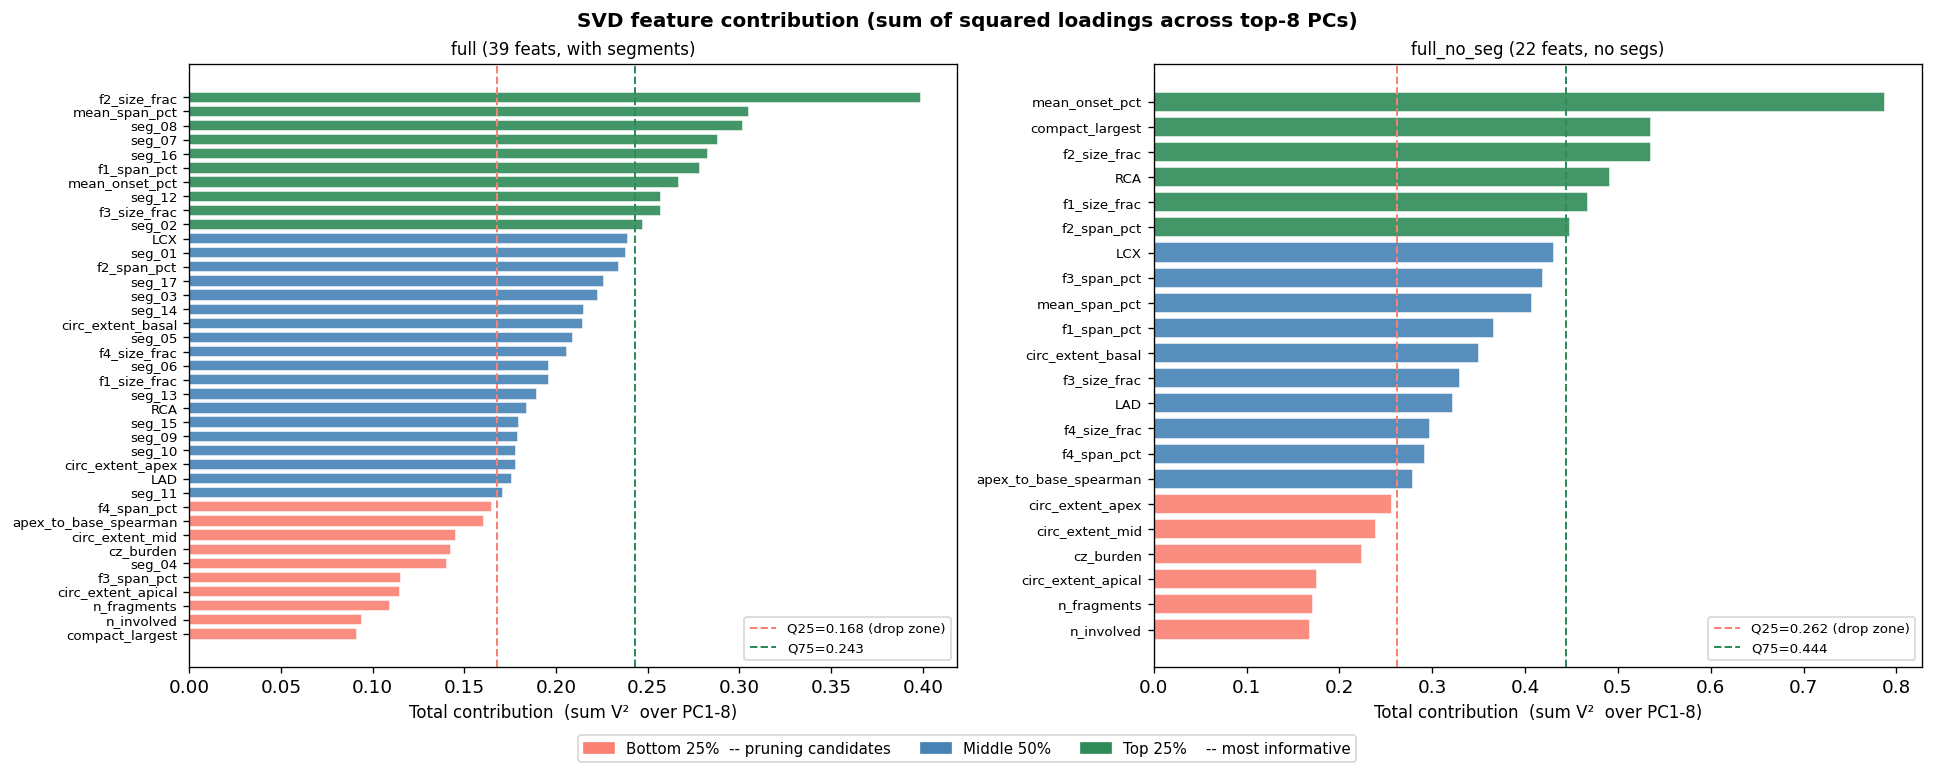

Saved svd_feature_contribution.{pdf,png}


In [10]:
# -- 2b-iv  SVD feature contribution ranking ---------------------------------
# Total contribution of each feature across the top-k PCs:
#   contrib_i = sum_{j=1}^{k} V_{ji}^2
# Features with lowest total contribution are redundant/uninformative
# in the compressed k-PC subspace and are pruning candidates.
#
# NOTE: low contribution != useless for retrieval in every case.
# Correlated features (e.g. many seg_XX) share variance -> each loads low
# but together they encode location.  Use this as a diagnostic, not a
# hard decision rule.

_K_CONTRIB = 8   # same k used in the loading bar charts above

_contrib_results = {}

for vec_name, X_vec, feat_names in _VEC_PAIRS:
    n_feat = X_vec.shape[1]
    k = min(_K_CONTRIB, n_feat)
    Vt, ev, _ = _compute_svd(X_vec)

    contrib = np.sum(Vt[:k, :] ** 2, axis=0)   # (n_feat,)
    ord_asc = np.argsort(contrib)               # lowest first

    _contrib_results[vec_name] = (feat_names, contrib, ord_asc, k)

    print(f"\n{'='*60}")
    print(f"  {vec_name}  --  top-k={k}  (n_feat={n_feat})")
    print(f"  {'Feature':<30}  {'Contribution':>12}  {'Rank (low=weak)'}")
    print(f"  {'-'*30}  {'-'*12}  {'-'*18}")
    for rank, i in enumerate(ord_asc):
        marker = " <<< low" if rank < 5 else ""
        print(f"  {feat_names[i]:<30}  {contrib[i]:12.4f}  #{rank+1:>2}{marker}")

# ── Figure: side-by-side contribution bar charts ─────────────────────────────
fig_c, axes_c = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig_c.suptitle(
    f"SVD feature contribution (sum of squared loadings across top-{_K_CONTRIB} PCs)",
    fontsize=12, fontweight="bold",
)

_COLORS_THRESH = {"low": "salmon", "mid": "steelblue", "high": "seagreen"}

for ax, (vec_name, (feat_names, contrib, ord_asc, k)) in zip(axes_c, _contrib_results.items()):
    n = len(feat_names)
    _q25 = np.percentile(contrib, 25)
    _q75 = np.percentile(contrib, 75)
    _bar_colors = [
        _COLORS_THRESH["low"]  if contrib[i] <= _q25 else
        _COLORS_THRESH["high"] if contrib[i] >= _q75 else
        _COLORS_THRESH["mid"]
        for i in ord_asc
    ]
    ax.barh(range(n), contrib[ord_asc], color=_bar_colors, edgecolor="white", alpha=0.9)
    ax.set_yticks(range(n))
    ax.set_yticklabels([feat_names[i] for i in ord_asc], fontsize=8)
    ax.set_xlabel(f"Total contribution  (sum V²  over PC1-{k})", fontsize=10)
    ax.set_title(vec_name, fontsize=10)
    ax.axvline(_q25, color="salmon",   ls="--", lw=1.2, label=f"Q25={_q25:.3f} (drop zone)")
    ax.axvline(_q75, color="seagreen", ls="--", lw=1.2, label=f"Q75={_q75:.3f}")
    ax.legend(fontsize=8)

from matplotlib.patches import Patch as _Patch
fig_c.legend(
    handles=[
        _Patch(color="salmon",    label="Bottom 25%  -- pruning candidates"),
        _Patch(color="steelblue", label="Middle 50%"),
        _Patch(color="seagreen",  label="Top 25%    -- most informative"),
    ],
    loc="lower center", ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.06),
)

_fname_c = "svd_feature_contribution"
fig_c.savefig(FIGURES / f"{_fname_c}.pdf", bbox_inches="tight")
fig_c.savefig(FIGURES / f"{_fname_c}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {_fname_c}.{{pdf,png}}")


full (39 feats, with segments)
  Q25 threshold = 0.1680
  Dropped 10 features: ['seg_04', 'cz_burden', 'n_involved', 'circ_extent_mid', 'circ_extent_apical', 'compact_largest', 'apex_to_base_spearman', 'n_fragments', 'f3_span_pct', 'f4_span_pct']
  Kept 29 / 39 features: ['seg_01', 'seg_02', 'seg_03', 'seg_05', 'seg_06', 'seg_07', 'seg_08', 'seg_09', 'seg_10', 'seg_11', 'seg_12', 'seg_13', 'seg_14', 'seg_15', 'seg_16', 'seg_17', 'LAD', 'RCA', 'LCX', 'circ_extent_basal', 'circ_extent_apex', 'mean_onset_pct', 'mean_span_pct', 'f1_span_pct', 'f1_size_frac', 'f2_span_pct', 'f2_size_frac', 'f3_size_frac', 'f4_size_frac']
full_no_seg (22 feats, no segs)
  Q25 threshold = 0.2623
  Dropped 6 features: ['cz_burden', 'n_involved', 'circ_extent_mid', 'circ_extent_apical', 'circ_extent_apex', 'n_fragments']
  Kept 16 / 22 features: ['LAD', 'RCA', 'LCX', 'circ_extent_basal', 'compact_largest', 'apex_to_base_spearman', 'mean_onset_pct', 'mean_span_pct', 'f1_span_pct', 'f1_size_frac', 'f2_span_pct', 

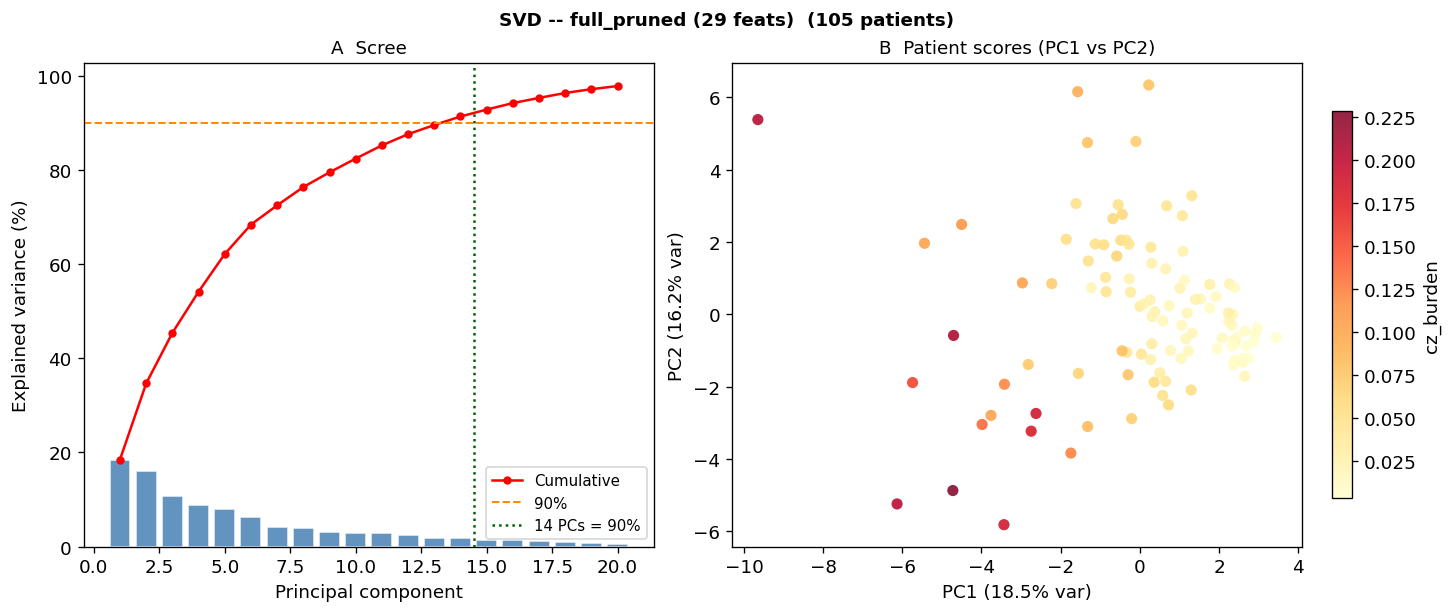

full_pruned (29 feats): 14 PCs = 90% var.  Saved svd_full_pruned.{pdf,png}


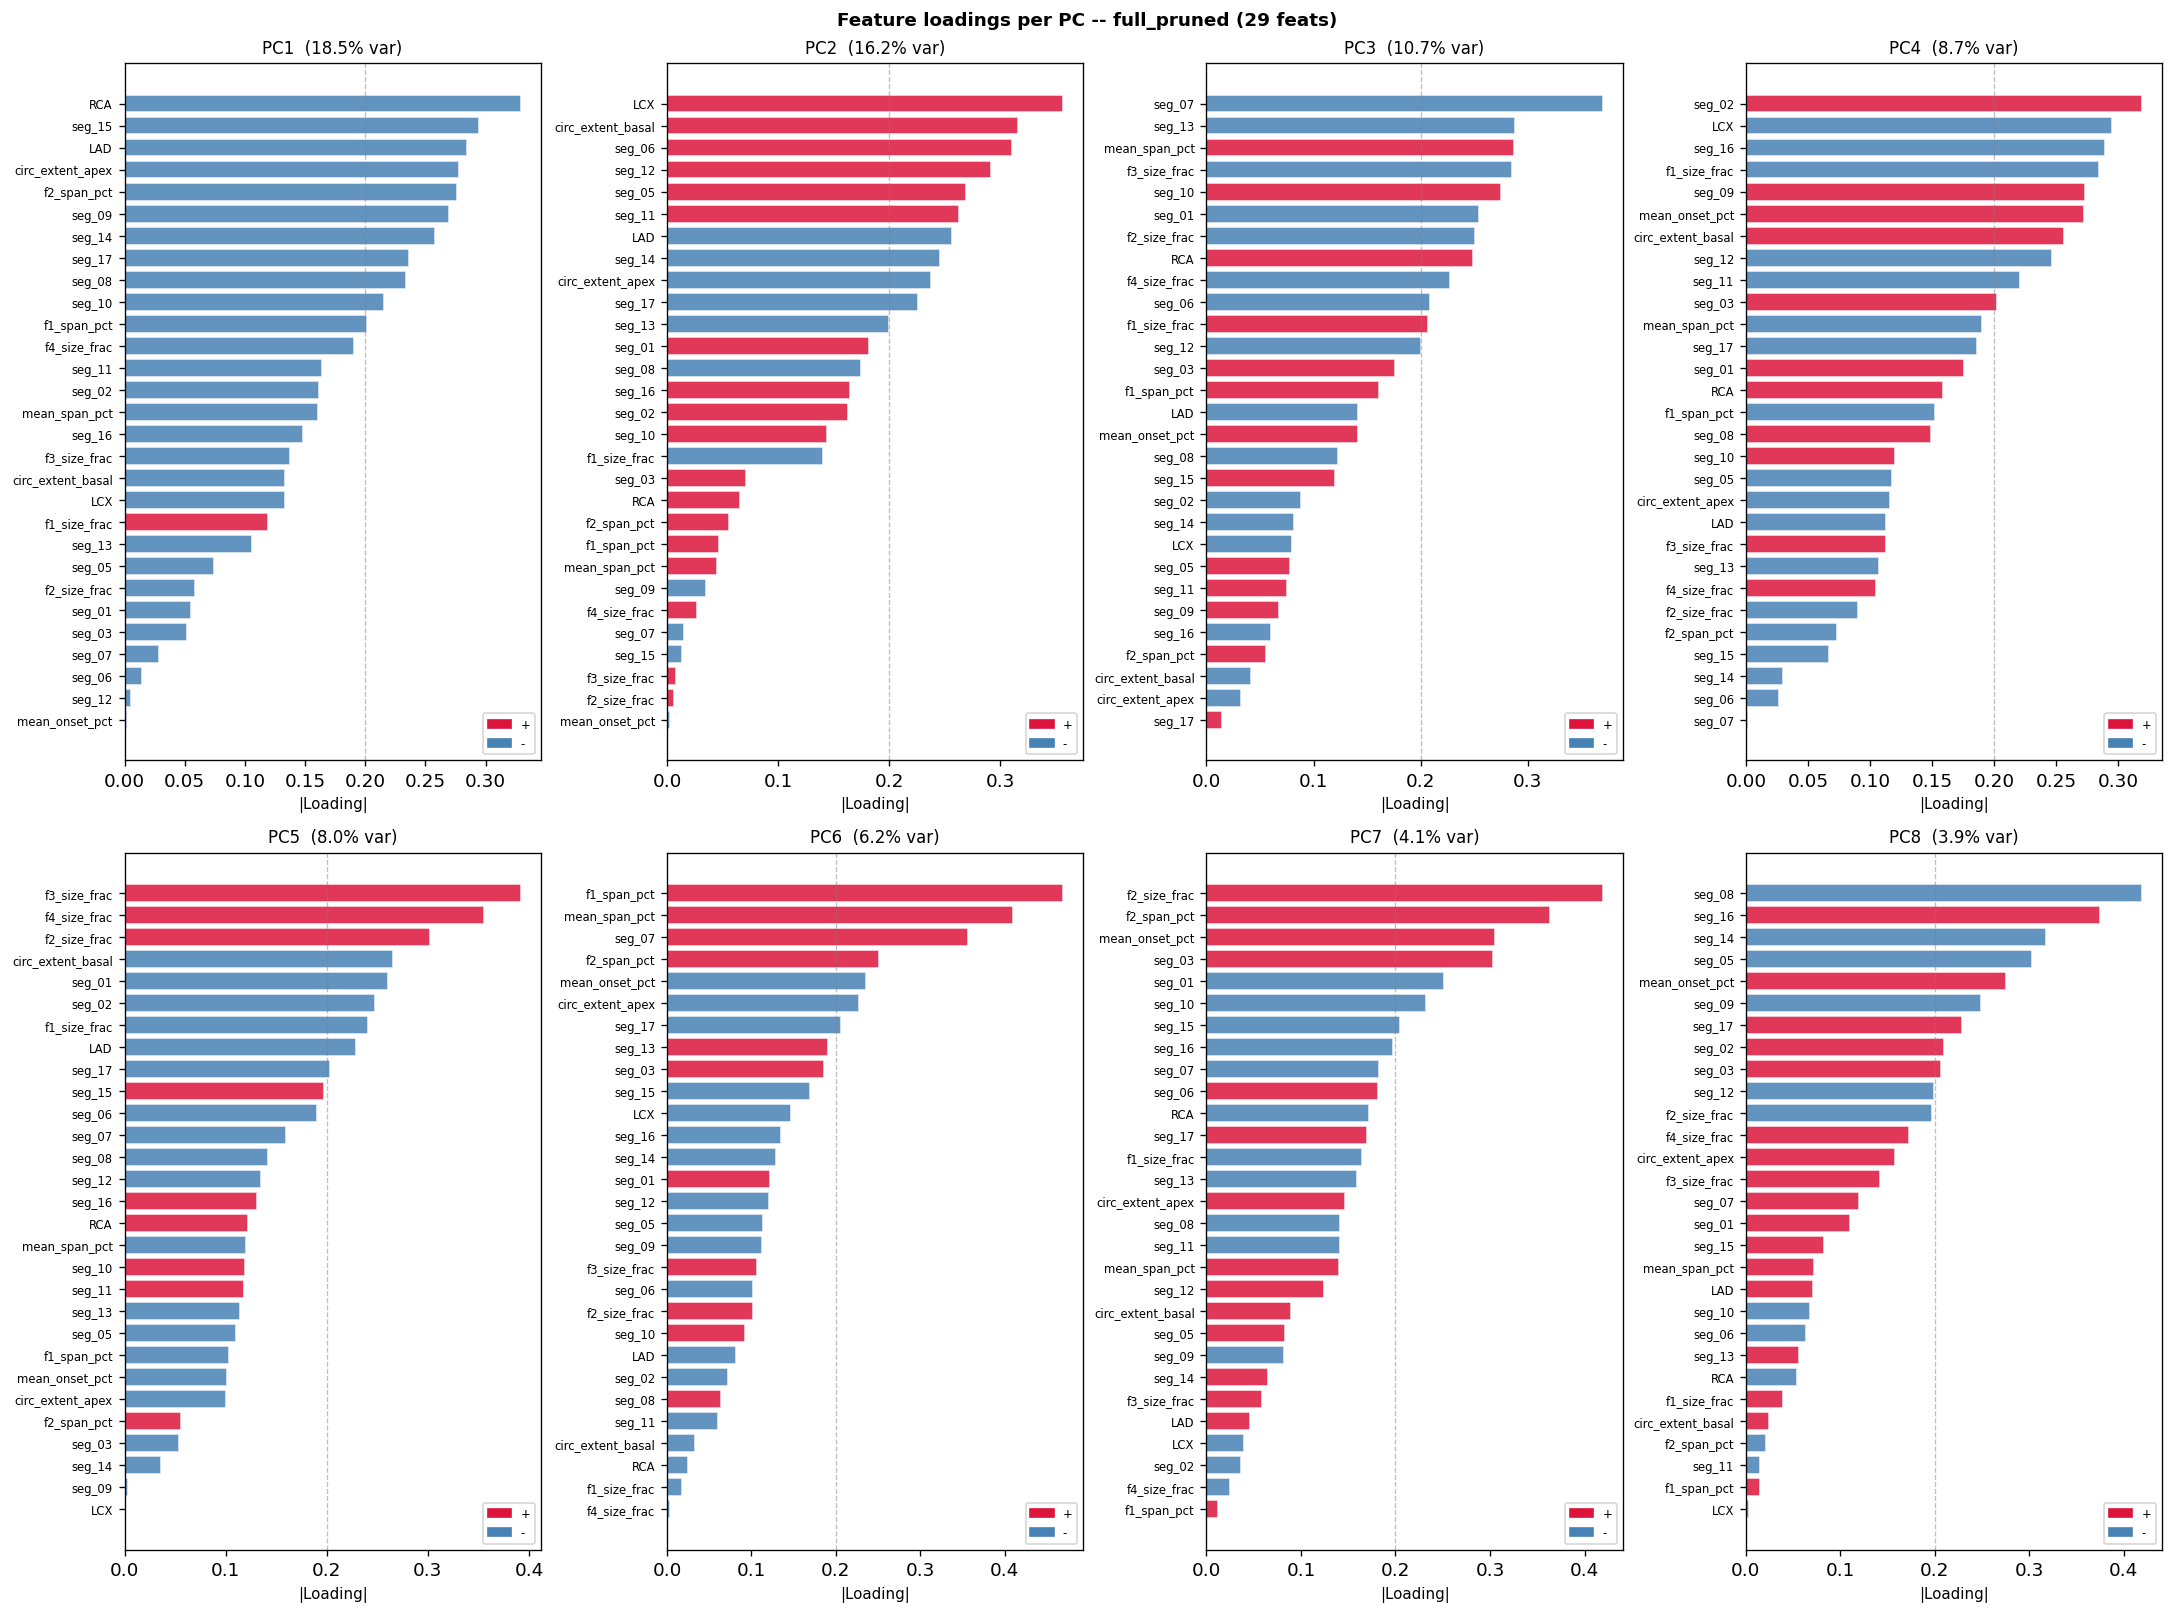

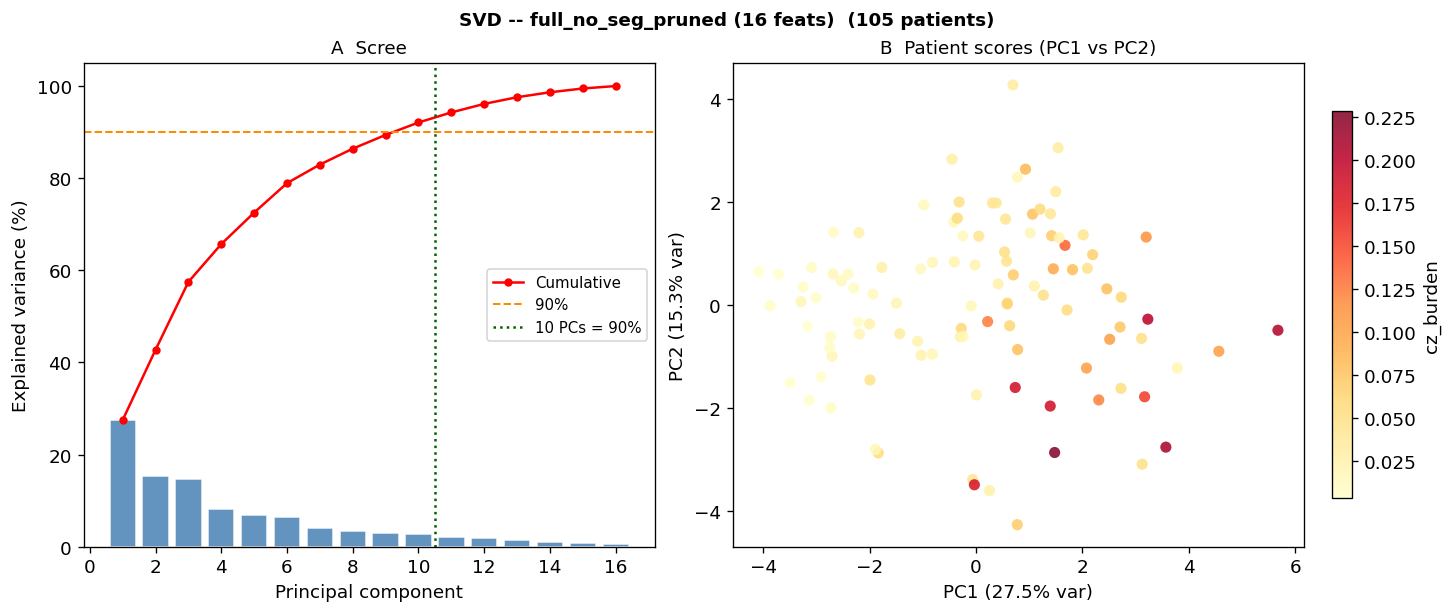

full_no_seg_pruned (16 feats): 10 PCs = 90% var.  Saved svd_full_ns_pruned.{pdf,png}


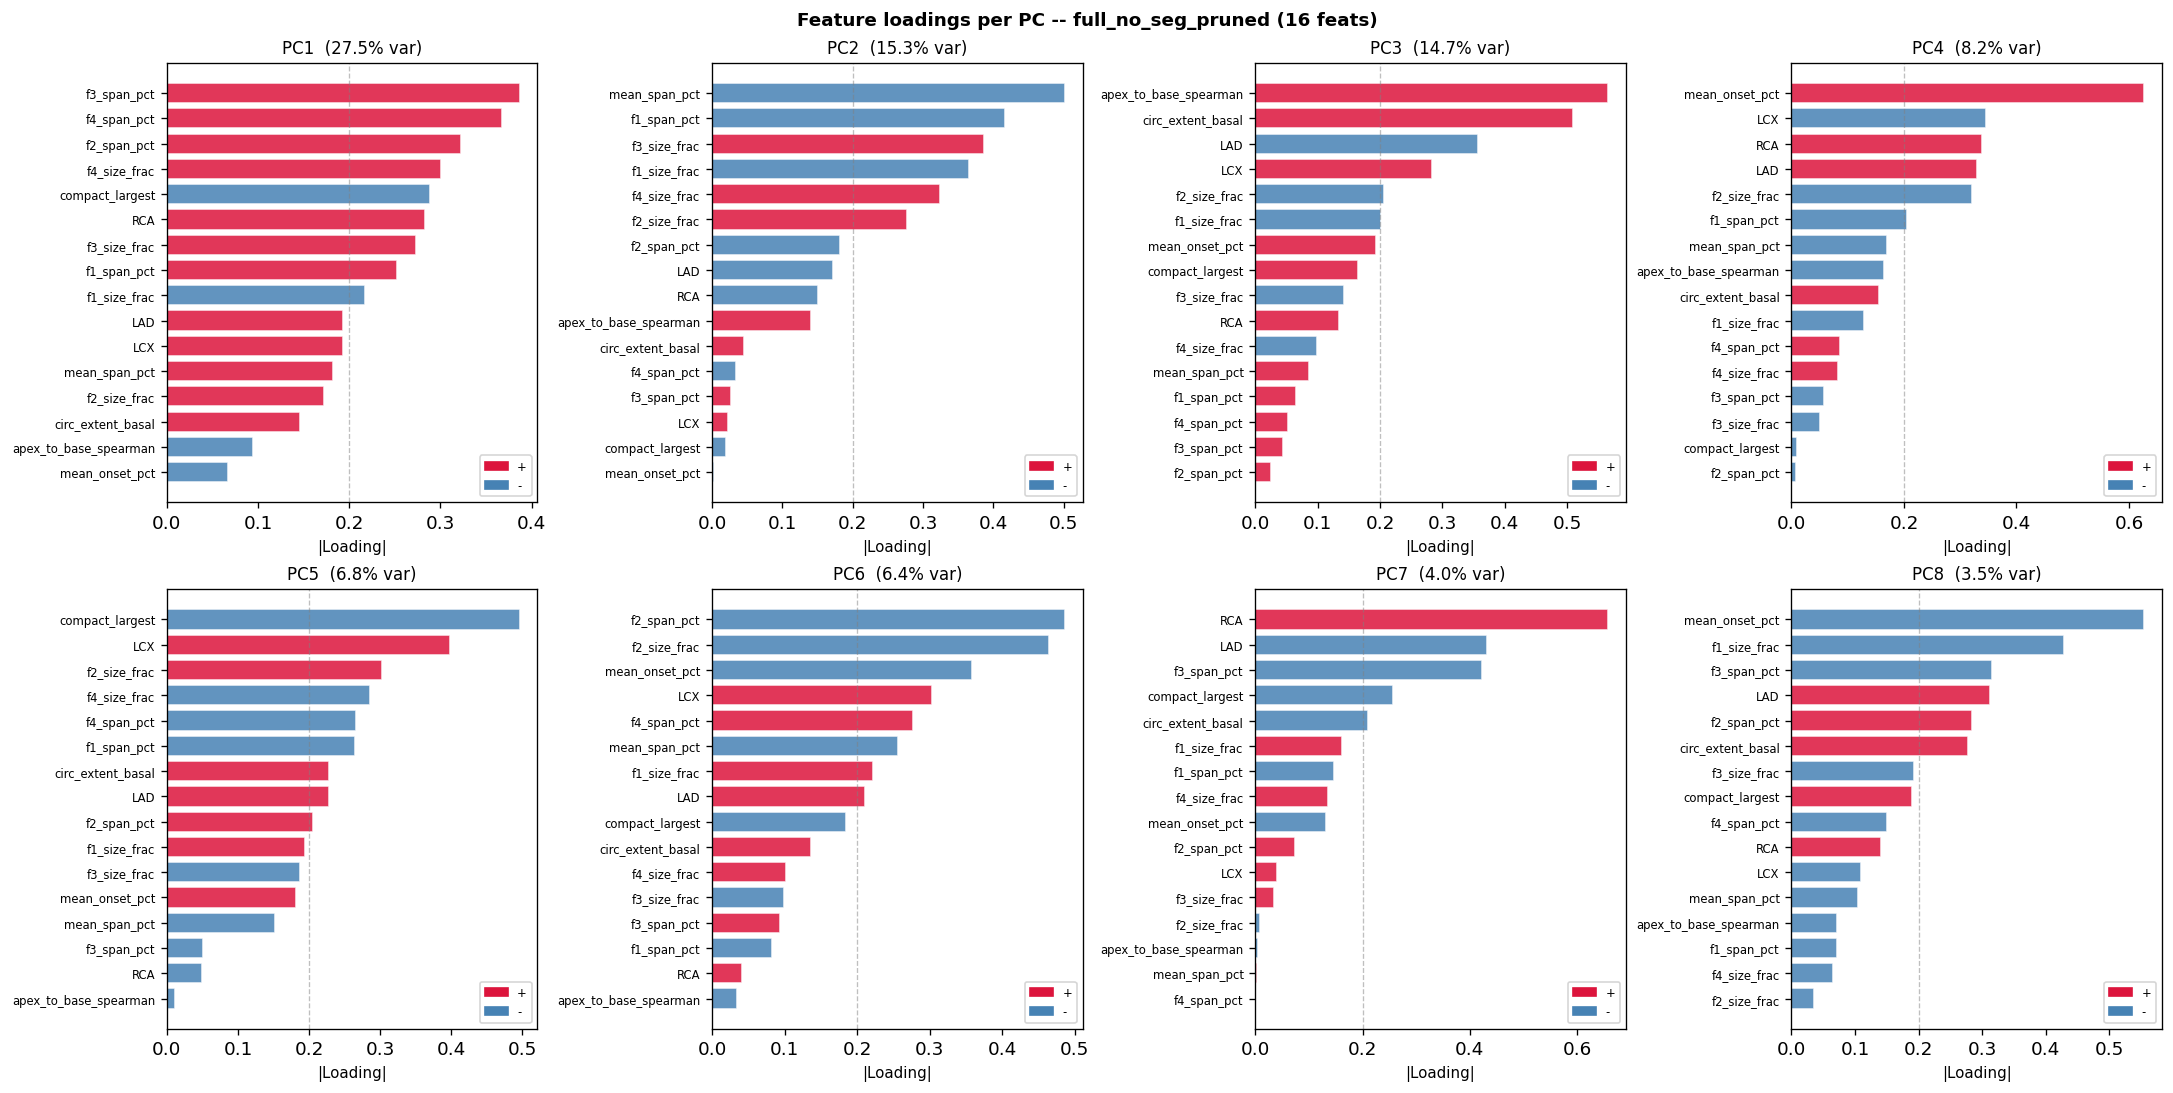

In [11]:
# -- 2b-v  Pruned vectors: drop bottom-Q25 contribution features ---------------
# From _contrib_results (cell above): features whose total SVD contribution
# across k PCs falls below the 25th-percentile are dropped.
# Rationale: these features add little independent signal to the compressed
# subspace and may introduce noise in Euclidean distance retrieval.

_pruned_vecs = {}

for vec_name, (feat_names, contrib, ord_asc, k) in _contrib_results.items():
    feat_names_arr = np.array(feat_names)
    _q25  = float(np.percentile(contrib, 25))
    _keep = contrib > _q25
    _keep_idx = np.where(_keep)[0]
    dropped   = feat_names_arr[~_keep].tolist()

    X_src = X_full if "no_seg" not in vec_name else X_full_ns
    X_pruned    = X_src[:, _keep_idx]
    feat_pruned = feat_names_arr[_keep_idx].tolist()

    short = "full_pruned" if "no_seg" not in vec_name else "full_no_seg_pruned"
    _pruned_vecs[short] = (X_pruned, feat_pruned)

    print(f"{vec_name}")
    print(f"  Q25 threshold = {_q25:.4f}")
    print(f"  Dropped {len(dropped)} features: {dropped}")
    print(f"  Kept {len(feat_pruned)} / {len(feat_names)} features: {feat_pruned}")

X_full_pruned,    feat_names_full_pruned    = _pruned_vecs["full_pruned"]
X_full_ns_pruned, feat_names_full_ns_pruned = _pruned_vecs["full_no_seg_pruned"]

# ── SVD for pruned vectors ────────────────────────────────────────────────────
_PRUNED_PAIRS = [
    (f"full_pruned ({X_full_pruned.shape[1]} feats)",       X_full_pruned,    feat_names_full_pruned),
    (f"full_no_seg_pruned ({X_full_ns_pruned.shape[1]} feats)", X_full_ns_pruned, feat_names_full_ns_pruned),
]

for vec_name, X_vec, feat_names in _PRUNED_PAIRS:
    n_feat = X_vec.shape[1]
    k = min(_K_SHOW, n_feat)
    Vt, ev, scores = _compute_svd(X_vec)
    cumev = np.cumsum(ev)
    n_components = len(ev)
    _n90 = int(np.searchsorted(cumev, 0.90)) + 1

    # -- Scree + PC1 vs PC2 scatter --
    fig_v, axes_v = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    fig_v.suptitle(f"SVD -- {vec_name}  ({len(df)} patients)", fontsize=11, fontweight="bold")

    _show_n = min(20, n_components)
    ax_sc = axes_v[0]
    ax_sc.bar(range(1, _show_n + 1), ev[:_show_n] * 100, color="steelblue", alpha=0.85, edgecolor="white")
    ax_sc.plot(range(1, _show_n + 1), cumev[:_show_n] * 100, "r-o", ms=4, lw=1.5, label="Cumulative")
    ax_sc.axhline(90, color="darkorange", ls="--", lw=1.2, label="90%")
    ax_sc.axvline(_n90 + 0.5, color="darkgreen", ls=":", lw=1.5, label=f"{_n90} PCs = 90%")
    ax_sc.set_xlabel("Principal component", fontsize=11)
    ax_sc.set_ylabel("Explained variance (%)", fontsize=11)
    ax_sc.set_title("A  Scree", fontsize=11)
    ax_sc.legend(fontsize=9)

    _pc1 = scores[:, 0]
    _pc2 = scores[:, 1] if n_components > 1 else np.zeros(len(scores))
    sc2 = axes_v[1].scatter(_pc1, _pc2, c=_scar_vals, cmap="YlOrRd", s=45, alpha=0.85,
                            edgecolors="none", zorder=2)
    plt.colorbar(sc2, ax=axes_v[1], label="cz_burden", shrink=0.8)
    axes_v[1].set_xlabel(f"PC1 ({ev[0]:.1%} var)", fontsize=11)
    axes_v[1].set_ylabel(f"PC2 ({ev[1]:.1%} var)" if n_components > 1 else "PC2", fontsize=11)
    axes_v[1].set_title("B  Patient scores (PC1 vs PC2)", fontsize=11)

    _fname_p = "svd_full_pruned" if "no_seg" not in vec_name else "svd_full_ns_pruned"
    fig_v.savefig(FIGURES / f"{_fname_p}.pdf", bbox_inches="tight")
    fig_v.savefig(FIGURES / f"{_fname_p}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{vec_name}: {_n90} PCs = 90% var.  Saved {_fname_p}.{{pdf,png}}")

    # -- Per-PC loading bar charts --
    _ncols_pc = 4
    _nrows_pc = int(np.ceil(k / _ncols_pc))
    fig_load, axes_load = plt.subplots(
        _nrows_pc, _ncols_pc,
        figsize=(_ncols_pc * 4.5, _nrows_pc * max(4.5, n_feat * 0.23)),
        constrained_layout=True,
    )
    fig_load.suptitle(f"Feature loadings per PC -- {vec_name}", fontsize=11, fontweight="bold")
    _al_flat = axes_load.ravel() if hasattr(axes_load, "ravel") else [axes_load]
    for pc_i in range(k):
        ax_l = _al_flat[pc_i]
        _load = Vt[pc_i, :]
        _ord_l = np.argsort(np.abs(_load))
        _cols_l = ["crimson" if _load[i] >= 0 else "steelblue" for i in _ord_l]
        ax_l.barh(range(n_feat), np.abs(_load[_ord_l]), color=_cols_l, alpha=0.85, edgecolor="white")
        ax_l.set_yticks(range(n_feat))
        ax_l.set_yticklabels([feat_names[i] for i in _ord_l], fontsize=7)
        ax_l.set_xlabel("|Loading|", fontsize=9)
        ax_l.set_title(f"PC{pc_i+1}  ({ev[pc_i]:.1%} var)", fontsize=10)
        ax_l.axvline(0.2, color="grey", ls="--", lw=0.8, alpha=0.5)
        from matplotlib.patches import Patch as _Patch
        ax_l.legend(handles=[_Patch(color="crimson", label="+"), _Patch(color="steelblue", label="-")],
                    fontsize=7, loc="lower right")
    for _ax in _al_flat[k:]:
        _ax.set_visible(False)
    fig_load.savefig(FIGURES / f"{_fname_p}_loadings.pdf", bbox_inches="tight")
    fig_load.savefig(FIGURES / f"{_fname_p}_loadings.png", dpi=150, bbox_inches="tight")
    plt.show()


### 2c — Polar-map PCA

Running PCA directly on the flattened binary polar maps (64 × 128 = 8 192 pixels, n = full cohort) extracts spatial modes not captured by the 17 AHA segment burdens:

| Component | Likely spatial meaning |
|---|---|
| PC1 | Total scar burden (correlated with `cz_burden`) |
| PC2 | Anterior vs inferior territory |
| PC3 | Apical vs basal gradient |
| PC4 | Lateral vs septal |
| PC5–8 | Within-territory fine grain and transmurality variation |

The `N_PCA_PMAP = 8` scores are appended to the minimal feature vector, growing it from 18 to 26 dimensions (`X_min_ext`).  The `_K_SHOW = 8` convention from section 2b is preserved for easy comparison.


Polar-map PCA: 8 PCs explain 42.5% of polar-map variance.
Extended minimal vector: 26 dims (18 structured + 8 PCA)


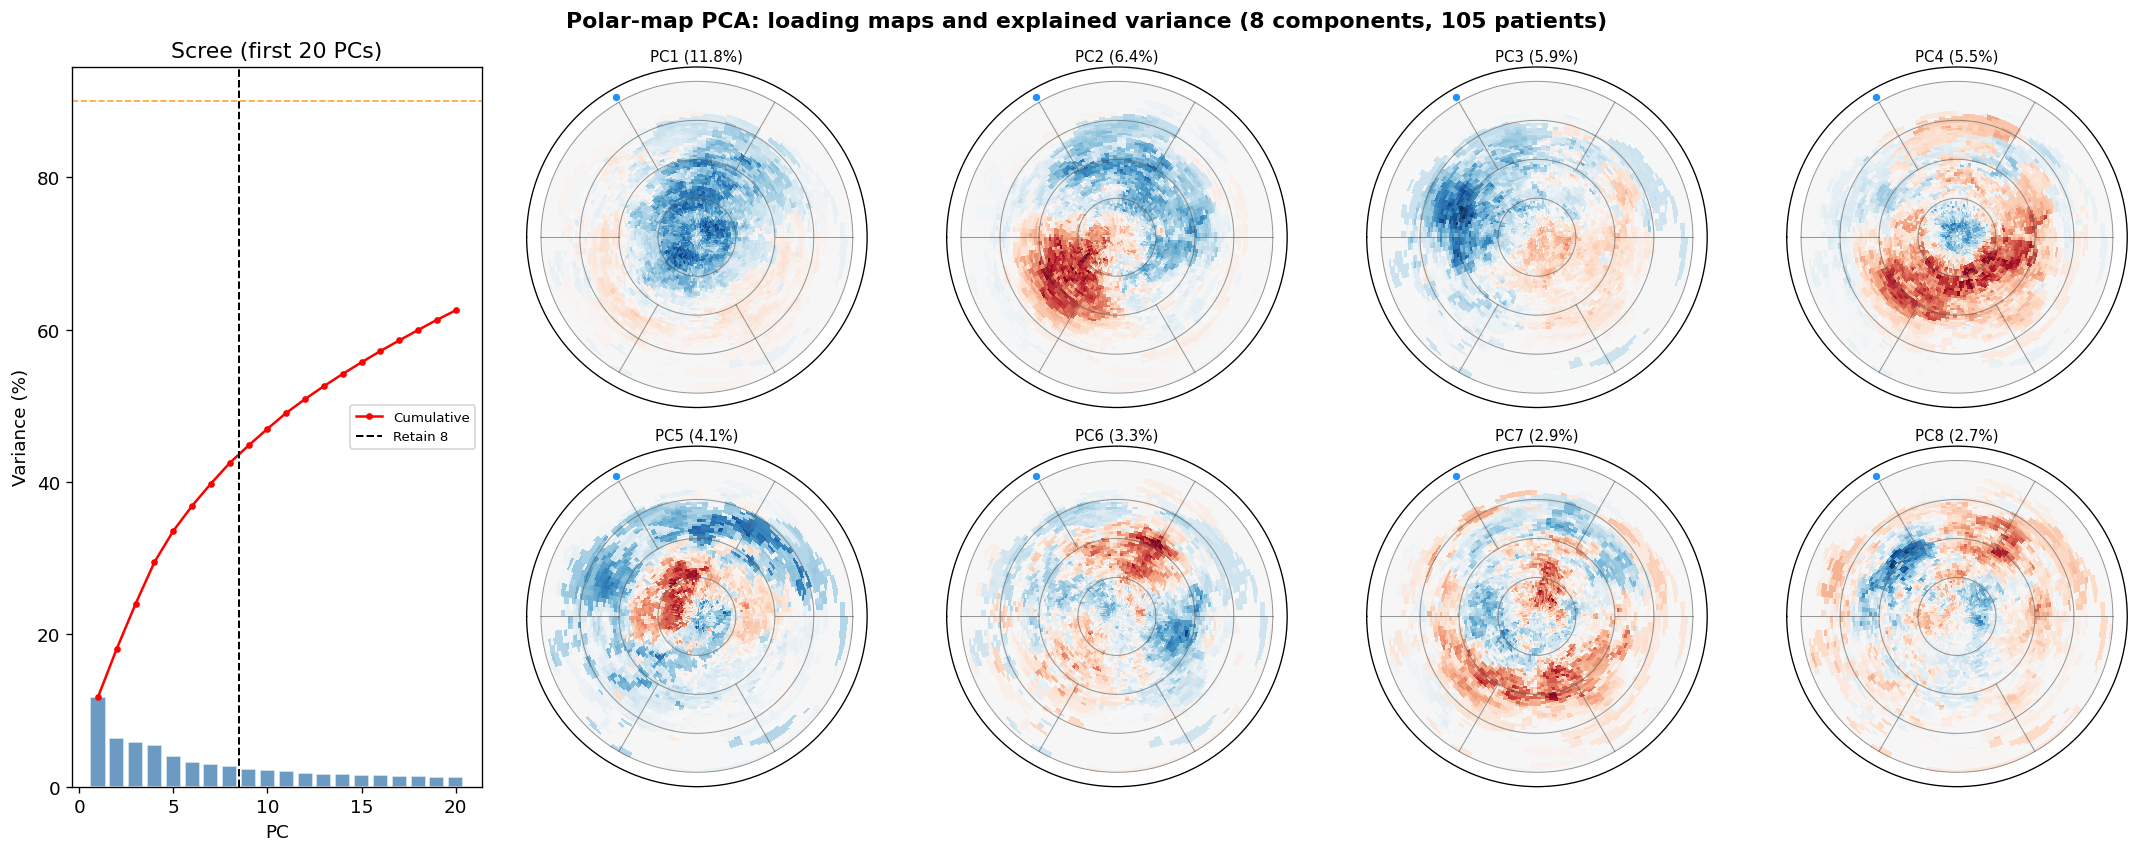

Saved pmap_pca_analysis.{pdf,png}
Grid (pmap-only) vector: (105, 8)  -- no structured features
full_no_seg+pmap vector: 30 dims (22 struct + 8 PCA)
Unified pool: 105 full-cohort patients


In [12]:
# ── 2c  Polar-map PCA — append spatial-mode scores to feature matrix ─────────────
N_PCA_PMAP = 8  # components to retain

# Stack polar maps in df row order (guarantees alignment with X_min etc.)
_P_stack = np.stack([pmaps[k] for k in df['key']], axis=0)  # (n, N_R, N_THETA)
_P_flat  = _P_stack.reshape(len(df), -1).astype(float)      # (n, N_R*N_THETA)

# Mean-centre → SVD  (= PCA without per-pixel variance scaling)
_P_mean = _P_flat.mean(axis=0)
_Pc     = _P_flat - _P_mean
_Up, _Sp, _Vtp = np.linalg.svd(_Pc, full_matrices=False)

_pmap_ev    = (_Sp ** 2) / (_Sp ** 2).sum()
_pmap_cumev = np.cumsum(_pmap_ev)
pmap_scores = _Pc @ _Vtp[:N_PCA_PMAP].T   # (n, N_PCA_PMAP)

PMAP_PCA_NAMES = [f'pmap_pc{i+1}' for i in range(N_PCA_PMAP)]

# Append to minimal feature matrix
X_min_ext          = np.hstack([X_min, pmap_scores])    # (n, 18 + N_PCA_PMAP)
feat_names_min_ext = feat_names_min + PMAP_PCA_NAMES

print(f'Polar-map PCA: {N_PCA_PMAP} PCs explain '
      f'{_pmap_cumev[N_PCA_PMAP - 1]:.1%} of polar-map variance.')
print(f'Extended minimal vector: {X_min_ext.shape[1]} dims '
      f'({len(feat_names_min)} structured + {N_PCA_PMAP} PCA)')

# ── Visualise: scree + PC loading maps ────────────────────────────────────────

def _draw_loading_bullseye(loading_2d, ax, title=None):
    arr = loading_2d
    vmax = max(float(np.abs(arr).max()), 1e-12)
    T, R = np.meshgrid(
        np.linspace(0, 2 * np.pi, arr.shape[1] + 1),
        np.linspace(0, 1.0,       arr.shape[0] + 1),
    )
    ax.set_theta_zero_location('W')
    ax.set_theta_direction(-1)
    ax.pcolormesh(T, R, arr, cmap='RdBu_r', vmin=-vmax, vmax=vmax, shading='flat')
    _draw_bullseye_grid(ax)
    if title:
        ax.set_title(title, fontsize=9, pad=4)

fig_pca = plt.figure(figsize=(18, 7), constrained_layout=True)
fig_pca.suptitle(
    f'Polar-map PCA: loading maps and explained variance '
    f'({N_PCA_PMAP} components, {len(df)} patients)',
    fontweight='bold',
)
gs_pca = fig_pca.add_gridspec(2, 5)

# Scree plot spans both rows
ax_sc = fig_pca.add_subplot(gs_pca[:, 0])
ax_sc.bar(range(1, 21), _pmap_ev[:20] * 100,
          color='steelblue', alpha=0.8, edgecolor='white')
ax_sc.plot(range(1, 21), _pmap_cumev[:20] * 100,
           'r-o', ms=3, lw=1.5, label='Cumulative')
ax_sc.axvline(N_PCA_PMAP + 0.5, color='k', ls='--', lw=1.2,
              label=f'Retain {N_PCA_PMAP}')
ax_sc.axhline(90, color='darkorange', ls='--', lw=1.0, alpha=0.8)
ax_sc.set_xlabel('PC')
ax_sc.set_ylabel('Variance (%)')
ax_sc.set_title('Scree (first 20 PCs)')
ax_sc.legend(fontsize=8)

# PC1-8 loading maps: row 0 → PC1-4 (cols 1-4), row 1 → PC5-8 (cols 1-4)
for idx in range(N_PCA_PMAP):
    row, col = divmod(idx, 4)
    ax = fig_pca.add_subplot(gs_pca[row, col + 1], projection='polar')
    _draw_loading_bullseye(
        _Vtp[idx].reshape(N_R, N_THETA), ax,
        title=f'PC{idx+1} ({_pmap_ev[idx]:.1%})',
    )

fig_pca.savefig(FIGURES / 'pmap_pca_analysis.pdf', bbox_inches='tight')
fig_pca.savefig(FIGURES / 'pmap_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved pmap_pca_analysis.{pdf,png}')

# Full-cohort retrieval pool
# Every patient remains in the case base; leave-one-out excludes only the target.
X_pmap_only = pmap_scores
feat_names_pmap_only = PMAP_PCA_NAMES
print(f'Grid (pmap-only) vector: {X_pmap_only.shape}  -- no structured features')

# Combined vector: full_no_seg + pmap_only
X_full_ns_pmap = np.hstack([X_full_ns, X_pmap_only])
feat_names_full_ns_pmap = feat_names_full_ns + feat_names_pmap_only
print(f'full_no_seg+pmap vector: {X_full_ns_pmap.shape[1]} dims '
      f'({len(feat_names_full_ns)} struct + {len(feat_names_pmap_only)} PCA)')

pmaps_all = dict(pmaps)
keys_all = list(df['key'])
X_min_all = X_min
X_pmap_all = X_pmap_only
scar_burden_all = {row['key']: float(row['total_scar']) for _, row in df.iterrows()}

print(f'Unified pool: {len(keys_all)} full-cohort patients')


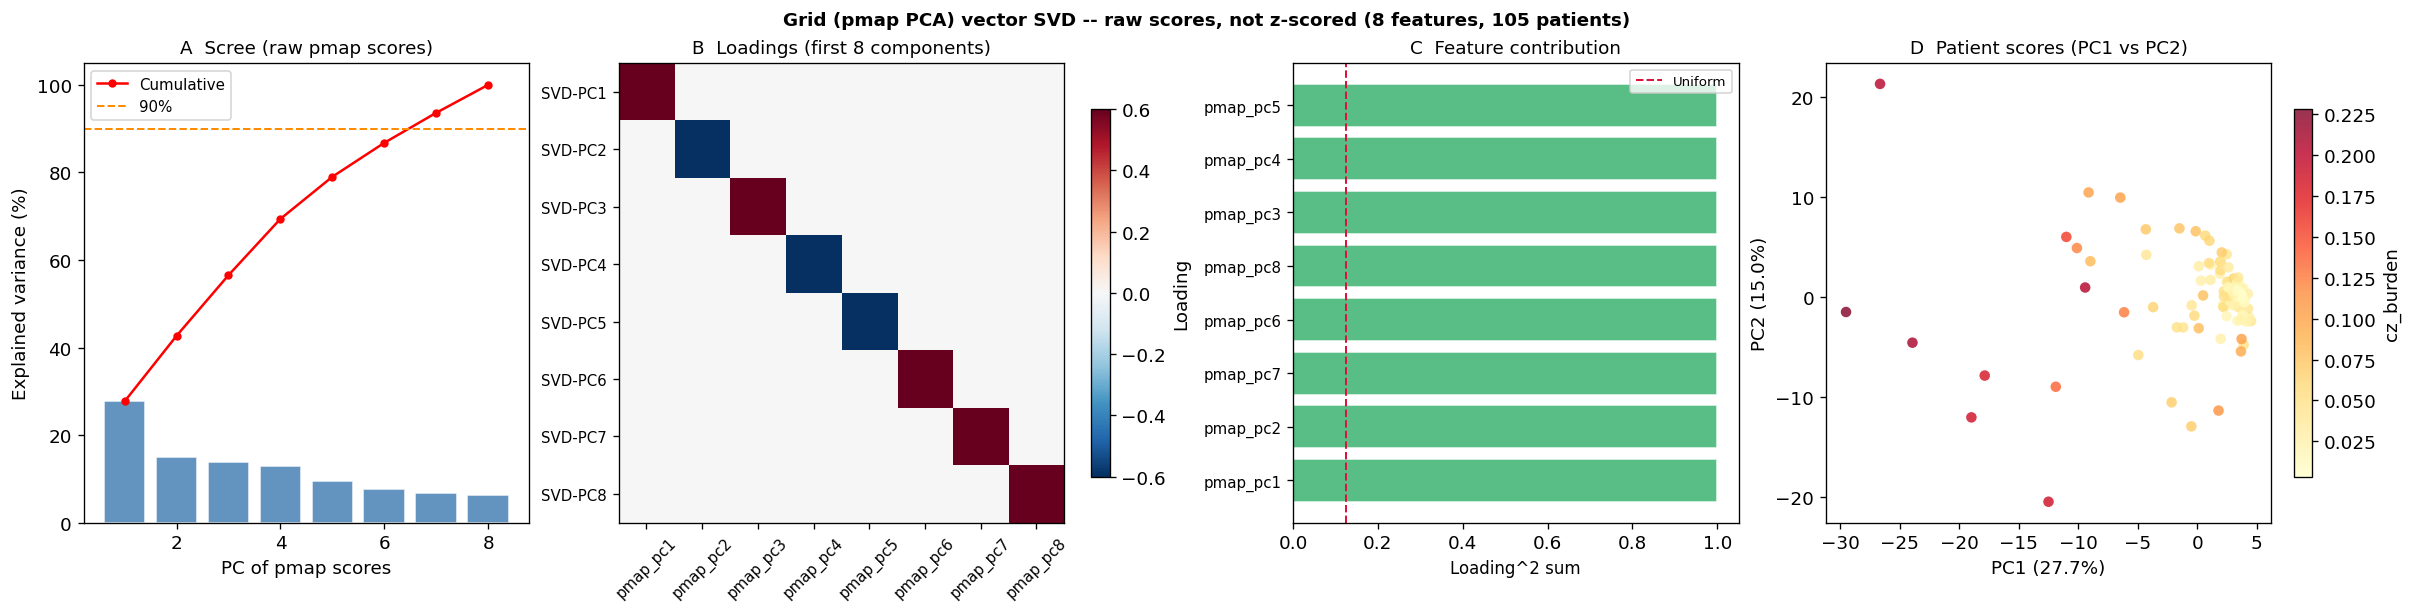

Grid vector SVD saved. PC1=27.7%, PC2=15.0%
Note: pmap PCA scores are already orthogonal -- SVD mixes them further.
      pmap_pc1 (most polar-map variance) dominates here as expected.


In [13]:
# -- 2b-iv  Grid vector (pmap PCA only) -- SVD analysis -----------------------
# pmap_scores are already PCA scores from polar-map PCA.
# They are orthogonal by construction. Do NOT z-score before SVD --
# that would equalise all variances and produce trivially equal eigenvalues.
# Instead SVD the raw (already mean-centred) scores to see true variance structure.

_K_SHOW_P = N_PCA_PMAP

# Mean-centre pmap_scores (each PC score has zero mean by PCA construction already)
_mu_praw  = np.mean(X_pmap_only, axis=0)
X_pmap_raw = X_pmap_only - _mu_praw   # (n, N_PCA_PMAP) -- raw, NOT z-scored

U_pz, S_pz, Vt_pz = np.linalg.svd(X_pmap_raw, full_matrices=False)
ev_pz   = (S_pz ** 2) / np.sum(S_pz ** 2)
cumev_pz = np.cumsum(ev_pz)

# PC scores for scatter
_pmap_pc1 = U_pz[:, 0] * S_pz[0]
_pmap_pc2 = U_pz[:, 1] * S_pz[1]
_svd_coords = {}
_svd_coords = {}
_svd_coords = {}
_svd_coords['pmap_only'] = (_pmap_pc1, _pmap_pc2)

fig_pmap_svd, axes_ps = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
fig_pmap_svd.suptitle(
    f'Grid (pmap PCA) vector SVD -- raw scores, not z-scored ({N_PCA_PMAP} features, {len(df)} patients)',
    fontsize=11, fontweight='bold',
)

# A: Scree (meaningful because raw scores have decaying variance)
axes_ps[0].bar(range(1, len(S_pz)+1), ev_pz*100, color='steelblue', alpha=0.85, edgecolor='white')
axes_ps[0].plot(range(1, len(S_pz)+1), cumev_pz*100, 'r-o', ms=4, lw=1.5, label='Cumulative')
axes_ps[0].axhline(90, color='darkorange', ls='--', lw=1.2, label='90%')
axes_ps[0].set_xlabel('PC of pmap scores', fontsize=11)
axes_ps[0].set_ylabel('Explained variance (%)', fontsize=11)
axes_ps[0].set_title('A  Scree (raw pmap scores)', fontsize=11)
axes_ps[0].legend(fontsize=9)

# B: Loading heatmap (how pmap PCs mix in SVD components)
im_ps = axes_ps[1].imshow(Vt_pz[:_K_SHOW_P, :], cmap='RdBu_r', aspect='auto', vmin=-0.6, vmax=0.6)
axes_ps[1].set_yticks(range(_K_SHOW_P))
axes_ps[1].set_yticklabels([f'SVD-PC{i+1}' for i in range(_K_SHOW_P)], fontsize=9)
axes_ps[1].set_xticks(range(len(feat_names_pmap_only)))
axes_ps[1].set_xticklabels(feat_names_pmap_only, rotation=45, fontsize=9)
axes_ps[1].set_title(f'B  Loadings (first {_K_SHOW_P} components)', fontsize=11)
plt.colorbar(im_ps, ax=axes_ps[1], label='Loading', shrink=0.8)

# C: Feature contribution
_contrib_ps = np.sum(Vt_pz[:_K_SHOW_P, :] ** 2, axis=0)
_ord_ps = np.argsort(_contrib_ps)[::-1]
axes_ps[2].barh(range(len(feat_names_pmap_only)), _contrib_ps[_ord_ps][::-1],
                color='mediumseagreen', alpha=0.85, edgecolor='white')
axes_ps[2].set_yticks(range(len(feat_names_pmap_only)))
axes_ps[2].set_yticklabels([feat_names_pmap_only[i] for i in _ord_ps][::-1], fontsize=9)
axes_ps[2].set_xlabel(f'Loading^2 sum', fontsize=10)
axes_ps[2].set_title('C  Feature contribution', fontsize=11)
axes_ps[2].axvline(1.0/len(feat_names_pmap_only), color='crimson', ls='--', lw=1.2, label='Uniform')
axes_ps[2].legend(fontsize=8)

# D: PC1 vs PC2 patient scatter
sc_ps = axes_ps[3].scatter(_pmap_pc1, _pmap_pc2,
                            c=df['cz_burden'].to_numpy(float), cmap='YlOrRd',
                            s=40, alpha=0.8, edgecolors='none')
plt.colorbar(sc_ps, ax=axes_ps[3], label='cz_burden', shrink=0.8)
axes_ps[3].set_xlabel(f'PC1 ({ev_pz[0]:.1%})', fontsize=11)
axes_ps[3].set_ylabel(f'PC2 ({ev_pz[1]:.1%})', fontsize=11)
axes_ps[3].set_title('D  Patient scores (PC1 vs PC2)', fontsize=11)

fig_pmap_svd.savefig(FIGURES / 'svd_pmap_only.pdf', bbox_inches='tight')
fig_pmap_svd.savefig(FIGURES / 'svd_pmap_only.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Grid vector SVD saved. PC1={ev_pz[0]:.1%}, PC2={ev_pz[1]:.1%}')
print('Note: pmap PCA scores are already orthogonal -- SVD mixes them further.')
print('      pmap_pc1 (most polar-map variance) dominates here as expected.')

## 3 — Distance metrics & retrieval engine

Four distance metrics are implemented.  The **weighted Euclidean** metric (Lawson et al. 2024) is the primary method: each dimension is divided by its population standard deviation so that features with large variance do not dominate the similarity score.

$$d_i = \sqrt{\sum_j \frac{(v_{\text{target},j} - v_{i,j})^2}{s_j^2}}$$

where $s_j$ is the standard deviation of feature $j$ across the case base.

In [14]:
def _zscore_normalise(X_target, X_base):
    """Z-score normalise target and base using base statistics."""
    mu = np.nanmean(X_base, axis=0)
    sd = np.nanstd(X_base, axis=0, ddof=1)
    sd[sd < 1e-12] = 1.0   # avoid division by zero for constant features
    return (X_target - mu) / sd, (X_base - mu) / sd


def _distances(target_vec, case_matrix, method, weights=None):
    """
    Compute distances between target_vec and every row in case_matrix.

    Returns
    -------
    dists : np.ndarray, shape (n_cases,)
    """
    t = np.asarray(target_vec, dtype=float).reshape(1, -1)
    C = np.asarray(case_matrix, dtype=float)

    if method == 'euclidean':
        t_n, C_n = _zscore_normalise(t, C)
        return cdist(t_n, C_n, metric='euclidean').ravel()

    elif method == 'weighted_euclidean':
        sd = np.nanstd(C, axis=0, ddof=1)
        sd[sd < 1e-12] = 1.0
        diff = t - C            # (n_cases, n_features)
        return np.sqrt(np.nansum((diff / sd) ** 2, axis=1))

    elif method == 'manhattan':
        t_n, C_n = _zscore_normalise(t, C)
        return cdist(t_n, C_n, metric='cityblock').ravel()

    elif method == 'cosine':
        return cdist(t, C, metric='cosine').ravel()

    else:
        raise ValueError(f"Unknown method '{method}'.")


def retrieve(target_profile, case_base, method='weighted_euclidean', k=5, weights=None):
    """
    Retrieve the top-k closest patients from case_base.

    Parameters
    ----------
    target_profile : array-like, shape (n_features,)
    case_base      : np.ndarray, shape (n_cases, n_features)
    method         : {'weighted_euclidean', 'euclidean', 'manhattan', 'cosine'}
    k              : number of neighbours to return
    weights        : ignored (reserved for future weighted feature subset)

    Returns
    -------
    indices : np.ndarray, shape (k,)  — indices into case_base rows
    dists   : np.ndarray, shape (k,)  — corresponding distances
    probs   : np.ndarray, shape (k,)  — softmax sampling weights
    """
    dists_all = _distances(target_profile, case_base, method, weights)

    # Handle ties: shuffle before argsort so tied distances produce random order
    order = np.argsort(dists_all, kind='stable')
    k_eff = min(k, len(order))
    top_idx   = order[:k_eff]
    top_dists = dists_all[top_idx]

    # Softmax over negative distances → sampling probabilities
    probs = softmax(-top_dists)

    return top_idx, top_dists, probs


METHODS = ['weighted_euclidean', 'euclidean', 'manhattan', 'cosine']
print('Retrieval engine ready.  Methods:', METHODS)

Retrieval engine ready.  Methods: ['weighted_euclidean', 'euclidean', 'manhattan', 'cosine']


## 4 — Vector analysis

Six feature vectors are compared with leave-one-out retrieval.
For vectors requiring M04 features (`full`, `full_no_seg`, pruned variants),
LOO runs on the full 105-patient cohort for every vector available from M04 outputs.

### 4-latent — Latent space exploration

Projecting all patients to 2-D via PCA (z-scored minimal features) reveals
the geometry of the unified case base.

### 4a — Illustrative retrieval: six feature vectors

| Vector | Dims | Description |
|--------|------|-------------|
| `full` | 39 | All structured features (segments + territory + morphology + fragments) |
| `full_no_seg` | 22 | Same minus AHA-17 segment burdens |
| `full_pruned` | N | `full` after dropping bottom-Q25 SVD contributors |
| `full_ns_pruned` | M | `full_no_seg` after pruning |
| `pmap_only` | 8 | Polar-map PCA scores — pure spatial, no structured features |
| `full_ns+pmap` | 30 | `full_no_seg` concatenated with polar-map PCA scores |

Statistics to select the best vector are in **§4a-stats**;
deterministic and probabilistic retrieval with the winner follow in **§5**.


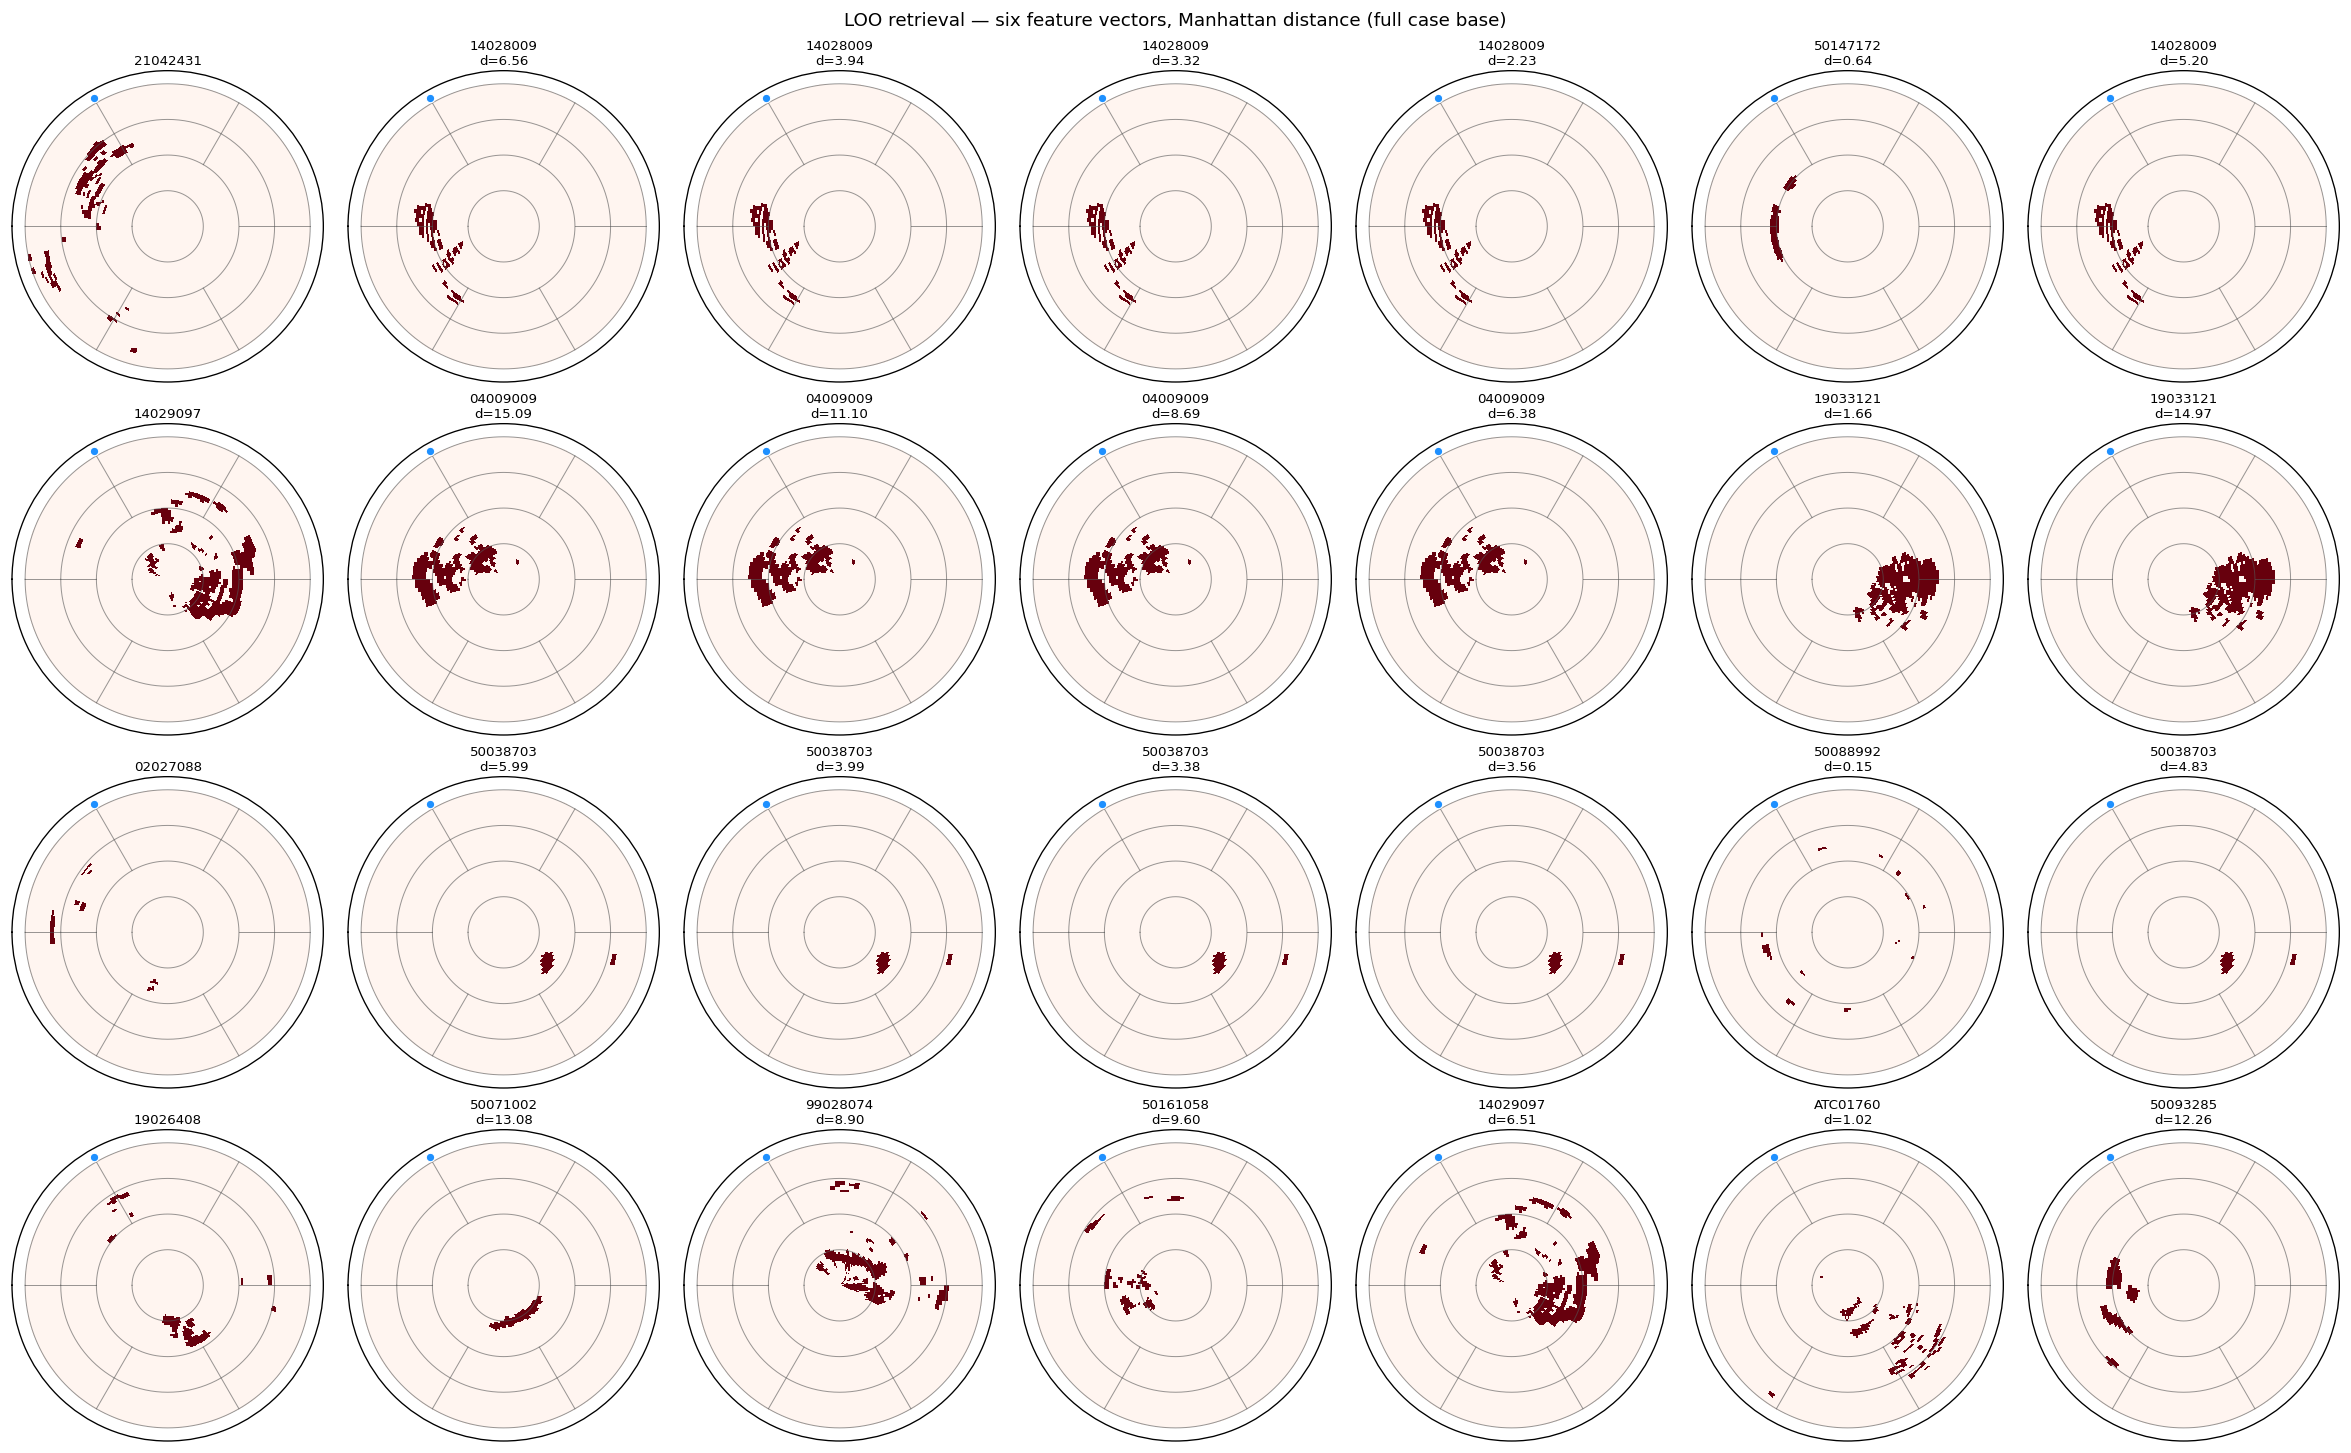

Saved retrieval_six_vectors.{pdf,png}


In [15]:
# ── 4a  Illustrative retrieval: six feature vectors side-by-side (LOO) ───────
# LOO on full case base — all five vectors require M04-derived features,
# so full-cohort patients (pmap-derived only) are not used here.
_COMPARE_VECS_4A = [
    ('full',           X_full,           feat_names_full),
    ('full_no_seg',    X_full_ns,        feat_names_full_ns),
    ('full_pruned',    X_full_pruned,    feat_names_full_pruned),
    ('full_ns_pruned', X_full_ns_pruned, feat_names_full_ns_pruned),
    ('pmap_only',      X_pmap_only,      feat_names_pmap_only),
    ('full_ns+pmap',   X_full_ns_pmap,   feat_names_full_ns_pmap),
]

_DEMO_N_4A = 4
_demo_idx_4a  = sorted(RNG.choice(len(df), size=_DEMO_N_4A, replace=False).tolist())
_demo_keys_4a = [df.iloc[i]['key'] for i in _demo_idx_4a]

_N_COLS_4A = 1 + len(_COMPARE_VECS_4A)
fig_4a, axes_4a = plt.subplots(
    _DEMO_N_4A, _N_COLS_4A,
    figsize=(_N_COLS_4A * 2.8, _DEMO_N_4A * 3.0),
    subplot_kw={'projection': 'polar'},
    constrained_layout=True,
)
if _DEMO_N_4A == 1:
    axes_4a = axes_4a[np.newaxis, :]
fig_4a.suptitle('LOO retrieval — six feature vectors, Manhattan distance (full case base)', fontsize=11)

_col_labels_4a = ['Target'] + [v[0] for v in _COMPARE_VECS_4A]
for col_i, lbl in enumerate(_col_labels_4a):
    axes_4a[0, col_i].set_title(lbl, fontsize=8, fontweight='bold', pad=14)

for row_i, (tgt_idx, tgt_key) in enumerate(zip(_demo_idx_4a, _demo_keys_4a)):
    tgt_map = pmaps.get(tgt_key)
    tgt_pid = tgt_key.split('/')[-1]
    if tgt_map is not None:
        draw_bullseye(tgt_map, axes_4a[row_i, 0], title=tgt_pid, cmap='Reds', vmax=1.0)
    else:
        axes_4a[row_i, 0].set_title(f'{tgt_pid}\n(no map)', fontsize=7)

    mask_loo = np.ones(len(df), dtype=bool)
    mask_loo[tgt_idx] = False
    base_idx_loo = np.where(mask_loo)[0]

    for col_i, (vname, Xv, _fn) in enumerate(_COMPARE_VECS_4A):
        tgt_vec = Xv[tgt_idx]
        X_base  = Xv[mask_loo]
        top_local, top_dists, _ = retrieve(tgt_vec, X_base, k=1, method='manhattan')
        ret_global = base_idx_loo[top_local[0]]
        ret_key = df.iloc[ret_global]['key']
        ret_map = pmaps.get(ret_key)
        ret_pid = ret_key.split('/')[-1]
        dist    = top_dists[0]
        ax = axes_4a[row_i, col_i + 1]
        if ret_map is not None:
            draw_bullseye(ret_map, ax, title=f'{ret_pid}\nd={dist:.2f}', cmap='Reds', vmax=1.0)
        else:
            ax.set_title(f'{ret_pid}\nd={dist:.2f}\n(no map)', fontsize=7)

# Store first demo pair keys for 4a-bis (use full vector)
_idx0_3d = _demo_idx_4a[0]
_tgt_key_3d = _demo_keys_4a[0]
_m0_3d = np.ones(len(df), bool)
_m0_3d[_idx0_3d] = False
_t0_3d, _d_3d, _ = retrieve(X_full[_idx0_3d], X_full[_m0_3d], k=1, method='manhattan')
_ret_key_3d = df.iloc[np.where(_m0_3d)[0][_t0_3d[0]]]['key']
_d_3d = [_d_3d[0]]
_use_held = False  # downstream cells expect this flag

fig_4a.savefig(FIGURES / 'retrieval_six_vectors.pdf', bbox_inches='tight')
fig_4a.savefig(FIGURES / 'retrieval_six_vectors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved retrieval_six_vectors.{pdf,png}')

### 4a-stats — LOO statistics: selecting the best vector

Leave-one-out retrieval on all six vectors. Three components are reported separately; a composite score is used only to automate vector selection.

#### Metric definitions

| Metric | Formula | Range | Direction |
|---|---|---|---|
| **scar\_err\_abs** | \|CZ burden\_target − CZ burden\_retrieved\| | [0, 1] | lower = better |
| **seg\_dice** | 2·\|A∩B\| / (\|A\|+\|B\|), where A/B = AHA-17 segments with burden > 5 % | [0, 1] | higher = better |
| **polar\_dice** | 2·\|A∩B\| / (\|A\|+\|B\|), where A/B = polar-map pixels with value > 10 % | [0, 1] | higher = better |

All three are reported as primary results. A composite is also computed solely for automated vector ranking:

$$\text{score} = \frac{\text{seg\_dice} + \text{polar\_dice}}{2} - \text{scar\_err\_abs}$$

**Interpretation:** All three inputs are dimensionless fractions on [0, 1]. `seg_dice` and `polar_dice` measure spatial agreement (higher = better); `scar_err_abs` measures total-amount agreement (lower = better). Subtracting `scar_err_abs` penalises retrievals that overlap spatially but differ in total burden. The composite ranges in [−1, 1]; higher is better. It is used only here (§4a) to pick one winning vector — all downstream evaluation (§6) reports the three components separately.

LOO retrieval statistics — five vectors:


,n_feats,scar_err_abs,scar_err_med,seg_dice,polar_dice,score
vector,,,,,,
full,39,0.0148,0.0093,0.5974,0.1061,0.3369
full_no_seg,22,0.0130,0.0079,0.4894,0.0995,0.2815
full_pruned,29,0.0188,0.0105,0.5454,0.1092,0.3085
full_ns_pruned,16,0.0189,0.0115,0.4736,0.0928,0.2643
pmap_only,8,0.0188,0.0087,0.3589,0.2142,0.2678
full_ns+pmap,30,0.0136,0.0076,0.4837,0.1551,0.3058



Best vector (highest score): full


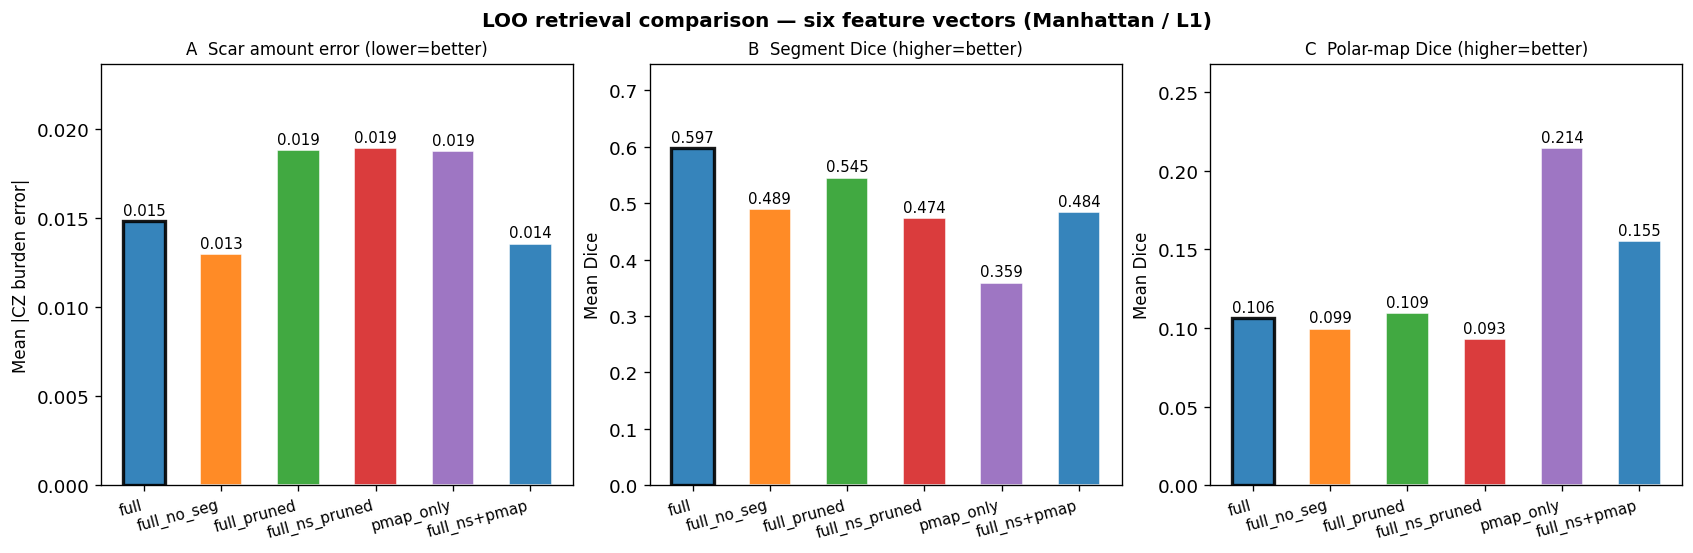

Saved retrieval_vector_stats_4a.{pdf,png,csv}


In [16]:
# ── 4a-stats  LOO quality statistics — five vectors — choose best ───────────
# dice_score / segment_overlap_dice defined here (same logic as §5).

def _dice(map_a, map_b, thr=0.10):
    a = (np.asarray(map_a, float) > thr)
    b = (np.asarray(map_b, float) > thr)
    inters = (a & b).sum()
    denom  = a.sum() + b.sum()
    return 1.0 if denom == 0 else 2.0 * inters / denom

def _seg_dice(sa, sb, thr=0.05):
    a = (np.asarray(sa, float) > thr)
    b = (np.asarray(sb, float) > thr)
    inters = (a & b).sum()
    denom  = a.sum() + b.sum()
    return 1.0 if denom == 0 else 2.0 * inters / denom

_stats4a_rows = []
for vname, Xv, _fn in _COMPARE_VECS_4A:
    _err, _sdice, _pdice = [], [], []
    for tgt_idx in range(len(df)):
        row = df.iloc[tgt_idx]
        if row['total_scar'] == 0 or np.isnan(float(row['total_scar'])):
            continue
        mask = np.ones(len(df), dtype=bool)
        mask[tgt_idx] = False
        base_idx = np.where(mask)[0]
        top_local, _, _ = retrieve(Xv[tgt_idx], Xv[mask], k=1, method='manhattan')
        ret_global = base_idx[top_local[0]]

        tgt_scar = float(row['total_scar'])
        ret_scar = float(df.iloc[ret_global]['total_scar'])
        _err.append(abs(tgt_scar - ret_scar))

        tgt_segs = df.iloc[tgt_idx][SEG_COLS].fillna(0).to_numpy(float)
        ret_segs = df.iloc[ret_global][SEG_COLS].fillna(0).to_numpy(float)
        _sdice.append(_seg_dice(tgt_segs, ret_segs))

        tgt_map_ = pmaps.get(row['key'])
        ret_map_ = pmaps.get(df.iloc[ret_global]['key'])
        _pdice.append(
            _dice(tgt_map_, ret_map_)
            if (tgt_map_ is not None and ret_map_ is not None) else np.nan
        )

    _stats4a_rows.append({
        'vector':       vname,
        'n_feats':      len(_fn),
        'n_patients':   len(_err),
        'scar_err_abs': float(np.mean(_err)),
        'scar_err_med': float(np.median(_err)),
        'seg_dice':     float(np.nanmean(_sdice)),
        'polar_dice':   float(np.nanmean(_pdice)),
    })

stats4a_df = pd.DataFrame(_stats4a_rows)
stats4a_df['score'] = (
    (stats4a_df['seg_dice'] + stats4a_df['polar_dice']) / 2
    - stats4a_df['scar_err_abs']
)
best_vec_name = stats4a_df.loc[stats4a_df['score'].idxmax(), 'vector']

print('LOO retrieval statistics — five vectors:')
display(
    stats4a_df.set_index('vector')[
        ['n_feats', 'scar_err_abs', 'scar_err_med', 'seg_dice', 'polar_dice', 'score']
    ].round(4)
)
print(f'\nBest vector (highest score): {best_vec_name}')

# Bar charts
fig_st4a, axes_st4a = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
fig_st4a.suptitle(
    'LOO retrieval comparison — six feature vectors (Manhattan / L1)',
    fontsize=12, fontweight='bold',
)
_palette5 = ['#2077B4', '#FF7F0E', '#2CA02C', '#D62728', '#9467BD']
_x5 = np.arange(len(_stats4a_rows))
_bw5 = 0.55

for ax, (metric, ylabel, title) in zip(axes_st4a, [
    ('scar_err_abs', 'Mean |CZ burden error|', 'A  Scar amount error (lower=better)'),
    ('seg_dice',     'Mean Dice',              'B  Segment Dice (higher=better)'),
    ('polar_dice',   'Mean Dice',              'C  Polar-map Dice (higher=better)'),
]):
    _vals = [r[metric] for r in _stats4a_rows]
    _bars = ax.bar(_x5, _vals, width=_bw5, color=_palette5, edgecolor='white', alpha=0.9)
    ax.bar_label(_bars, fmt='%.3f', fontsize=9, padding=2)
    ax.set_xticks(_x5)
    ax.set_xticklabels(
        [r['vector'] for r in _stats4a_rows], rotation=15, ha='right', fontsize=9
    )
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(0, max(_vals) * 1.25)
    # Highlight best vector
    _best_i = [r['vector'] for r in _stats4a_rows].index(best_vec_name)
    ax.patches[_best_i].set_edgecolor('black')
    ax.patches[_best_i].set_linewidth(2.0)

fig_st4a.savefig(FIGURES / 'retrieval_vector_stats_4a.pdf', bbox_inches='tight')
fig_st4a.savefig(FIGURES / 'retrieval_vector_stats_4a.png', dpi=150, bbox_inches='tight')
plt.show()
stats4a_df.to_csv(OUT / 'retrieval_vector_stats_4a.csv', index=False)
print('Saved retrieval_vector_stats_4a.{pdf,png,csv}')


In [17]:
# ── Feature difference analysis for all vectors (first demo pair) ────────────
# _tgt_key_3d set by cell 4a (LOO on full case base).
_tgt0_df_idx = df.index.get_loc(df[df['key'] == _tgt_key_3d].index[0])

for _vname, _Xv, _feat_names in _COMPARE_VECS_4A:
    _tgt_vec0 = _Xv[_tgt0_df_idx]
    _m0 = np.ones(len(df), dtype=bool)
    _m0[_tgt0_df_idx] = False
    _top_l, _, _ = retrieve(_tgt_vec0, _Xv[_m0], k=1, method='manhattan')
    _ret_global0 = np.where(_m0)[0][_top_l[0]]
    _ret_key0    = df.iloc[_ret_global0]['key']
    _ret_vec0    = _Xv[_ret_global0]

    _diff_abs = np.abs(_tgt_vec0 - _ret_vec0)
    _feat_diff = pd.DataFrame({'feature': _feat_names, 'abs_diff': _diff_abs})
    _feat_diff = _feat_diff.sort_values('abs_diff', ascending=False).head(10)

    print(f'\n=== {_vname}: top-10 feature differences ===')
    print(f'  Target: {_tgt_key_3d}  →  Retrieved: {_ret_key0}')
    display(_feat_diff.round(4))



=== full: top-10 feature differences ===
  Target: 2021/21042431  →  Retrieved: 2023/14028009


,feature,abs_diff
29,mean_onset_pct,6.7311
21,n_involved,1.0000
30,mean_span_pct,0.2867
31,f1_span_pct,0.2867
26,compact_largest,0.2234
32,f1_size_frac,0.0898
9,seg_10,0.0710
24,circ_extent_apical,0.0703
10,seg_11,0.0357
3,seg_04,0.0341



=== full_no_seg: top-10 feature differences ===
  Target: 2021/21042431  →  Retrieved: 2023/14028009


,feature,abs_diff
12,mean_onset_pct,6.7311
4,n_involved,1.0000
13,mean_span_pct,0.2867
14,f1_span_pct,0.2867
9,compact_largest,0.2234
15,f1_size_frac,0.0898
7,circ_extent_apical,0.0703
10,apex_to_base_spearman,0.0254
5,circ_extent_basal,0.0234
3,LCX,0.0221



=== full_pruned: top-10 feature differences ===
  Target: 2021/21042431  →  Retrieved: 2023/14028009


...

,feature,abs_diff
6,mean_onset_pct,6.7311
7,mean_span_pct,0.2867
8,f1_span_pct,0.2867
4,compact_largest,0.2234
9,f1_size_frac,0.0898
5,apex_to_base_spearman,0.0254
3,circ_extent_basal,0.0234
2,LCX,0.0221
1,RCA,0.0191
0,LAD,0.0000



=== pmap_only: top-10 feature differences ===
  Target: 2021/21042431  →  Retrieved: 2025/50147172


,feature,abs_diff
1,pmap_pc2,0.8744
4,pmap_pc5,0.6328
3,pmap_pc4,0.5453
2,pmap_pc3,0.4145
6,pmap_pc7,0.2286
0,pmap_pc1,0.0398
7,pmap_pc8,0.0237
5,pmap_pc6,0.0163



=== full_ns+pmap: top-10 feature differences ===
  Target: 2021/21042431  →  Retrieved: 2023/14028009


,feature,abs_diff
12,mean_onset_pct,6.7311
23,pmap_pc2,1.9703
25,pmap_pc4,1.3274
4,n_involved,1.0000
26,pmap_pc5,0.6274
28,pmap_pc7,0.5198
27,pmap_pc6,0.4763
13,mean_span_pct,0.2867
14,f1_span_pct,0.2867
9,compact_largest,0.2234


## 5 — Vector usage

Deterministic and probabilistic retrieval with the best-ranked vector from §4a-stats.


In [18]:
# ── Vector selection for §5 ──────────────────────────────────────────────────
# Choose which vector drives deterministic and probabilistic retrieval.
# Set VECTOR_CHOICE to one of the keys below, or None to use the auto-best.
#
#   "full"           – all structured features (39 dims)
#   "full_no_seg"    – no AHA-17 segment burdens (22 dims)
#   "full_pruned"    – full after bottom-Q25 SVD pruning
#   "full_ns_pruned" – full_no_seg after pruning
#   "pmap_only"      – polar-map PCA scores only (8 dims)
#   "full_ns+pmap"   – full_no_seg + pmap PCA (30 dims)
#   None             – use auto-best from §4a-stats

VECTOR_CHOICE = "full"  # <── edit here

_best_vec_map = {v[0]: v for v in _COMPARE_VECS_4A}

if VECTOR_CHOICE is not None:
    if VECTOR_CHOICE not in _best_vec_map:
        raise ValueError(
            f"Unknown vector {VECTOR_CHOICE!r}. "
            f"Valid: {list(_best_vec_map.keys())}"
        )
    _best_vname, X_best, feat_names_best = _best_vec_map[VECTOR_CHOICE]
    print(f'Using manual choice: "{_best_vname}" ({len(feat_names_best)} feats)')
else:
    _best_vname, X_best, feat_names_best = _best_vec_map[best_vec_name]
    print(f'Using auto-best from §4a-stats: "{_best_vname}" ({len(feat_names_best)} feats)')

# Build all-patients version of chosen vector for §6 validation
_BEST_ALL_MAP = {
    "pmap_only": (X_pmap_all, keys_all),
}
X_best_all, keys_best_all = _BEST_ALL_MAP.get(
    _best_vname, (X_best, list(df["key"]))
)
print(f"  §6 pool: {len(keys_best_all)} patients, {X_best_all.shape[1]} dims")


Using manual choice: "full" (39 feats)
  §6 pool: 105 patients, 39 dims


### 4c — Deterministic retrieval with best vector

1-nearest-neighbour retrieval using the best-ranked vector from §4a-stats.  
LOO on the full case base — each target retrieved from the remaining 104 patients.

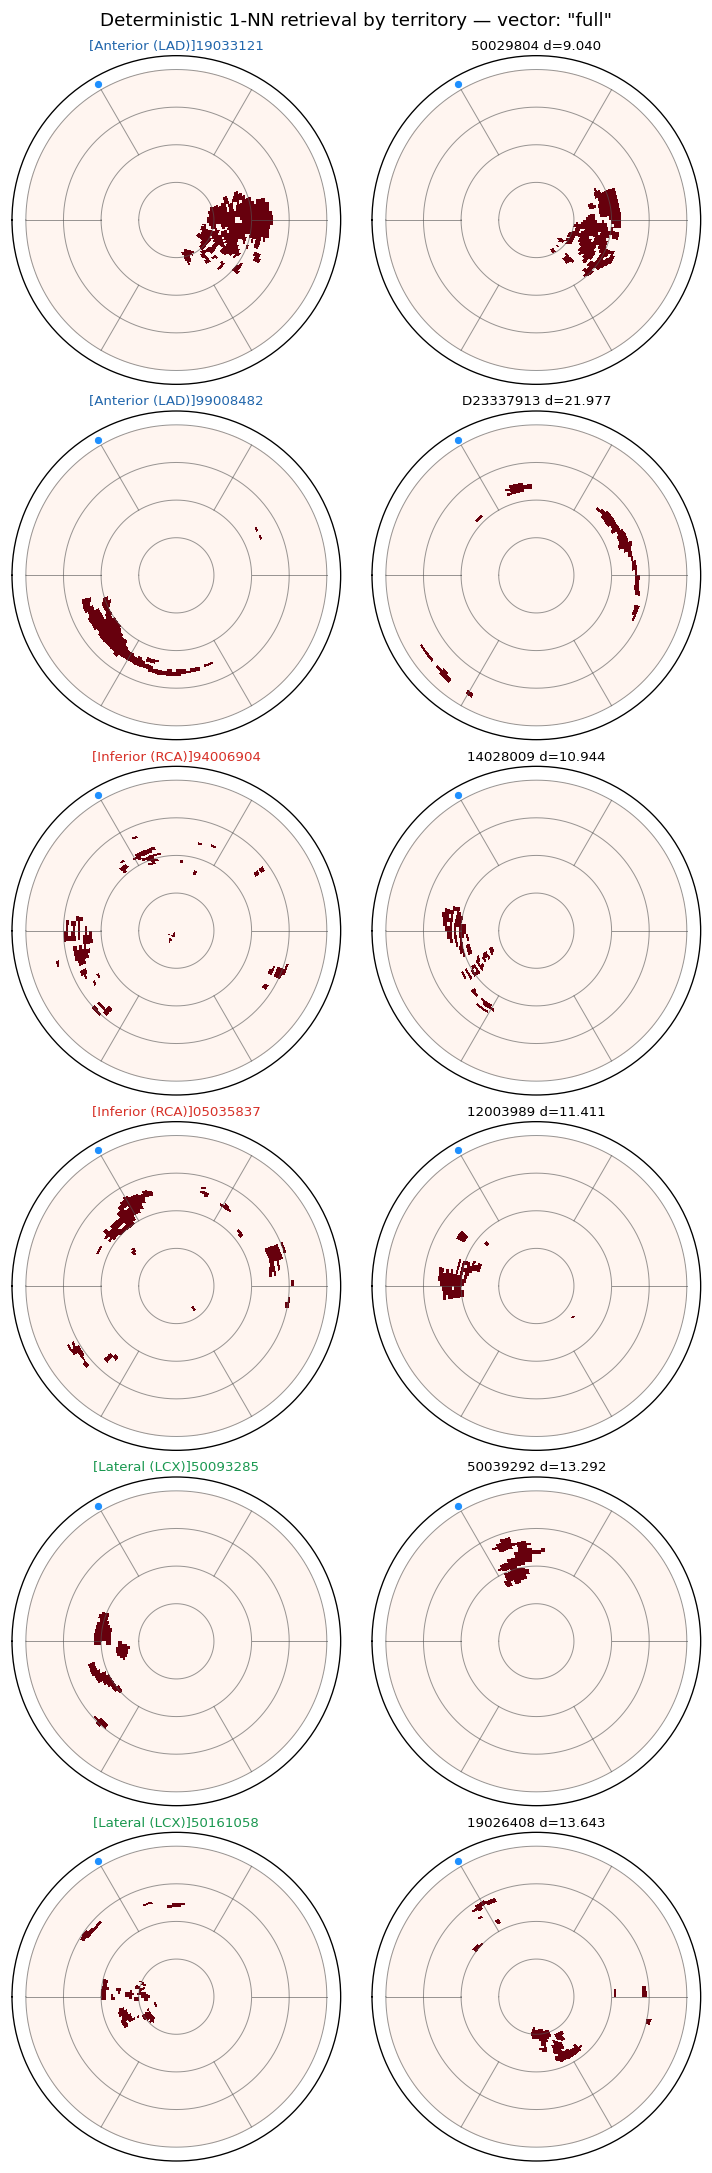

Saved deterministic_retrieval_full.{pdf,png}
Group sizes:
  Anterior (LAD): 13 cases
  Inferior (RCA): 11 cases
  Lateral (LCX): 16 cases


In [19]:
# -- 4c  Deterministic 1-NN retrieval -- grouped by scar territory --------------
# Select ~2 cases per territory type (anterior / inferior / lateral / diffuse)
# to check if retrieval quality differs by scar location.

_N_PER_GROUP = 2   # cases per territory group

# -- Territory classification -------------------------------------------------
# dominant: idxmax of LAD/RCA/LCX -- same logic as M04 terr_raw["dominant"].

_terr_df = df[df["cz_burden"] > 0].copy()
_dominant = _terr_df[["LAD", "RCA", "LCX"]].idxmax(axis=1)

_groups = {
    "Anterior (LAD)": _terr_df.index[(_dominant == "LAD") & (_terr_df["n_involved"] == 1)].tolist(),
    "Inferior (RCA)": _terr_df.index[(_dominant == "RCA") & (_terr_df["n_involved"] == 1)].tolist(),
    "Lateral (LCX)":  _terr_df.index[(_dominant == "LCX") & (_terr_df["n_involved"] == 1)].tolist(),
}

# Sample _N_PER_GROUP from each group (uses shared RNG for reproducibility)
_sel_rows = []   # list of (group_label, global_df_idx)
for _grp_name, _grp_idx in _groups.items():
    if len(_grp_idx) == 0:
        print(f"WARNING: no cases found for {_grp_name}")
        continue
    _n = min(_N_PER_GROUP, len(_grp_idx))
    _sampled = sorted(RNG.choice(_grp_idx, size=_n, replace=False).tolist())
    for _idx in _sampled:
        _sel_rows.append((_grp_name, _idx))

_DET_N = len(_sel_rows)

# -- Build figure -------------------------------------------------------------
fig_det, axes_det = plt.subplots(
    _DET_N, 2,
    figsize=(6.0, _DET_N * 3.0),
    subplot_kw={"projection": "polar"},
    constrained_layout=True,
)
if _DET_N == 1:
    axes_det = axes_det[np.newaxis, :]
fig_det.suptitle(
    f'Deterministic 1-NN retrieval by territory — vector: "{_best_vname}"',
    fontsize=11,
)
axes_det[0, 0].set_title("Target", fontsize=9, fontweight="bold", pad=14)
axes_det[0, 1].set_title("Retrieved (1-NN)", fontsize=9, fontweight="bold", pad=14)

_grp_colors = {
    "Anterior (LAD)": "#2166ac",
    "Inferior (RCA)": "#d73027",
    "Lateral (LCX)":  "#1a9850",
}

for row_i, (_grp_name, tgt_idx) in enumerate(_sel_rows):
    tgt_key   = df.iloc[tgt_idx]["key"]
    mask_d    = np.ones(len(df), dtype=bool)
    mask_d[tgt_idx] = False
    base_idx_d = np.where(mask_d)[0]

    top_local_d, top_dists_d, _ = retrieve(X_best[tgt_idx], X_best[mask_d], k=1, method="manhattan")
    ret_global_d = base_idx_d[top_local_d[0]]
    ret_key_d    = df.iloc[ret_global_d]["key"]
    tgt_map_d    = pmaps.get(tgt_key)
    ret_map_d    = pmaps.get(ret_key_d)
    tgt_pid_d    = tgt_key.split("/")[-1]
    ret_pid_d    = ret_key_d.split("/")[-1]

    _col       = _grp_colors.get(_grp_name, "black")
    _tgt_title = f"[{_grp_name}]{tgt_pid_d}"

    if tgt_map_d is not None:
        draw_bullseye(tgt_map_d, axes_det[row_i, 0], title=_tgt_title, cmap="Reds", vmax=1.0)
        axes_det[row_i, 0].title.set_color(_col)
    else:
        axes_det[row_i, 0].set_title(f"{_tgt_title}(no map)", fontsize=7, color=_col)

    if ret_map_d is not None:
        draw_bullseye(ret_map_d, axes_det[row_i, 1], title=f"{ret_pid_d} d={top_dists_d[0]:.3f}", cmap="Reds", vmax=1.0)
    else:
        axes_det[row_i, 1].set_title(f"{ret_pid_d} d={top_dists_d[0]:.3f} (no map)", fontsize=7)

fig_det.savefig(FIGURES / f"deterministic_retrieval_{_best_vname}.pdf", bbox_inches="tight")
fig_det.savefig(FIGURES / f"deterministic_retrieval_{_best_vname}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved deterministic_retrieval_{_best_vname}.{chr(123)}pdf,png{chr(125)}")

# Group size summary
print("Group sizes:")
for _g, _idx in _groups.items():
    print(f"  {_g}: {len(_idx)} cases")


### 4d — Probabilistic retrieval with best vector

Do not always return the single nearest patient. Retrieve the top-k closest patients, then convert distances into sampling weights via `softmax(−distance / temperature)`.  
Small distance → high probability; larger distance → lower probability.

This is still retrieval-based (only real patients from the case base), but returns different plausible examples for the same target. Lower temperature ≈ nearest neighbour; higher temperature spreads weight across the pool.

Uses the best vector from §4a-stats with LOO on the full case base.


Target: 10008145  --  top-10 pool  (T=1.0, vector="full"):
  # 1  50071002  d=14.103  p=0.846
  # 2  ETN0013J  d=16.957  p=0.049
  # 3  50141399  d=17.100  p=0.042
  # 4  ATC01760  d=17.272  p=0.036
  # 5  05035837  d=18.475  p=0.011
  # 6  50147172  d=18.943  p=0.007
  # 7  50113435  d=19.552  p=0.004
  # 8  12003989  d=19.737  p=0.003
  # 9  12013662  d=20.271  p=0.002
  #10  20045670  d=20.576  p=0.001


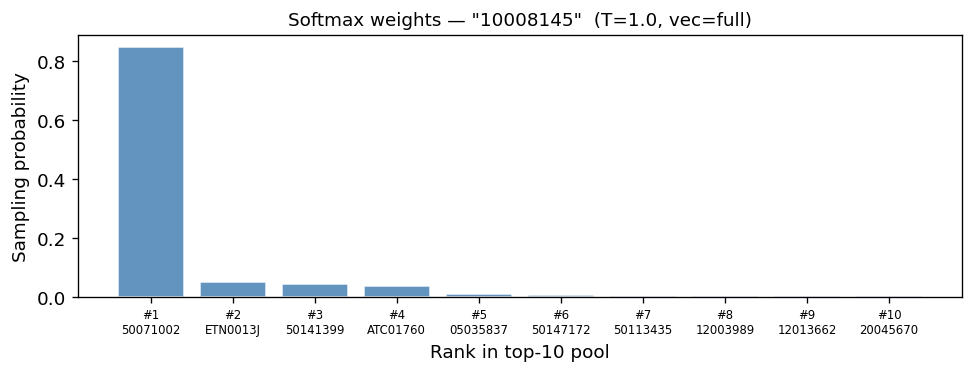

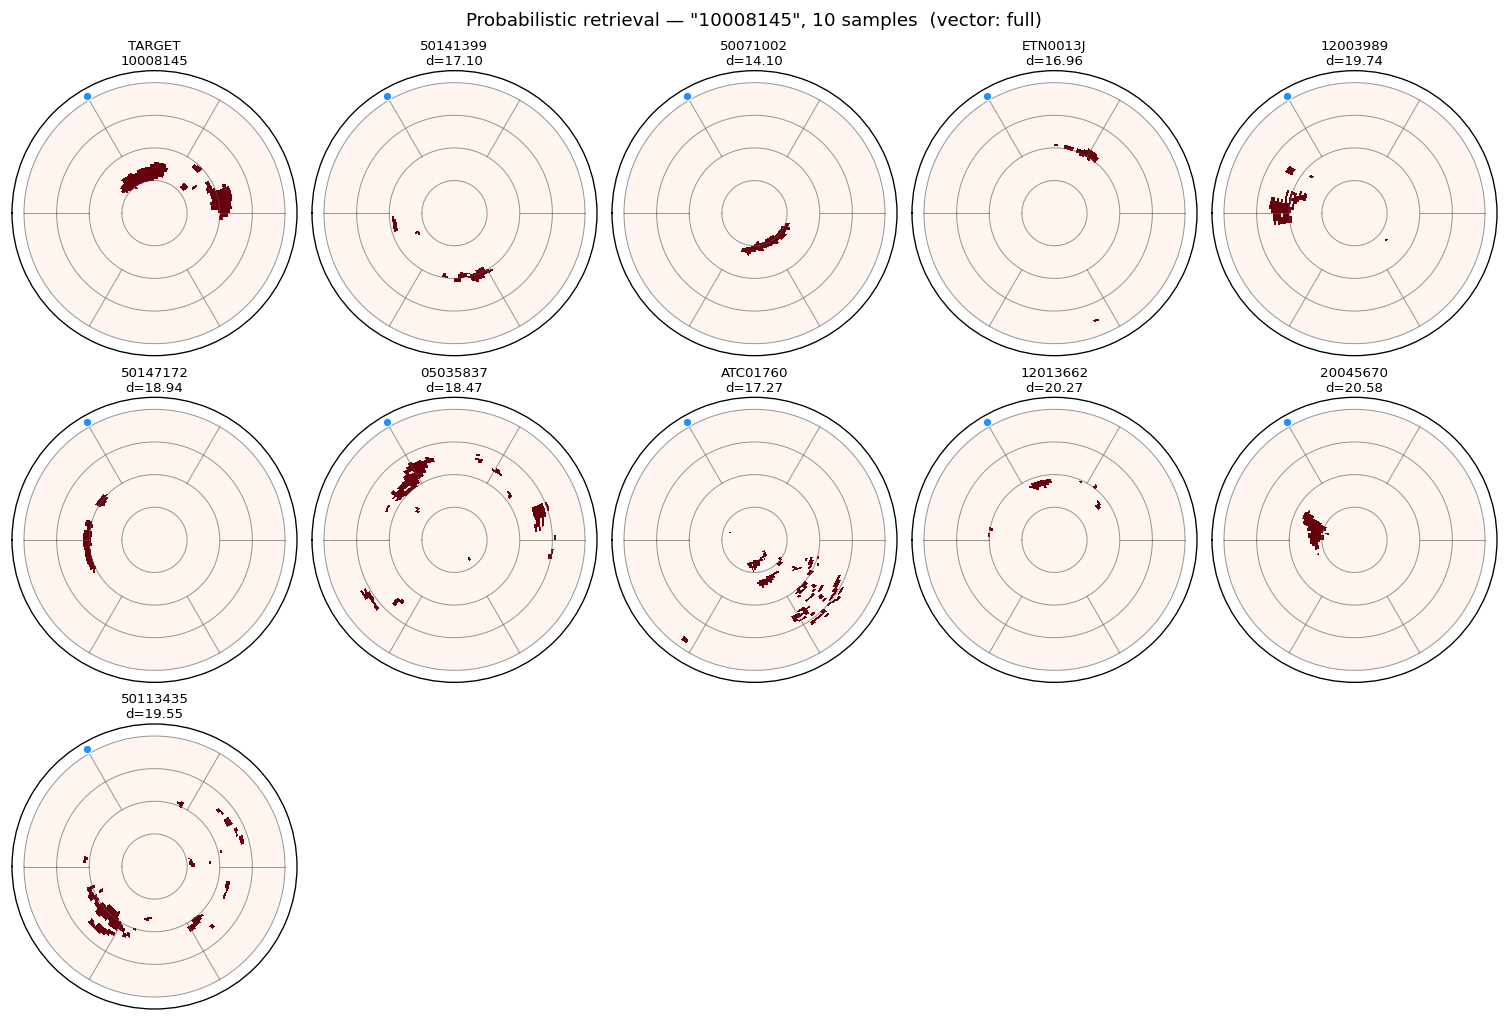

Saved prob_retrieval_4d_samples_10008145.{pdf,png}

Target: 50040366  --  top-10 pool  (T=1.0, vector="full"):
  # 1  20018498  d=21.235  p=0.392
  # 2  11003916  d=21.478  p=0.307
  # 3  07009967  d=22.372  p=0.126
  # 4  50039292  d=22.858  p=0.077
  # 5  96011287  d=23.787  p=0.031
  # 6  50102536  d=23.941  p=0.026
  # 7  20044829  d=24.319  p=0.018
  # 8  50101773  d=24.722  p=0.012
  # 9  14003849  d=25.181  p=0.008
  #10  10039989  d=25.831  p=0.004


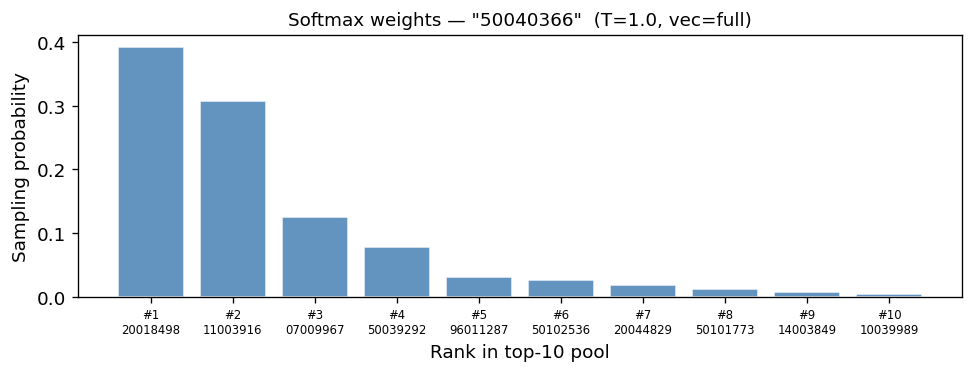

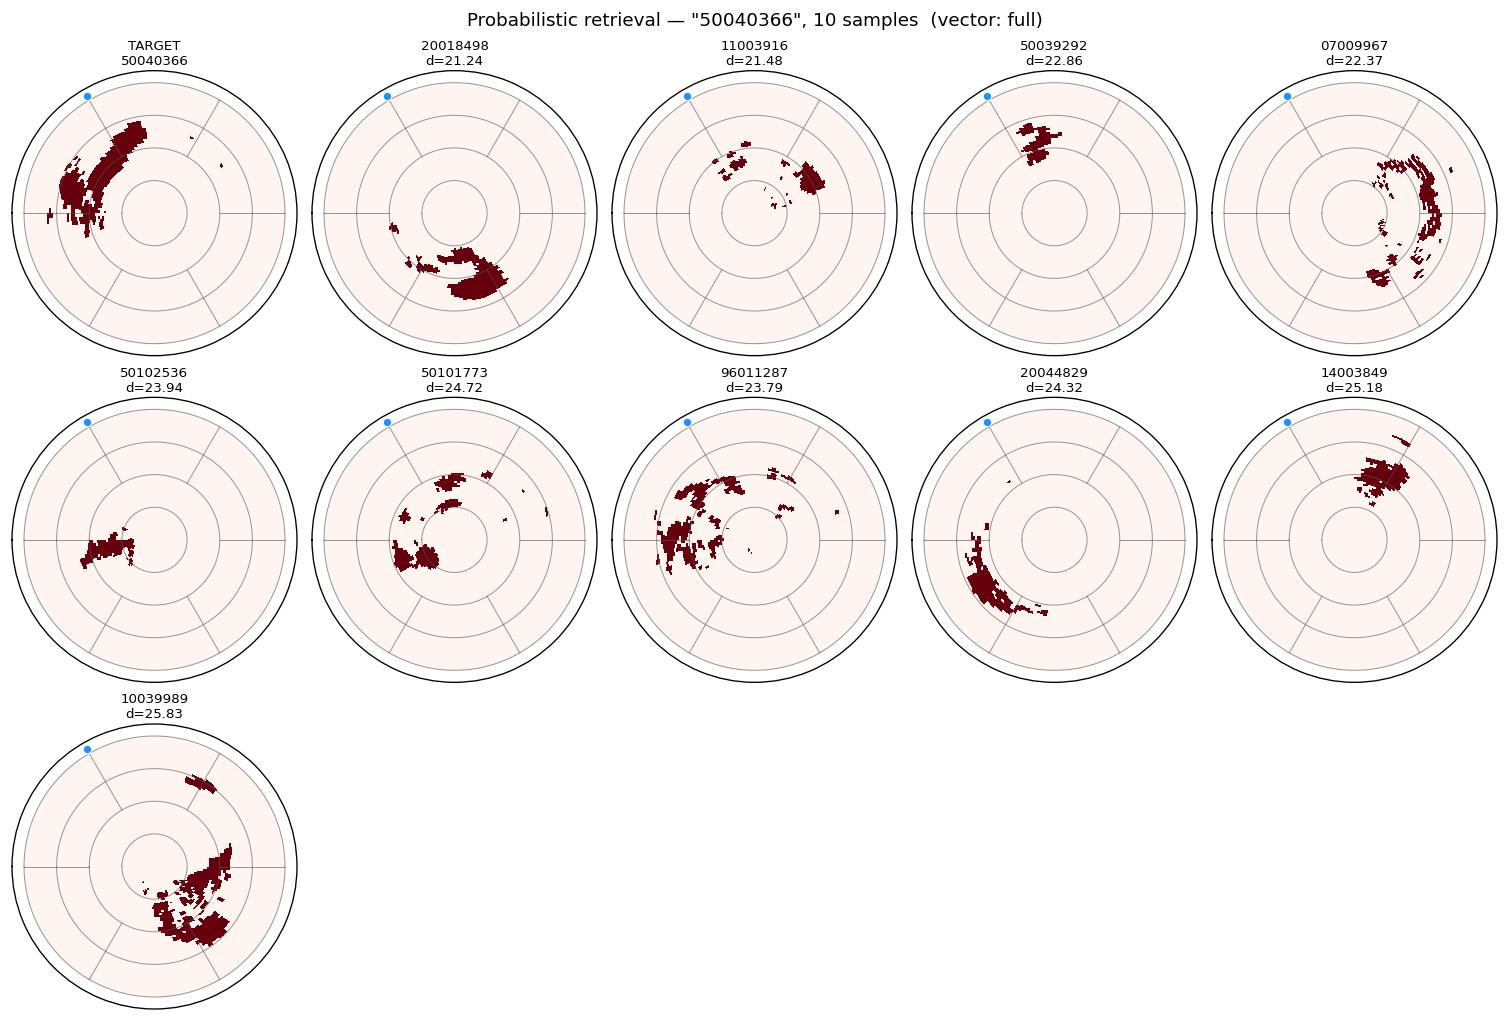

Saved prob_retrieval_4d_samples_50040366.{pdf,png}

Target: 50102536  --  top-10 pool  (T=1.0, vector="full"):
  # 1  50147172  d=12.796  p=0.539
  # 2  14003849  d=13.579  p=0.246
  # 3  50060574  d=14.570  p=0.091
  # 4  22005048  d=15.420  p=0.039
  # 5  50161058  d=15.669  p=0.030
  # 6  19051833  d=16.054  p=0.021
  # 7  12003989  d=16.415  p=0.014
  # 8  15028579  d=16.578  p=0.012
  # 9  50002862  d=17.672  p=0.004
  #10  50141399  d=18.368  p=0.002


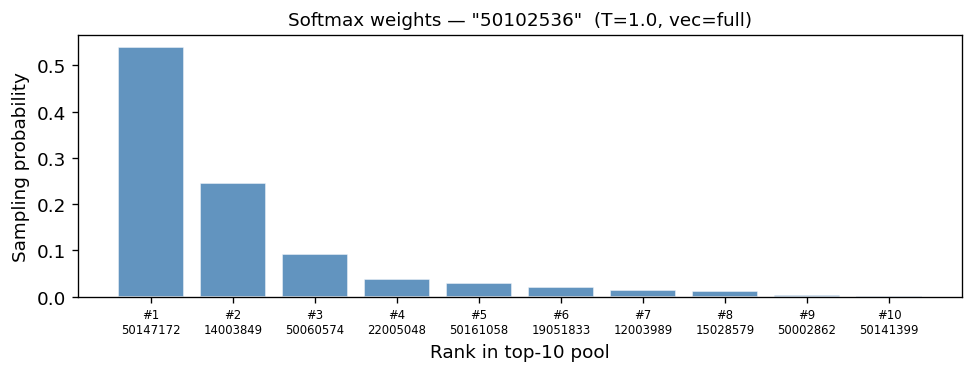

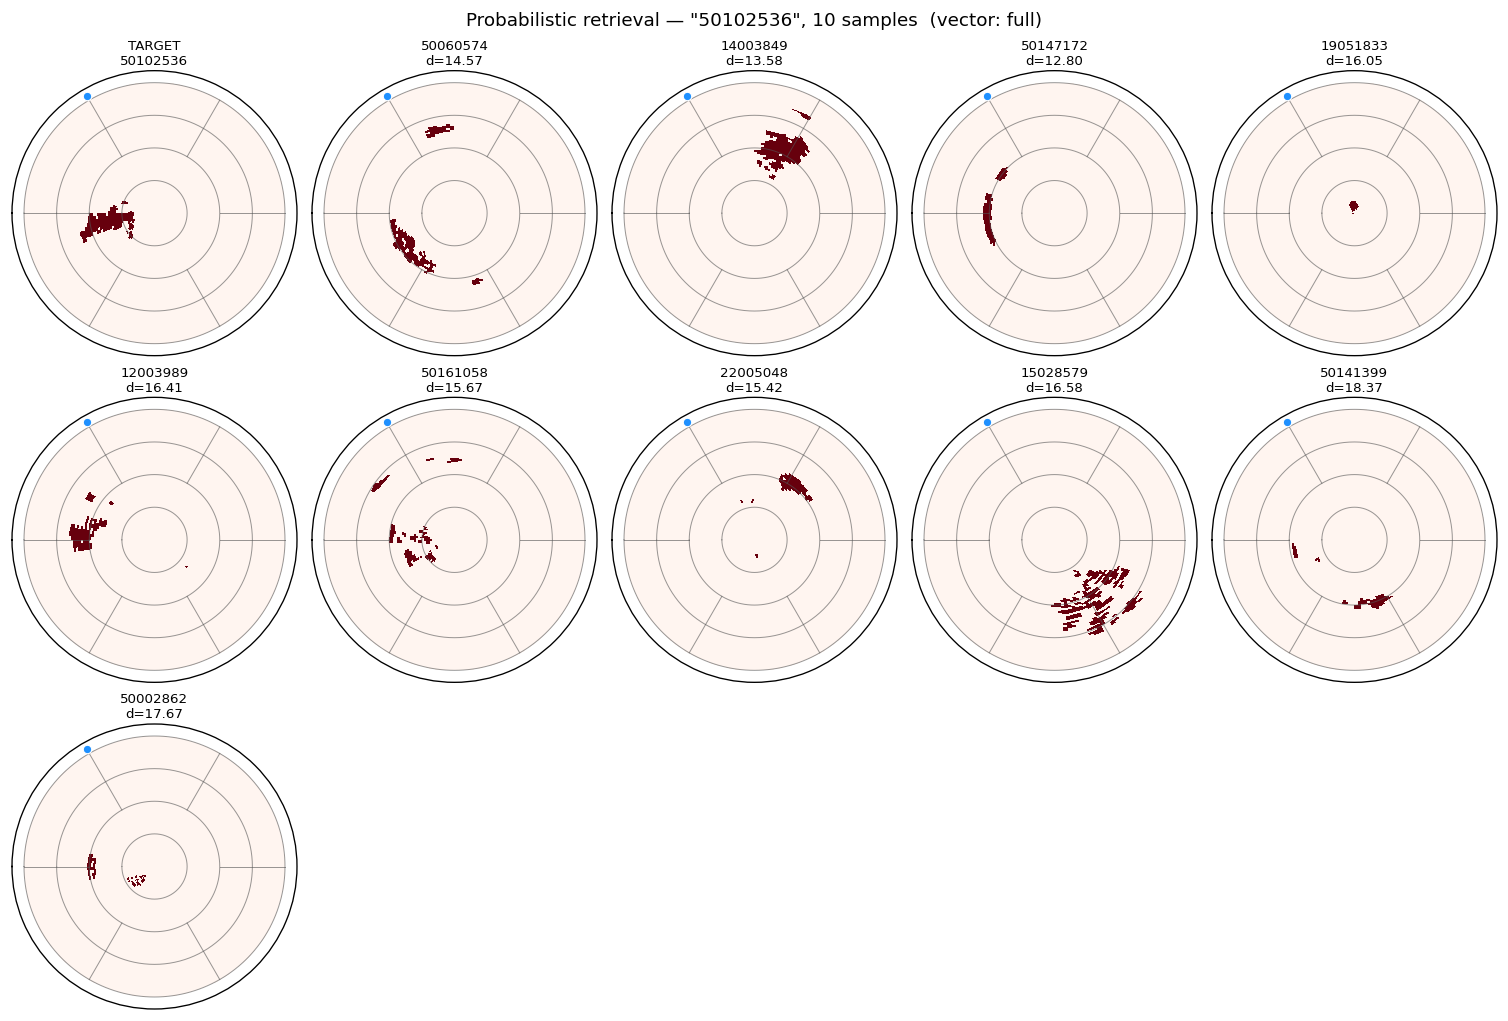

Saved prob_retrieval_4d_samples_50102536.{pdf,png}


In [20]:
_K_PROB           = 10   # candidate pool size
_N_SAMPLES        = 10   # probabilistic draws per target
_PROB_TEMPERATURE = 1.0

# LOO on full case base (best vector requires M04-derived features)
_prob_tgt_indices = sorted(
    RNG.choice(len(df), size=min(3, len(df)), replace=False).tolist()
)

for _prob_tgt_idx in _prob_tgt_indices:
    tgt_key_prob  = df.iloc[_prob_tgt_idx]['key']
    _tgt_label_p  = tgt_key_prob.split('/')[-1]
    mask_p        = np.ones(len(df), dtype=bool)
    mask_p[_prob_tgt_idx] = False
    base_idx_p    = np.where(mask_p)[0]
    feat_vec_prob = X_best[_prob_tgt_idx]
    tgt_map_prob  = pmaps.get(tgt_key_prob)

    top_idx_p, top_dists_p, _ = retrieve(
        feat_vec_prob, X_best[mask_p], method='manhattan', k=_K_PROB
    )
    top_global_p = base_idx_p[top_idx_p]  # local → global df indices

    _logits_p  = -top_dists_p / max(_PROB_TEMPERATURE, 1e-9)
    _logits_p -= np.max(_logits_p)
    probs_p    = np.exp(_logits_p)
    probs_p   /= probs_p.sum()

    sampled_local_p = RNG.choice(len(top_idx_p), size=min(_N_SAMPLES, len(top_idx_p)), replace=False, p=probs_p)
    sampled_idx_p   = top_global_p[sampled_local_p]
    sampled_dists_p = top_dists_p[sampled_local_p]

    print(f'\nTarget: {_tgt_label_p}  --  top-{_K_PROB} pool'
          f'  (T={_PROB_TEMPERATURE}, vector="{_best_vname}"):') 
    for _ri, (_gi, _d_i, _p_i) in enumerate(zip(top_global_p, top_dists_p, probs_p), 1):
        _pid_i = df.iloc[_gi]['key'].split('/')[-1]
        print(f'  #{_ri:2d}  {_pid_i}  d={_d_i:.3f}  p={_p_i:.3f}')

    # Probability bar chart
    fig_probs_p, ax_prob_p = plt.subplots(figsize=(8, 3.0), constrained_layout=True)
    ax_prob_p.bar(range(1, _K_PROB + 1), probs_p, color='steelblue', alpha=0.85, edgecolor='white')
    ax_prob_p.set_xlabel('Rank in top-10 pool', fontsize=11)
    ax_prob_p.set_ylabel('Sampling probability', fontsize=11)
    ax_prob_p.set_title(
        f'Softmax weights — "{_tgt_label_p}"  (T={_PROB_TEMPERATURE}, vec={_best_vname})',
        fontsize=11,
    )
    ax_prob_p.set_xticks(range(1, _K_PROB + 1))
    ax_prob_p.set_xticklabels(
        [f'#{_ii}\n{df.iloc[top_global_p[_ii-1]]["key"].split("/")[-1]}'
         for _ii in range(1, _K_PROB + 1)],
        fontsize=7,
    )
    _fname_pp = f'prob_retrieval_4d_{_tgt_label_p[:20]}'
    fig_probs_p.savefig(FIGURES / f'{_fname_pp}.pdf', bbox_inches='tight')
    fig_probs_p.savefig(FIGURES / f'{_fname_pp}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Sampled retrieval grid
    _ncols_p = 5
    _nrows_p = int(np.ceil((_N_SAMPLES + 1) / _ncols_p))
    fig_samp_p, axes_samp_p = plt.subplots(
        _nrows_p, _ncols_p,
        figsize=(_ncols_p * 2.5, _nrows_p * 2.8),
        subplot_kw={'projection': 'polar'},
        constrained_layout=True,
    )
    fig_samp_p.suptitle(
        f'Probabilistic retrieval — "{_tgt_label_p}", {_N_SAMPLES} samples'
        f'  (vector: {_best_vname})',
        fontsize=11,
    )
    axes_flat_p = axes_samp_p.ravel()
    if tgt_map_prob is not None:
        draw_bullseye(tgt_map_prob, axes_flat_p[0],
                      title=f'TARGET\n{_tgt_label_p}', cmap='Reds', vmax=1.0)
    else:
        axes_flat_p[0].set_title(f'TARGET\n{_tgt_label_p}\n(no map)', fontsize=7)

    for _si_p, (_ri2_p, _di2_p) in enumerate(zip(sampled_idx_p, sampled_dists_p), start=1):
        _rkey_p = df.iloc[_ri2_p]['key']
        _rmap_p = pmaps.get(_rkey_p)
        _rpid_p = _rkey_p.split('/')[-1]
        if _rmap_p is not None:
            draw_bullseye(_rmap_p, axes_flat_p[_si_p],
                          title=f'{_rpid_p}\nd={_di2_p:.2f}', cmap='Reds', vmax=1.0)
        else:
            axes_flat_p[_si_p].set_title(
                f'{_rpid_p}\nd={_di2_p:.2f}\n(no map)', fontsize=7)

    for _ax_p in axes_flat_p[_N_SAMPLES + 1:]:
        _ax_p.set_visible(False)
    _fsamp_p = f'prob_retrieval_4d_samples_{_tgt_label_p[:20]}'
    fig_samp_p.savefig(FIGURES / f'{_fsamp_p}.pdf', bbox_inches='tight')
    fig_samp_p.savefig(FIGURES / f'{_fsamp_p}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {_fsamp_p}.{{pdf,png}}')

### 4a-bis — 3-D LV mesh: target vs retrieved scar

For the first demo pair, paint each LV shell vertex as **scar** (red) or **healthy** (green) by nearest-neighbour distance to the CZ mesh, then render two camera angles (anterior + apical) with PyVista.
Falls back gracefully if the external HD is unavailable.


  OK: 2021/21042431
  OK: 2023/14028009


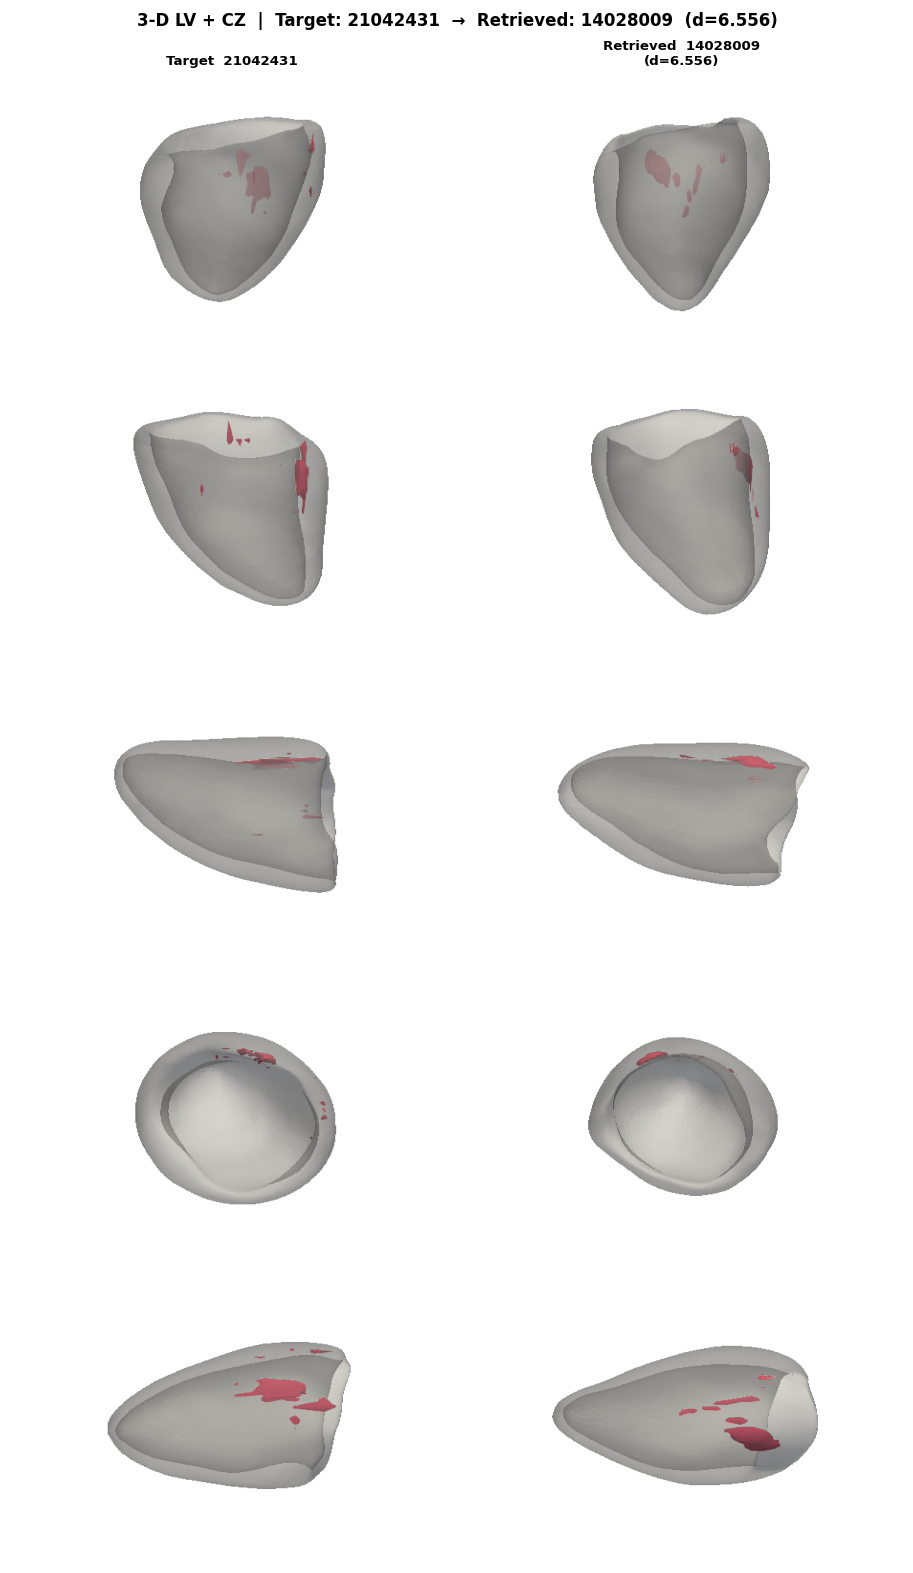

Saved lv_3d_scar_comparison.{pdf,png}


In [21]:
# ── 4a-bis  3-D LV mesh: target vs retrieved scar ──────────────────────────────
import pyvista as pv

pv.set_plot_theme("document")

# Valid PyVista camera shortcut strings: 'xy','xz','yx','yz','zx','zy'
# xz = front/anterior, yz = right lateral, xy = basal top-down,
# zx = oblique-inferior, zy = left lateral
_VIEWS = [
    ("xz",  "Anterior"),
    ("yz",  "Right lateral"),
    ("zy",  "Left lateral"),
    ("xy",  "Basal (top)"),
    ("zx",  "Inferior-oblique"),
]

def _lv_render(case, cam):
    """Render LV shell + CZ mesh. Returns RGBA array or None."""
    try:
        shell = best_shell(case)
        cz    = get_cz_mesh(case)
        if shell is None:
            print(f"    _lv_render: best_shell=None  cam={cam}")
            return None
        pl = pv.Plotter(off_screen=True, window_size=(460, 380))
        pl.add_mesh(shell, color="lightgray", opacity=0.45, show_edges=False)
        if cz is not None and cz.n_points > 0:
            pl.add_mesh(cz, color="crimson", opacity=1.0)
        pl.camera_position = cam
        img = pl.screenshot(return_img=True)
        pl.close()
        return img
    except Exception as exc:
        print(f"    _lv_render FAILED (cam={cam!r}): {exc}")
        return None


# _tgt_key_3d / _ret_key_3d / _d_3d set by cell 4a above.
_ktc     = globals().get("key_to_case", {})
_tgt_pid = _tgt_key_3d.split("/")[-1]
_ret_pid = _ret_key_3d.split("/")[-1]

_cases_3d = [
    (_tgt_key_3d, f"Target  {_tgt_pid}"),
    (_ret_key_3d, f"Retrieved  {_ret_pid}\n(d={_d_3d[0]:.3f})"),
]

for _k3d, _lbl3d in _cases_3d:
    _status = "OK" if _k3d in _ktc else "WARNING: not in key_to_case"
    print(f"  {_status}: {_k3d}")

# Layout: n_views rows x 2 cols (target | retrieved)
_n_views = len(_VIEWS)
fig3d, axes3d = plt.subplots(
    _n_views, 2,
    figsize=(7.5, _n_views * 2.6),
    constrained_layout=True,
)
fig3d.suptitle(
    f"3-D LV + CZ  |  Target: {_tgt_pid}  →  Retrieved: {_ret_pid}  (d={_d_3d[0]:.3f})",
    fontweight="bold", fontsize=10,
)

# Column headers on row 0
for col_i, (_, lbl) in enumerate(_cases_3d):
    axes3d[0, col_i].set_title(lbl, fontsize=8, fontweight="bold", pad=4)

for row_i, (cam, view_lbl) in enumerate(_VIEWS):
    axes3d[row_i, 0].set_ylabel(view_lbl, fontsize=8, labelpad=4)
    for col_i, (key, _) in enumerate(_cases_3d):
        ax = axes3d[row_i, col_i]
        ax.axis("off")
        case = _ktc.get(key)
        if case is None:
            ax.text(0.5, 0.5, f"{view_lbl}\ncase not loaded",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=8, color="red")
            continue
        img = _lv_render(case, cam=cam)
        if img is not None:
            ax.imshow(img, aspect="auto")
        else:
            ax.text(0.5, 0.5, f"{view_lbl}\nrender failed",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=8, color="darkorange")

fig3d.savefig(FIGURES / "lv_3d_scar_comparison.pdf", bbox_inches="tight")
fig3d.savefig(FIGURES / "lv_3d_scar_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved lv_3d_scar_comparison.{pdf,png}")


## 6 — Quantitative validation

### 6a — Retrieval quality statistics

Leave-one-out retrieval on all 105 patients (full cohort) using the selected vector. Results are reported as three separate components:

| Metric | Formula | Range | Direction |
|---|---|---|---|
| **scar\_err\_abs** | \|CZ burden\_target − CZ burden\_retrieved\| | [0, 1] | lower = better |
| **seg\_dice** | 2·\|A∩B\| / (\|A\|+\|B\|), segments with burden > `SEGMENT_PRESENCE_PCT` | [0, 1] | higher = better |
| **polar\_dice** | 2·\|A∩B\| / (\|A\|+\|B\|), polar-map pixels with value > `SCAR_MAP_PRESENCE_PCT` | [0, 1] | higher = better |

`SEGMENT_PRESENCE_PCT = 0.05` means a segment is scar-positive if at least 5 % of its vertices are CZ, regardless of LV size. `SCAR_MAP_PRESENCE_PCT = 0.10` for polar-map binarisation.

In [22]:
SCAR_MAP_PRESENCE_PCT = 0.10
SEGMENT_PRESENCE_PCT  = 0.05


def dice_score(map_a, map_b, threshold_pct=SCAR_MAP_PRESENCE_PCT):
    """Binary Dice between two polar maps using a percent/fraction threshold."""
    a = (np.asarray(map_a, dtype=float) > threshold_pct)
    b = (np.asarray(map_b, dtype=float) > threshold_pct)
    intersection = (a & b).sum()
    denom = a.sum() + b.sum()
    if denom == 0:
        return 1.0
    return 2.0 * intersection / denom


def segment_overlap_dice(seg_tgt, seg_ret, threshold_pct=SEGMENT_PRESENCE_PCT):
    """Dice over AHA-17 segment presence vectors using percent burden per segment."""
    a = (np.asarray(seg_tgt, dtype=float) > threshold_pct)
    b = (np.asarray(seg_ret, dtype=float) > threshold_pct)
    intersection = (a & b).sum()
    denom = a.sum() + b.sum()
    if denom == 0:
        return 1.0
    return 2.0 * intersection / denom


# ── 6a  LOO retrieval — all 105 patients (full cohort) ──────────────────
_eval_mode = f'LOO — {_best_vname} (n={len(keys_best_all)}, method=manhattan)'
loo_rows   = []

for _i, _tgt_key in enumerate(keys_best_all):
    _tgt_vec = X_best_all[_i]
    _tgt_map = pmaps_all.get(_tgt_key)
    if _tgt_map is None:
        continue
    _tgt_scar = scar_burden_all.get(_tgt_key, float(np.mean(_tgt_map)))
    if _tgt_scar == 0:
        continue
    _tgt_segs = _tgt_vec[:17]  # first 17 = AHA-17 seg burdens

    # LOO: exclude self
    _X_base_all  = np.delete(X_best_all, _i, axis=0)
    _base_keys_all = [k for _j, k in enumerate(keys_best_all) if _j != _i]

    _top_l, _top_d, _ = retrieve(_tgt_vec, _X_base_all, k=1, method='manhattan')
    _ret_key  = _base_keys_all[_top_l[0]]
    _ret_map  = pmaps_all.get(_ret_key)
    _ret_scar = scar_burden_all.get(
        _ret_key,
        float(np.mean(_ret_map)) if _ret_map is not None else 0.0
    )
    _ret_idx_all = next(
        (_j for _j, k in enumerate(keys_best_all) if k == _ret_key), None
    )
    _ret_segs = X_best_all[_ret_idx_all][:17] if _ret_idx_all is not None else np.zeros(17)

    _dice_map = dice_score(_tgt_map, _ret_map) if _ret_map is not None else np.nan

    loo_rows.append({
        'tgt_key': _tgt_key, 'ret_key': _ret_key,
        'distance': float(_top_d[0]),
        'scar_err_abs': abs(_tgt_scar - _ret_scar),
        'scar_err_rel': abs(_tgt_scar - _ret_scar) / max(_tgt_scar, 1e-9),
        'seg_dice':    segment_overlap_dice(_tgt_segs, _ret_segs),
        'polar_dice':  _dice_map,
        'tgt_scar': _tgt_scar, 'ret_scar': _ret_scar,
    })

loo_df = pd.DataFrame(loo_rows)
print(f'Evaluation mode: {_eval_mode}')
print(f'Patients evaluated: {len(loo_df)}')
print(f'Segment presence threshold: {SEGMENT_PRESENCE_PCT:.0%}')
print(f'Polar-map presence threshold: {SCAR_MAP_PRESENCE_PCT:.0%}')
print()
print('Summary statistics:')
display(loo_df[['scar_err_abs', 'scar_err_rel', 'seg_dice', 'polar_dice', 'distance']].describe().round(4))

loo_df.to_csv(OUT / 'loo_retrieval_results.csv', index=False)
print('Saved loo_retrieval_results.csv')


Evaluation mode: LOO — full (n=105, method=manhattan)
Patients evaluated: 105
Segment presence threshold: 5%
Polar-map presence threshold: 10%

Summary statistics:


,scar_err_abs,scar_err_rel,seg_dice,polar_dice,distance
count,105.0000,105.0000,105.0000,105.0000,105.0000
mean,0.0148,0.3360,0.5974,0.1061,16.2059
std,0.0185,0.3206,0.3138,0.1453,8.1675
min,0.0000,0.0000,0.0000,0.0000,3.7008
25%,0.0020,0.0772,0.5000,0.0000,11.2917
50%,0.0093,0.2766,0.6667,0.0316,14.3858
75%,0.0211,0.4875,0.8000,0.1890,20.5231
max,0.1057,1.9020,1.0000,0.5288,56.1271


Saved loo_retrieval_results.csv


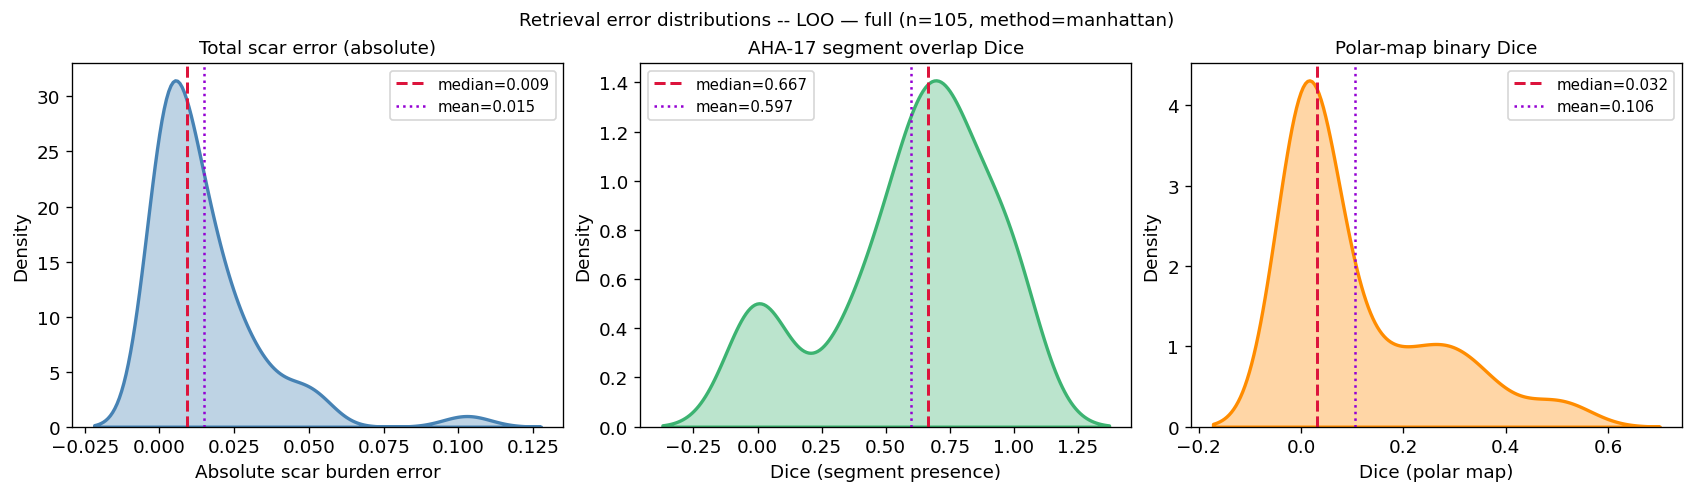

Saved loo_error_distributions.{pdf,png}


In [23]:
# -- Error density plots (5a) -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
fig.suptitle(f'Retrieval error distributions -- {_eval_mode}', fontsize=11)

_metrics = [
    (loo_df['scar_err_abs'],        'Absolute scar burden error', 'steelblue',     'Total scar error (absolute)'),
    (loo_df['seg_dice'].dropna(),   'Dice (segment presence)',    'mediumseagreen', 'AHA-17 segment overlap Dice'),
    (loo_df['polar_dice'].dropna(), 'Dice (polar map)',           'darkorange',     'Polar-map binary Dice'),
]

for ax, (data, xlabel, color, title) in zip(axes, _metrics):
    sns.kdeplot(data, ax=ax, color=color, fill=True, alpha=0.35, linewidth=2.0)
    _med = float(data.median())
    _mn  = float(data.mean())
    ax.axvline(_med, color='crimson',    lw=1.8, ls='--', label=f'median={_med:.3f}')
    ax.axvline(_mn,  color='darkviolet', lw=1.5, ls=':',  label=f'mean={_mn:.3f}')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.savefig(FIGURES / 'loo_error_distributions.pdf', bbox_inches='tight')
plt.savefig(FIGURES / 'loo_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved loo_error_distributions.{pdf,png}')

### 6b — Per-method comparison

Run leave-one-out with all four distance metrics and compare retrieval quality.

In [24]:
method_rows = []

for method in METHODS:
    err_abs_list, seg_dice_list, polar_dice_list = [], [], []

    for tgt_idx in range(len(df)):
        _tgt_scar_check = df.iloc[tgt_idx]['total_scar']
        if _tgt_scar_check == 0 or np.isnan(_tgt_scar_check):
            continue
        # Skip patients without a polar map (same filter as §6a)
        if pmaps.get(df.iloc[tgt_idx]['key']) is None:
            continue

        mask_base = np.ones(len(df), dtype=bool)
        mask_base[tgt_idx] = False
        X_base_m = X_best[mask_base]
        base_idx_m = np.where(mask_base)[0]

        top_local_m, _, _ = retrieve(X_best[tgt_idx], X_base_m, method=method, k=1)
        ret_global_m = base_idx_m[top_local_m[0]]

        tgt_scar_m = float(df.iloc[tgt_idx]['total_scar'])
        ret_scar_m = float(df.iloc[ret_global_m]['total_scar'])
        err_abs_list.append(abs(tgt_scar_m - ret_scar_m))

        tgt_segs_m = df.iloc[tgt_idx][SEG_COLS].fillna(0).to_numpy(dtype=float)
        ret_segs_m = df.iloc[ret_global_m][SEG_COLS].fillna(0).to_numpy(dtype=float)
        seg_dice_list.append(segment_overlap_dice(tgt_segs_m, ret_segs_m))

        tgt_map_m = pmaps.get(df.iloc[tgt_idx]['key'])
        ret_map_m = pmaps.get(df.iloc[ret_global_m]['key'])
        if tgt_map_m is not None and ret_map_m is not None:
            polar_dice_list.append(dice_score(tgt_map_m, ret_map_m))

    method_rows.append({
        'method':         method,
        'mean_scar_err':  float(np.mean(err_abs_list)),
        'median_scar_err':float(np.median(err_abs_list)),
        'mean_seg_dice':  float(np.mean(seg_dice_list)),
        'mean_polar_dice':float(np.mean(polar_dice_list)) if polar_dice_list else np.nan,
    })
    print(f"  {method}: scar_err={np.mean(err_abs_list):.4f}  seg_dice={np.mean(seg_dice_list):.3f}")

method_df = pd.DataFrame(method_rows)
print()
display(method_df.round(4))
method_df.to_csv(OUT / 'method_comparison.csv', index=False)
print('Saved method_comparison.csv')

  weighted_euclidean: scar_err=0.0164  seg_dice=0.539
  euclidean: scar_err=0.0164  seg_dice=0.539
  manhattan: scar_err=0.0148  seg_dice=0.597
  cosine: scar_err=0.0436  seg_dice=0.282



,method,mean_scar_err,median_scar_err,mean_seg_dice,mean_polar_dice
0,weighted_euclidean,0.0164,0.0103,0.5385,0.0954
1,euclidean,0.0164,0.0103,0.5385,0.0954
2,manhattan,0.0148,0.0093,0.5974,0.1061
3,cosine,0.0436,0.0227,0.2817,0.0417


Saved method_comparison.csv


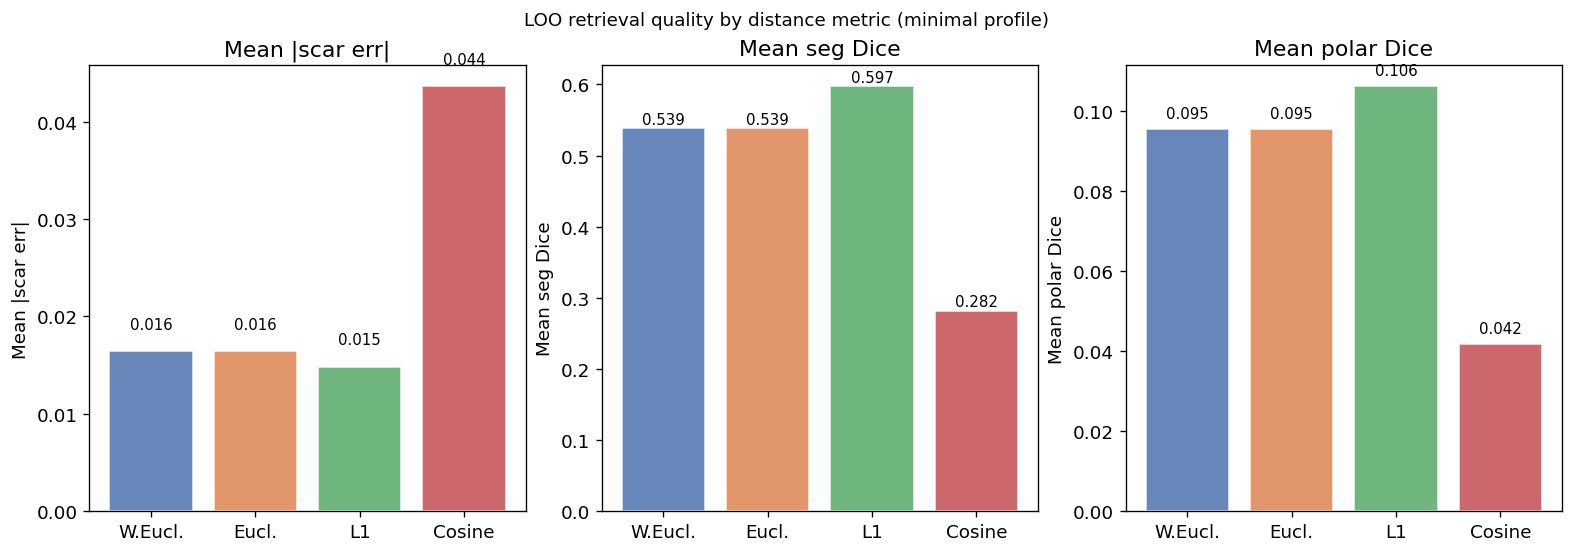

Saved method_comparison_bars.{pdf,png}


In [25]:
# ── Method comparison bar chart ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), constrained_layout=True)
fig.suptitle('LOO retrieval quality by distance metric (minimal profile)', fontsize=11)

_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
_methods_short = ['W.Eucl.', 'Eucl.', 'L1', 'Cosine']

for ax, metric, ylabel in zip(
    axes,
    ['mean_scar_err', 'mean_seg_dice', 'mean_polar_dice'],
    ['Mean |scar err|', 'Mean seg Dice', 'Mean polar Dice'],
):
    vals = method_df[metric].to_numpy()
    bars = ax.bar(_methods_short, vals, color=_colors, alpha=0.85, edgecolor='white')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    for bar, v in zip(bars, vals):
        if np.isfinite(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.002,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.savefig(FIGURES / 'method_comparison_bars.pdf', bbox_inches='tight')
plt.savefig(FIGURES / 'method_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved method_comparison_bars.{pdf,png}')

### 6b-bis — Probabilistic vs deterministic retrieval

Compare 1-nearest-neighbour (deterministic) against probabilistic sampling from the top-*k* pool, using Manhattan (L1) distance and the selected feature vector (consistent with §6a).
Primary: full-cohort patients; fallback: leave-one-out on known.

Probabilistic vs deterministic (full LOO n=105, method=manhattan):


,method,scar_err_abs,seg_dice,polar_dice
0,deterministic 1-NN,0.0148,0.5974,0.1061
1,probabilistic top-10 T=1.0,0.0163,0.5395,0.1115


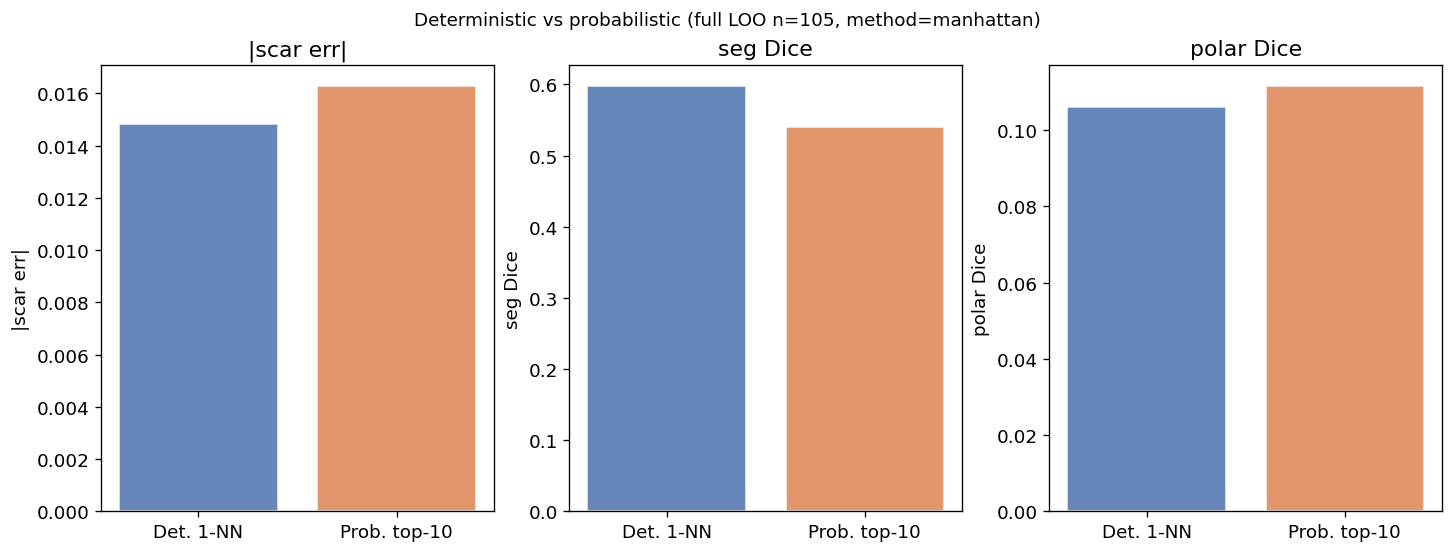

Saved det_vs_prob_retrieval.{pdf,png}


In [26]:
# -- 6b-bis  Probabilistic vs deterministic retrieval -------------------------
_K_PROB_5B = 10
_TEMP_5B   = 1.0

det_rows_5b, prob_rows_5b = [], []

for _i5b, _tgt_key5b in enumerate(keys_best_all):
    _tgt_vec5b = X_best_all[_i5b]
    _tgt_map5b = pmaps_all.get(_tgt_key5b)
    if _tgt_map5b is None:
        continue
    _tgt_scar5b = scar_burden_all.get(_tgt_key5b, float(np.mean(_tgt_map5b)))
    if _tgt_scar5b == 0:
        continue
    _n_feat5b   = min(17, X_best_all.shape[1])
    _tgt_segs5b = X_best_all[_i5b][:_n_feat5b]

    # LOO: exclude self
    _X_base5b    = np.delete(X_best_all, _i5b, axis=0)
    _base_keys5b = [k for _j, k in enumerate(keys_best_all) if _j != _i5b]

    # Deterministic 1-NN
    _top_d5b, _dist_d5b, _ = retrieve(_tgt_vec5b, _X_base5b, k=1, method='manhattan')
    _ret_key_d  = _base_keys5b[_top_d5b[0]]
    _ret_map_d  = pmaps_all.get(_ret_key_d)
    _ret_scar_d = scar_burden_all.get(_ret_key_d, 0.0)
    _ret_idx_d  = keys_best_all.index(_ret_key_d)
    _ret_segs_d = X_best_all[_ret_idx_d][:_n_feat5b]
    det_rows_5b.append({
        "scar_err_abs": abs(_tgt_scar5b - _ret_scar_d),
        "seg_dice":     segment_overlap_dice(_tgt_segs5b, _ret_segs_d),
        "polar_dice":   dice_score(_tgt_map5b, _ret_map_d) if _ret_map_d is not None else np.nan,
    })

    # Probabilistic top-k (no duplicate draws)
    _k5b = min(_K_PROB_5B, len(_base_keys5b))
    _top_p5b, _dists_p5b, _ = retrieve(_tgt_vec5b, _X_base5b, k=_k5b, method='manhattan')
    _lp5b = -_dists_p5b / max(_TEMP_5B, 1e-9)
    _lp5b -= _lp5b.max()
    _w5b   = np.exp(_lp5b); _w5b /= _w5b.sum()
    _si5b  = RNG.choice(_k5b, size=1, replace=False, p=_w5b)
    _ret_key_p  = _base_keys5b[_top_p5b[_si5b[0]]]
    _ret_map_p  = pmaps_all.get(_ret_key_p)
    _ret_scar_p = scar_burden_all.get(_ret_key_p, 0.0)
    _ret_idx_p  = keys_best_all.index(_ret_key_p)
    _ret_segs_p = X_best_all[_ret_idx_p][:_n_feat5b]
    prob_rows_5b.append({
        "scar_err_abs": abs(_tgt_scar5b - _ret_scar_p),
        "seg_dice":     segment_overlap_dice(_tgt_segs5b, _ret_segs_p),
        "polar_dice":   dice_score(_tgt_map5b, _ret_map_p) if _ret_map_p is not None else np.nan,
    })

_mode_5b = f"{_best_vname} LOO n={len(keys_best_all)}, method=manhattan"
det_5b   = pd.DataFrame(det_rows_5b)
prob_5b  = pd.DataFrame(prob_rows_5b)
comp_5b  = pd.DataFrame([
    {"method": "deterministic 1-NN",
     **{k: det_5b[k].mean()  for k in ["scar_err_abs", "seg_dice", "polar_dice"]}},
    {"method": f"probabilistic top-{_K_PROB_5B} T={_TEMP_5B}",
     **{k: prob_5b[k].mean() for k in ["scar_err_abs", "seg_dice", "polar_dice"]}},
])
print(f"Probabilistic vs deterministic ({_mode_5b}):")
display(comp_5b.round(4))

fig_5b2, axes_5b2 = plt.subplots(1, 3, figsize=(12, 4.5), constrained_layout=True)
fig_5b2.suptitle(f"Deterministic vs probabilistic ({_mode_5b})", fontsize=11)
_c2 = ["#4C72B0", "#DD8452"]
_m2 = ["Det. 1-NN", f"Prob. top-{_K_PROB_5B}"]
for ax, metric, ylabel in zip(
    axes_5b2,
    ["scar_err_abs", "seg_dice", "polar_dice"],
    ["|scar err|", "seg Dice", "polar Dice"],
):
    vals = [det_5b[metric].mean(), prob_5b[metric].mean()]
    ax.bar(_m2, vals, color=_c2, alpha=0.85, edgecolor="white")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
fig_5b2.savefig(FIGURES / "det_vs_prob_retrieval.pdf", bbox_inches="tight")
fig_5b2.savefig(FIGURES / "det_vs_prob_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved det_vs_prob_retrieval.{pdf,png}")


## 7 — Publication figures for TFG report

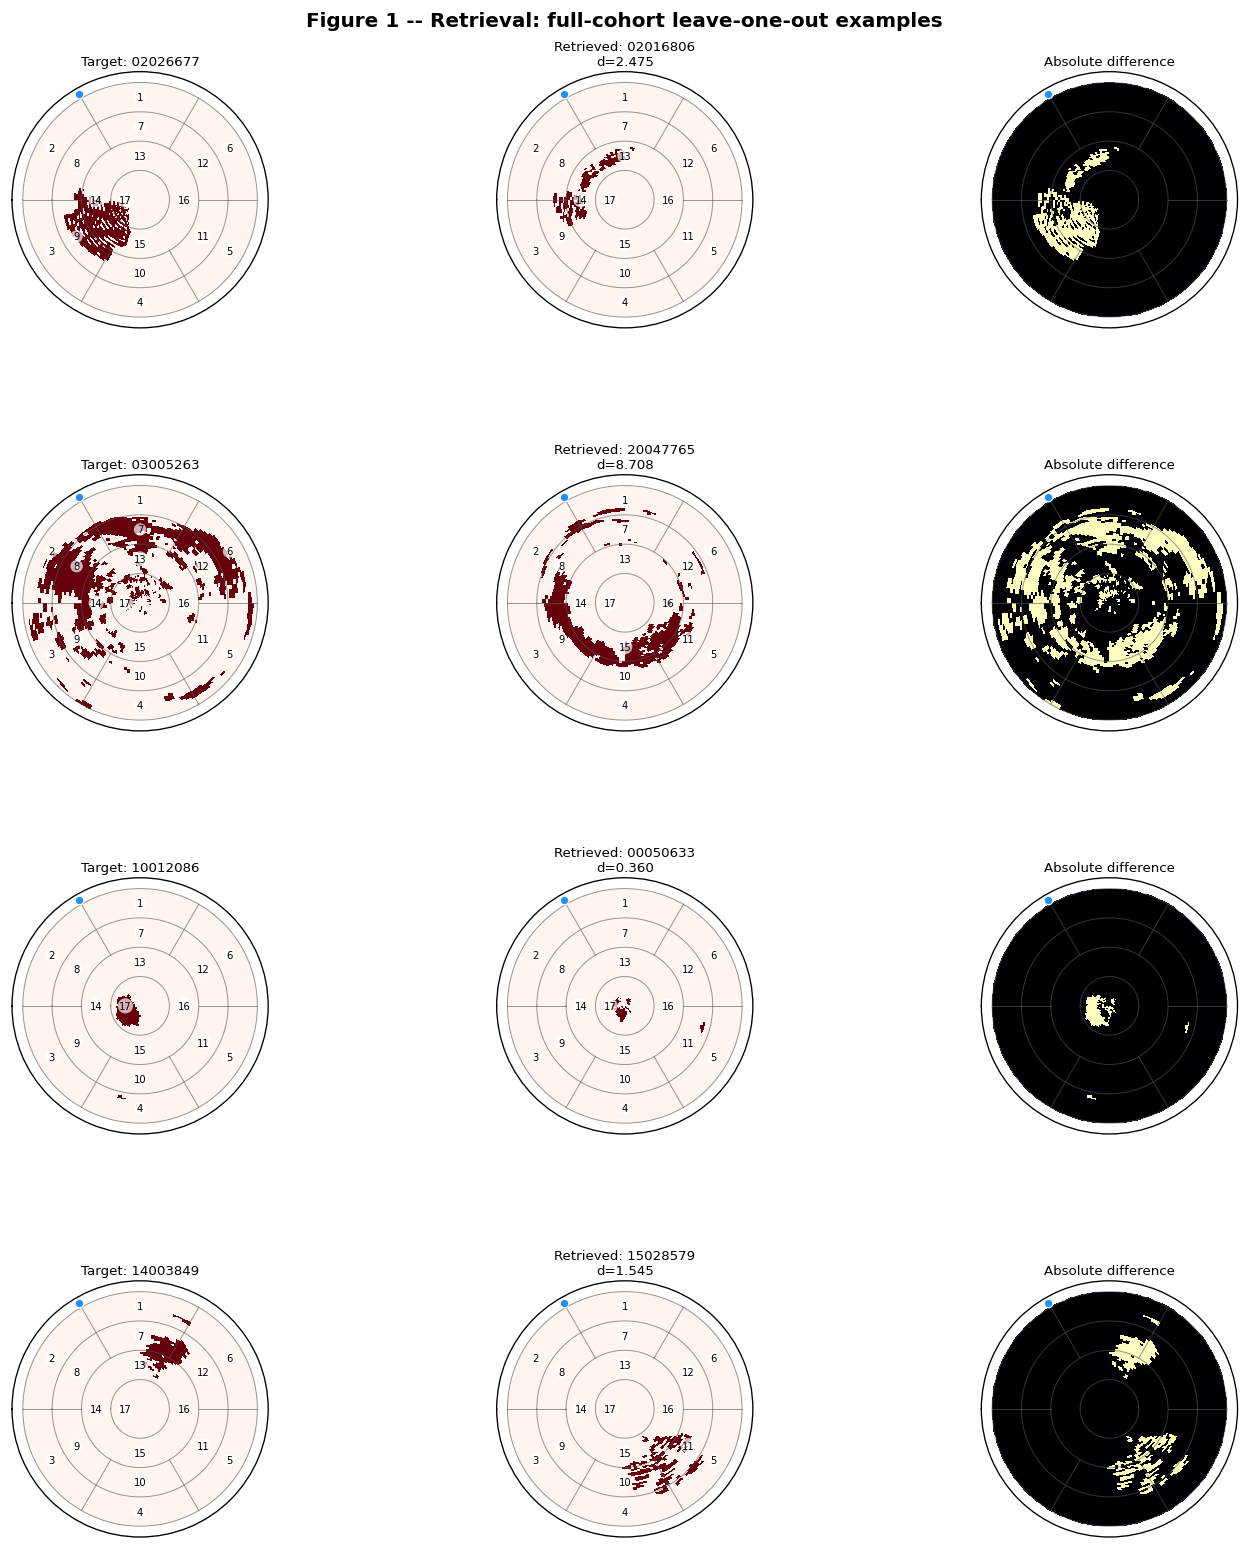

Saved figure1_generated_examples.{pdf,png}


In [27]:
# -- Figure 1: Generated examples (3-4 rows) ----------------------------------
# Leave-one-out examples from the full cohort.

if len(df):
    _FIG1_KEYS       = df['key'].tolist()[:min(4, len(df))]
    _fig1_use_held   = True
    _fig1_title      = 'Figure 1 -- Retrieval: full-cohort leave-one-out examples'
else:
    _FIG1_KEYS       = list(SYNTHETIC_TARGETS.keys())[:4]
    _fig1_use_held   = False
    _fig1_title      = 'Figure 1 -- Retrieval-based scar examples (synthetic targets)'

_FIG1_N = len(_FIG1_KEYS)
fig1 = plt.figure(figsize=(12, _FIG1_N * 3.2), constrained_layout=True)
fig1.suptitle(_fig1_title, fontsize=12, fontweight='bold')
outer_gs = gridspec.GridSpec(_FIG1_N, 3, figure=fig1, wspace=0.05, hspace=0.3)

for row_i, key_or_name in enumerate(_FIG1_KEYS):
    if _fig1_use_held:
        _hi        = df.index[df['key'] == key_or_name][0]
        tgt_map    = pmaps.get(key_or_name)
        feat_vec   = X_min[_hi]
        _row_label = key_or_name.split('/')[-1]
        _base_mask = np.ones(len(df), dtype=bool)
        _base_mask[_hi] = False
        _base_X = X_min[_base_mask]
        _base_df = df[_base_mask].reset_index(drop=True)
    else:
        seg17      = SYNTHETIC_TARGETS[key_or_name]
        tgt_map    = approx_polar_from_segs(seg17)
        feat_vec   = synth_features[key_or_name]
        _row_label = key_or_name.replace('_', ' ')
        _base_X = X_min
        _base_df = df

    top_idx_f1, top_dists_f1, _ = retrieve(feat_vec, _base_X, k=1)
    ret_key_f1 = _base_df.iloc[top_idx_f1[0]]['key']
    ret_map_f1 = pmaps.get(ret_key_f1)
    pid_f1     = ret_key_f1.split('/')[-1]
    d_f1       = top_dists_f1[0]

    # Column 0: target
    ax0 = fig1.add_subplot(outer_gs[row_i, 0], projection='polar')
    if tgt_map is not None:
        draw_bullseye(tgt_map, ax0,
                      title=f'Target: {_row_label}',
                      cmap='Reds', vmax=1.0, label_segs=True)
    else:
        ax0.set_title(f'{_row_label}\n(no map)', fontsize=7)

    # Column 1: retrieved
    ax1 = fig1.add_subplot(outer_gs[row_i, 1], projection='polar')
    if ret_map_f1 is not None:
        draw_bullseye(ret_map_f1, ax1,
                      title=f'Retrieved: {pid_f1}\nd={d_f1:.3f}',
                      cmap='Reds', vmax=1.0, label_segs=True)
    else:
        ax1.set_title(f'{pid_f1}\n(no map)', fontsize=7)

    # Column 2: absolute difference
    ax2 = fig1.add_subplot(outer_gs[row_i, 2], projection='polar')
    if tgt_map is not None and ret_map_f1 is not None:
        draw_bullseye(np.abs(tgt_map - ret_map_f1), ax2,
                      title='Absolute difference', cmap='magma', vmax=1.0,
                      label_segs=False)
    else:
        ax2.set_title('Difference unavailable', fontsize=7)

plt.savefig(FIGURES / 'figure1_generated_examples.pdf', bbox_inches='tight')
plt.savefig(FIGURES / 'figure1_generated_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure1_generated_examples.{pdf,png}')

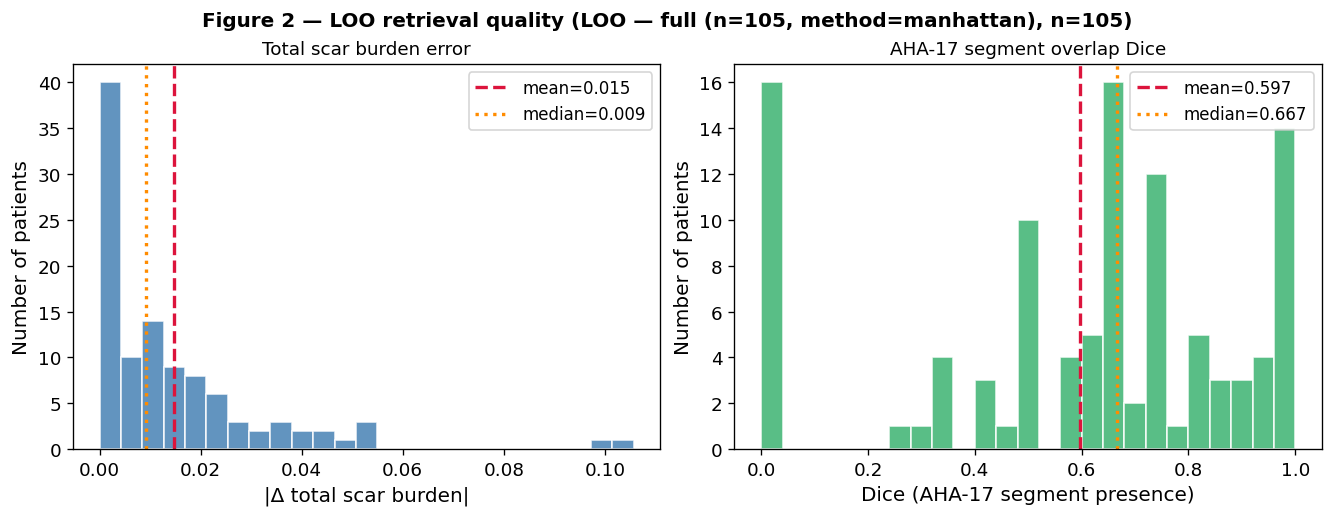

Saved figure2_retrieval_quality.{pdf,png}


In [28]:
# ── Figure 2: Retrieval quality histogram ─────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
fig2.suptitle(f'Figure 2 — LOO retrieval quality ({_eval_mode}, n={len(loo_df)})',
              fontsize=12, fontweight='bold')

axes2[0].hist(loo_df['scar_err_abs'], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes2[0].axvline(loo_df['scar_err_abs'].mean(),   color='crimson',    lw=2.0, ls='--', label=f"mean={loo_df['scar_err_abs'].mean():.3f}")
axes2[0].axvline(loo_df['scar_err_abs'].median(), color='darkorange', lw=2.0, ls=':',  label=f"median={loo_df['scar_err_abs'].median():.3f}")
axes2[0].set_xlabel('|Δ total scar burden|', fontsize=12)
axes2[0].set_ylabel('Number of patients', fontsize=12)
axes2[0].set_title('Total scar burden error', fontsize=11)
axes2[0].legend(fontsize=10)

axes2[1].hist(loo_df['seg_dice'].dropna(), bins=25, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes2[1].axvline(loo_df['seg_dice'].mean(),   color='crimson',    lw=2.0, ls='--', label=f"mean={loo_df['seg_dice'].mean():.3f}")
axes2[1].axvline(loo_df['seg_dice'].median(), color='darkorange', lw=2.0, ls=':',  label=f"median={loo_df['seg_dice'].median():.3f}")
axes2[1].set_xlabel('Dice (AHA-17 segment presence)', fontsize=12)
axes2[1].set_ylabel('Number of patients', fontsize=12)
axes2[1].set_title('AHA-17 segment overlap Dice', fontsize=11)
axes2[1].legend(fontsize=10)

plt.savefig(FIGURES / 'figure2_retrieval_quality.pdf', bbox_inches='tight')
plt.savefig(FIGURES / 'figure2_retrieval_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure2_retrieval_quality.{pdf,png}')

In [29]:
# -- Build ablation_df: LOO retrieval quality per feature profile (weighted Euclidean) --
_ABLATION_PROFILES = [
    ("minimal",        X_min,        feat_names_min),
    ("spatial",        X_spa,        feat_names_spa),
    ("morphological",  X_mor,        feat_names_mor),
    ("fragment",       X_frg,        feat_names_frg),
    ("full_no_seg",    X_full_ns,    feat_names_full_ns),
    ("full",           X_full,       feat_names_full),
]

_abl_rows = []
for _prof_name, _X_prof, _feat_names_prof in _ABLATION_PROFILES:
    _X_sc = StandardScaler().fit_transform(_X_prof)
    _err_list, _dice_list = [], []
    for _ti in range(len(df)):
        if df.iloc[_ti]["total_scar"] == 0 or np.isnan(df.iloc[_ti]["total_scar"]):
            continue
        if pmaps.get(df.iloc[_ti]["key"]) is None:
            continue
        _mask = np.ones(len(df), dtype=bool); _mask[_ti] = False
        _base_idx = np.where(_mask)[0]
        _top_l, _top_d, _ = retrieve(_X_sc[_ti], _X_sc[_mask], k=1, method="weighted_euclidean")
        _ret_g = _base_idx[_top_l[0]]
        _tgt_map = pmaps.get(df.iloc[_ti]["key"])
        _ret_map = pmaps.get(df.iloc[_ret_g]["key"])
        if _tgt_map is None or _ret_map is None:
            continue
        _err_list.append(abs(float(np.mean(_tgt_map)) - float(np.mean(_ret_map))))
        _dice_list.append(dice_score(_tgt_map, _ret_map))
    _abl_rows.append({
        "profile":       _prof_name,
        "n_features":    _X_prof.shape[1],
        "mean_scar_err": float(np.mean(_err_list))  if _err_list  else float("nan"),
        "mean_seg_dice": float(np.mean(_dice_list)) if _dice_list else float("nan"),
    })

ablation_df = pd.DataFrame(_abl_rows)
print(ablation_df.to_string(index=False))


NameError: name 'StandardScaler' is not defined

In [ ]:
# ── Figure 3: Method × profile comparison ─────────────────────────────────────
# Grouped bar chart: x = metric, hue = method; separate panel for profile ablation
fig3, axes3 = plt.subplots(1, 2, figsize=(13, 5.0), constrained_layout=True)
fig3.suptitle('Figure 3 — Retrieval error by distance metric and feature profile', fontsize=12, fontweight='bold')

_x = np.arange(2)  # two metrics: scar_err, seg_dice
_bar_w = 0.18
_method_colors = {'weighted_euclidean': '#4C72B0', 'euclidean': '#DD8452',
                  'manhattan': '#55A868', 'cosine': '#C44E52'}
_method_labels  = {'weighted_euclidean': 'W.Euclidean (Lawson 2024)',
                   'euclidean': 'Euclidean (z-score)',
                   'manhattan': 'Manhattan (L1)',
                   'cosine':    'Cosine'}

# Panel A: by method
ax = axes3[0]
for i, row in method_df.iterrows():
    offset = (i - 1.5) * _bar_w
    vals = [row['mean_scar_err'], 1 - row['mean_seg_dice']]  # lower is better for both
    bars = ax.bar(_x + offset, vals, _bar_w,
                  color=_method_colors[row['method']],
                  label=_method_labels[row['method']], alpha=0.85, edgecolor='white')
ax.set_xticks(_x)
ax.set_xticklabels(['Mean |scar error|', '1 − Seg Dice'], fontsize=11)
ax.set_ylabel('Error (lower = better)', fontsize=11)
ax.set_title('A  Distance metric comparison', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.set_ylim(0)

# Panel B: by profile (weighted Euclidean only)
ax2 = axes3[1]
_n_ablation = len(ablation_df)
_profile_colors = {p: plt.cm.tab10(i % 10) for i, p in enumerate(ablation_df['profile'])}
for j, row in ablation_df.iterrows():
    offset = (j - (_n_ablation - 1) / 2.0) * _bar_w
    vals = [row['mean_scar_err'], 1 - row['mean_seg_dice']]
    ax2.bar(_x + offset, vals, _bar_w,
            color=_profile_colors[row['profile']],
            label=f"{row['profile']} ({row['n_features']} feats)",
            alpha=0.85, edgecolor='white')
ax2.set_xticks(_x)
ax2.set_xticklabels(['Mean |scar error|', '1 − Seg Dice'], fontsize=11)
ax2.set_ylabel('Error (lower = better)', fontsize=11)
ax2.set_title('B  Feature profile ablation', fontsize=11)
ax2.legend(fontsize=7, loc='upper right')
ax2.set_ylim(0)

plt.savefig(FIGURES / 'figure3_method_profile_comparison.pdf', bbox_inches='tight')
plt.savefig(FIGURES / 'figure3_method_profile_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figure3_method_profile_comparison.{pdf,png}')

### Additional trial — Custom target profile retrieval

Four synthetic target profiles are defined manually.  Each specifies scar burden per AHA segment.  The retrieval system finds the closest real patients.

In [ ]:
# Synthetic targets: segment burden vectors (AHA segs 1..17)
# Values are fractions [0, 1] matching the seg_01..seg_17 convention.
SYNTHETIC_TARGETS = {
    'small_inferior': [
        # basal: 1  2  3  4  5  6
                  0, 0, 0,.30,.15, 0,
        # mid:   7  8  9 10 11 12
                  0, 0, 0,.25,.10, 0,
        # apical:13 14 15 16 17
                  0, 0,.10, 0, 0,
    ],
    'large_anteroseptal': [
        # basal: 1  2  3  4  5  6
                 .70,.65, 0, 0, 0, 0,
        # mid:   7  8  9 10 11 12
                 .75,.70, 0, 0, 0, 0,
        # apical:13 14 15 16 17
                 .80,.75, 0, 0,.60,
    ],
    'moderate_lateral': [
        # basal: 1  2  3  4  5  6
                  0, 0, 0, 0,.40,.35,
        # mid:   7  8  9 10 11 12
                  0, 0, 0, 0,.30,.25,
        # apical:13 14 15 16 17
                  0, 0, 0,.20, 0,
    ],
    'diffuse_multiterritory': [
        # basal: 1  2  3  4  5  6
                 .30,.25,.20,.25,.20,.25,
        # mid:   7  8  9 10 11 12
                 .35,.30,.20,.20,.15,.20,
        # apical:13 14 15 16 17
                 .30,.25,.15,.15,.25,
    ],
}

_K_CUSTOM = 5  # top-k neighbours to retrieve

# Build feature vectors for synthetic targets
# Minimal profile: [seg_01..seg_17, cz_burden]  (18 features)
def _synthetic_to_feature(seg17):
    seg17 = np.asarray(seg17, dtype=float)
    cz_burden = float(np.mean(seg17))  # proxy for global CZ extent
    return np.concatenate([seg17, [cz_burden]])


synth_features = {name: _synthetic_to_feature(v)
                  for name, v in SYNTHETIC_TARGETS.items()}

fig, axes = plt.subplots(
    len(SYNTHETIC_TARGETS), _K_CUSTOM + 1,
    figsize=((_K_CUSTOM + 1) * 2.5, len(SYNTHETIC_TARGETS) * 3.0),
    subplot_kw={'projection': 'polar'},
    constrained_layout=True,
)
fig.suptitle(f'Custom target retrieval — top-{_K_CUSTOM} matches (minimal profile)', fontsize=11)

for row_i, (name, seg17) in enumerate(SYNTHETIC_TARGETS.items()):
    feat_vec = synth_features[name]
    tgt_map  = approx_polar_from_segs(seg17)

    top_idx, top_dists, top_probs = retrieve(feat_vec, X_min, k=_K_CUSTOM)

    # Column 0: synthetic target
    draw_bullseye(tgt_map, axes[row_i, 0],
                  title=f'TARGET\n{name}', cmap='Reds', vmax=1.0, label_segs=True)

    # Columns 1..k: retrieved matches
    for col_i, (ri, d, p) in enumerate(zip(top_idx, top_dists, top_probs), start=1):
        ret_key = df.iloc[ri]['key']
        ret_map = pmaps.get(ret_key)
        pid     = ret_key.split('/')[-1]
        if ret_map is not None:
            draw_bullseye(ret_map, axes[row_i, col_i],
                          title=f'#{col_i} {pid}\nd={d:.3f}', cmap='Reds', vmax=1.0)
        else:
            axes[row_i, col_i].set_title(f'#{col_i} {pid}\nd={d:.3f}', fontsize=7)

plt.savefig(FIGURES / 'custom_target_retrieval.pdf', bbox_inches='tight')
plt.savefig(FIGURES / 'custom_target_retrieval.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved custom_target_retrieval.{pdf,png}')